In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import sweetviz as sv
import warnings
pd.options.display.float_format = "{:.3f}".format
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

In [ ]:
df_train = pd.read_csv("fraudTrain.csv", index_col=0)
df_test = pd.read_csv("fraudTest.csv", index_col=0)

In [3]:
columnas_es = {
    "trans_date_trans_time": "fecha_hora_transaccion",
    "cc_num": "numero_tarjeta",
    "merchant": "comercio",
    "category": "categoria_comercio",
    "amt": "monto",
    "first": "nombre",
    "last": "apellido",
    "gender": "genero",
    "street": "direccion",
    "city": "ciudad",
    "state": "estado",
    "zip": "codigo_postal",
    "lat": "latitud_cliente",
    "long": "longitud_cliente",
    "city_pop": "poblacion_ciudad",
    "job": "ocupacion",
    "dob": "fecha_nacimiento",
    "trans_num": "id_transaccion",
    "unix_time": "timestamp_unix",
    "merch_lat": "latitud_comercio",
    "merch_long": "longitud_comercio",
    "is_fraud": "es_fraude"
}

df_train = df_train.rename(columns=columnas_es)
df_test = df_test.rename(columns=columnas_es)

In [4]:
df_train.columns

Index(['fecha_hora_transaccion', 'numero_tarjeta', 'comercio',
       'categoria_comercio', 'monto', 'nombre', 'apellido', 'genero',
       'direccion', 'ciudad', 'estado', 'codigo_postal', 'latitud_cliente',
       'longitud_cliente', 'poblacion_ciudad', 'ocupacion', 'fecha_nacimiento',
       'id_transaccion', 'timestamp_unix', 'latitud_comercio',
       'longitud_comercio', 'es_fraude'],
      dtype='object')

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   fecha_hora_transaccion  1296675 non-null  object 
 1   numero_tarjeta          1296675 non-null  int64  
 2   comercio                1296675 non-null  object 
 3   categoria_comercio      1296675 non-null  object 
 4   monto                   1296675 non-null  float64
 5   nombre                  1296675 non-null  object 
 6   apellido                1296675 non-null  object 
 7   genero                  1296675 non-null  object 
 8   direccion               1296675 non-null  object 
 9   ciudad                  1296675 non-null  object 
 10  estado                  1296675 non-null  object 
 11  codigo_postal           1296675 non-null  int64  
 12  latitud_cliente         1296675 non-null  float64
 13  longitud_cliente        1296675 non-null  float64
 14  poblaci

In [6]:
df_train.head()

,fecha_hora_transaccion,numero_tarjeta,comercio,categoria_comercio,monto,nombre,apellido,genero,direccion,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,id_transaccion,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0


In [7]:
def tipar_dataset_fraude(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    cols_string = ["numero_tarjeta", "codigo_postal", "id_transaccion"]
    cols_category = ["genero", "estado", "categoria_comercio"]

    for col in cols_string:
        if col in df.columns:
            df[col] = df[col].astype("string")

    if "fecha_hora_transaccion" in df.columns:
        df["fecha_hora_transaccion"] = pd.to_datetime(
            df["fecha_hora_transaccion"],
            format="%Y-%m-%d %H:%M:%S",
            errors="coerce"
        )

    if "fecha_nacimiento" in df.columns:
        df["fecha_nacimiento"] = pd.to_datetime(
            df["fecha_nacimiento"],
            format="%Y-%m-%d",
            errors="coerce"
        )

    if "es_fraude" in df.columns:
        df["es_fraude"] = df["es_fraude"].astype("int8")

    for col in cols_category:
        if col in df.columns:
            df[col] = df[col].astype("category")

    return df

In [8]:
df_train = tipar_dataset_fraude(df_train)
df_test = tipar_dataset_fraude(df_test)

In [9]:
df_train.drop(columns=["id_transaccion", "nombre", "apellido"], inplace=True)
df_test.drop(columns=["id_transaccion", "nombre", "apellido"], inplace=True)

In [10]:
df_train.describe()

,fecha_hora_transaccion,monto,latitud_cliente,longitud_cliente,poblacion_ciudad,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
count,1296675,1296675.000,1296675.000,1296675.000,1296675.000,1296675,1296675.000,1296675.000,1296675.000,1296675.000
mean,2019-10-03 12:47:28.070214144,70.351,38.538,-90.226,88824.441,1973-10-03 19:02:55.017178512,1349243636.726,38.537,-90.226,0.006
min,2019-01-01 00:00:18,1.000,20.027,-165.672,23.000,1924-10-30 00:00:00,1325376018.000,19.028,-166.671,0.000
25%,2019-06-03 19:12:22.500000,9.650,34.620,-96.798,743.000,1962-08-13 00:00:00,1338750742.500,34.734,-96.897,0.000
50%,2019-10-03 07:35:47,47.520,39.354,-87.477,2456.000,1975-11-30 00:00:00,1349249747.000,39.366,-87.438,0.000
75%,2020-01-28 15:02:55.500000,83.140,41.940,-80.158,20328.000,1987-02-22 00:00:00,1359385375.500,41.957,-80.237,0.000
max,2020-06-21 12:13:37,28948.900,66.693,-67.950,2906700.000,2005-01-29 00:00:00,1371816817.000,67.510,-66.951,1.000
std,NaN,160.316,5.076,13.759,301956.361,NaN,12841278.423,5.110,13.771,0.076


In [11]:
df_train.describe()

,fecha_hora_transaccion,monto,latitud_cliente,longitud_cliente,poblacion_ciudad,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
count,1296675,1296675.000,1296675.000,1296675.000,1296675.000,1296675,1296675.000,1296675.000,1296675.000,1296675.000
mean,2019-10-03 12:47:28.070214144,70.351,38.538,-90.226,88824.441,1973-10-03 19:02:55.017178512,1349243636.726,38.537,-90.226,0.006
min,2019-01-01 00:00:18,1.000,20.027,-165.672,23.000,1924-10-30 00:00:00,1325376018.000,19.028,-166.671,0.000
25%,2019-06-03 19:12:22.500000,9.650,34.620,-96.798,743.000,1962-08-13 00:00:00,1338750742.500,34.734,-96.897,0.000
50%,2019-10-03 07:35:47,47.520,39.354,-87.477,2456.000,1975-11-30 00:00:00,1349249747.000,39.366,-87.438,0.000
75%,2020-01-28 15:02:55.500000,83.140,41.940,-80.158,20328.000,1987-02-22 00:00:00,1359385375.500,41.957,-80.237,0.000
max,2020-06-21 12:13:37,28948.900,66.693,-67.950,2906700.000,2005-01-29 00:00:00,1371816817.000,67.510,-66.951,1.000
std,NaN,160.316,5.076,13.759,301956.361,NaN,12841278.423,5.110,13.771,0.076


In [12]:
import numpy as np

if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = DeprecationWarning

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



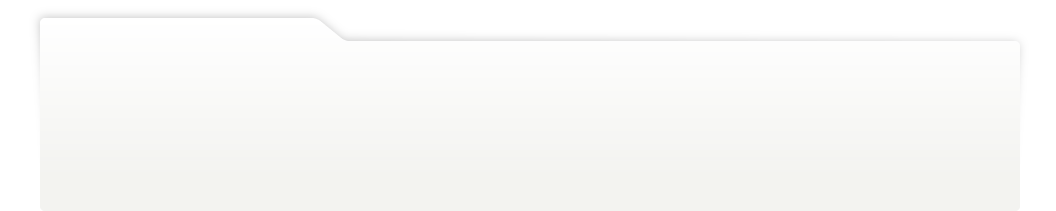
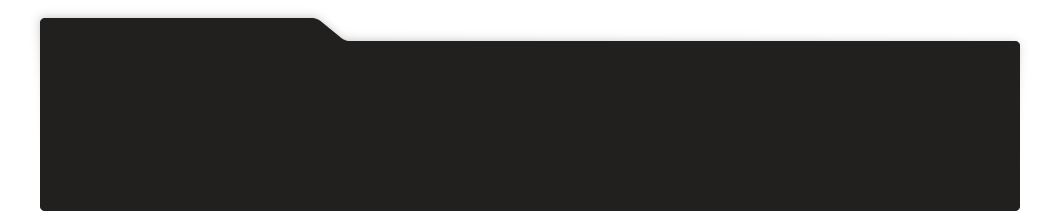
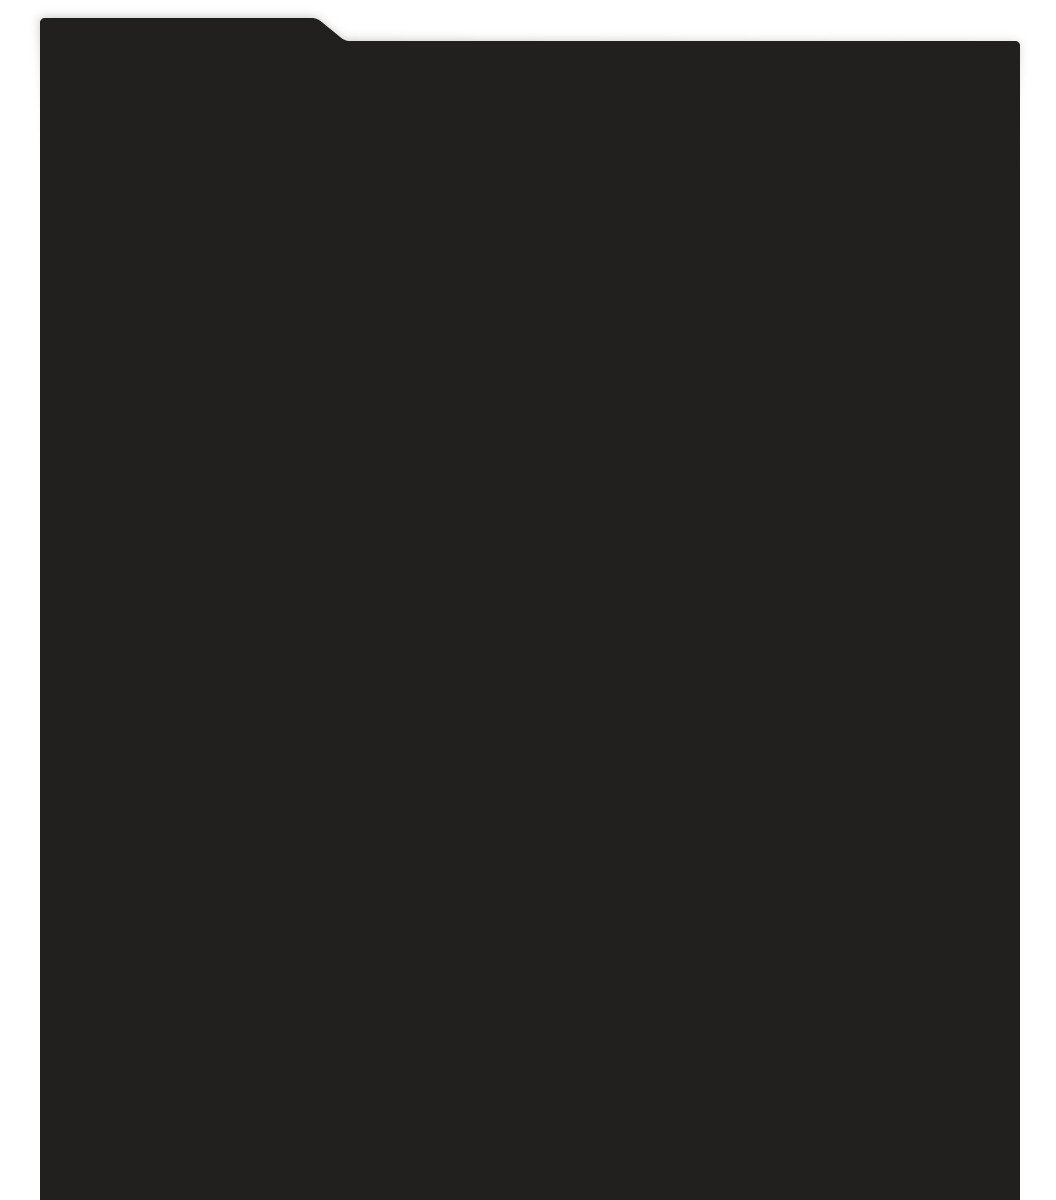
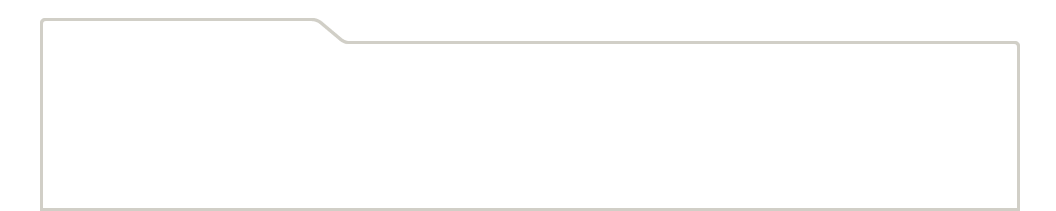
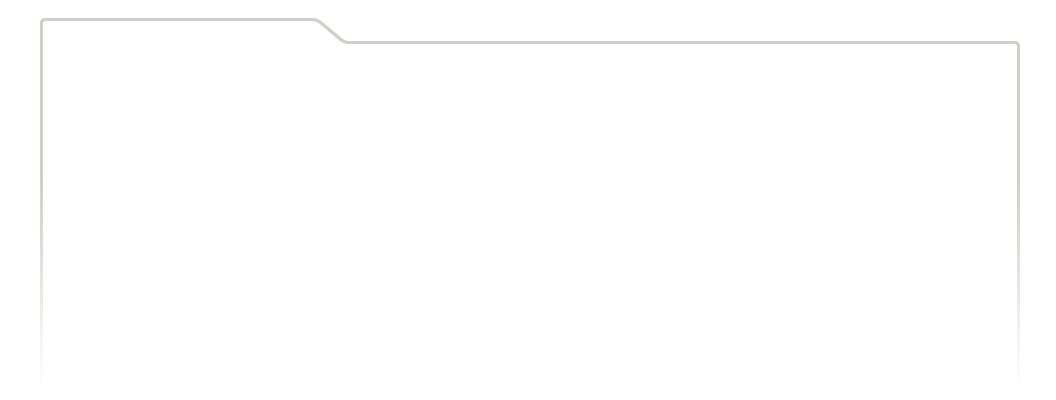
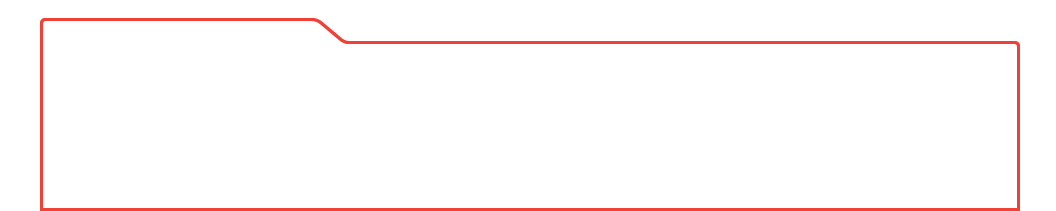
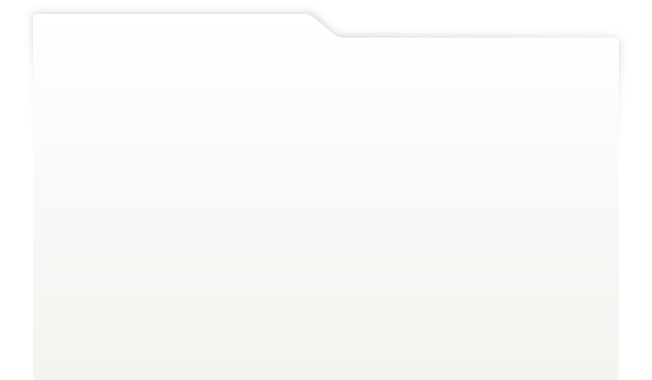
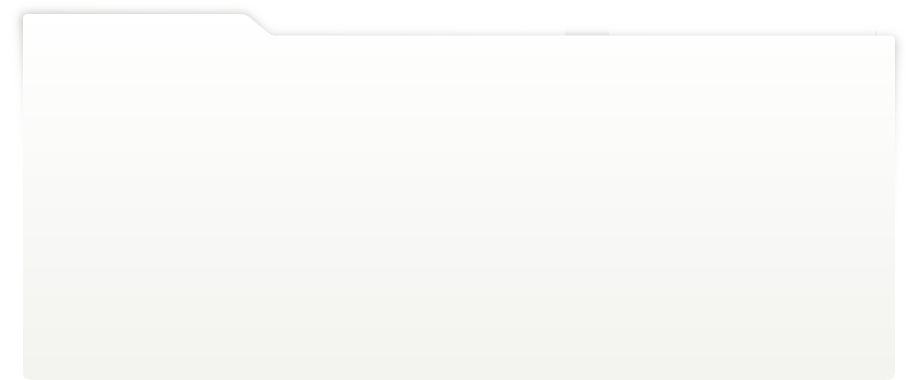
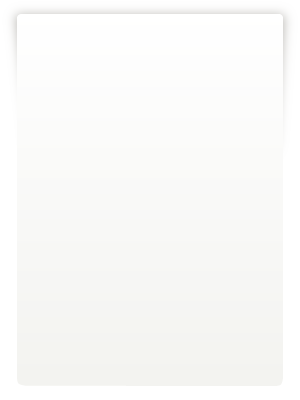
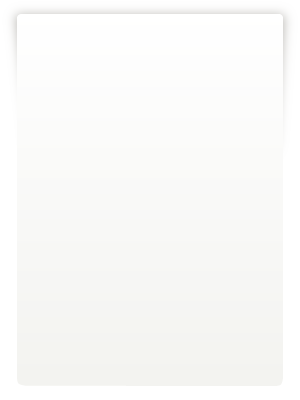
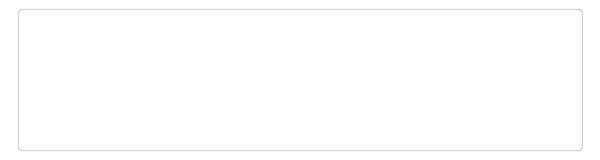
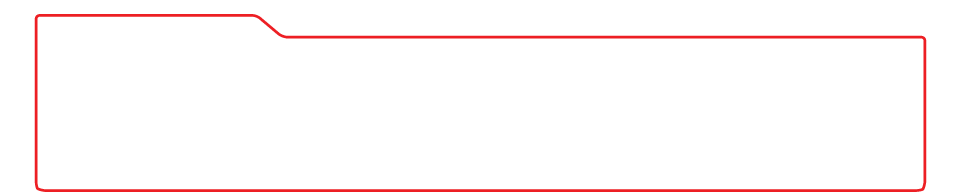
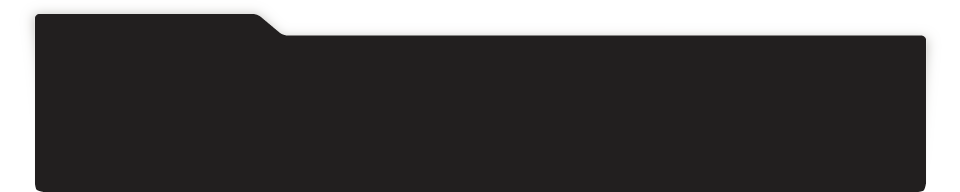
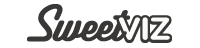
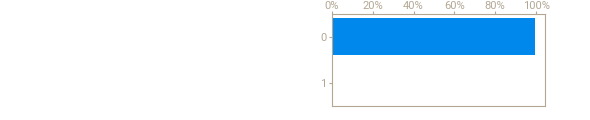
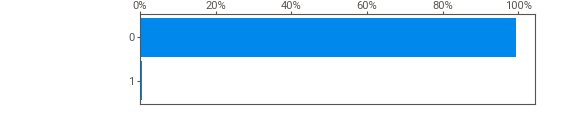
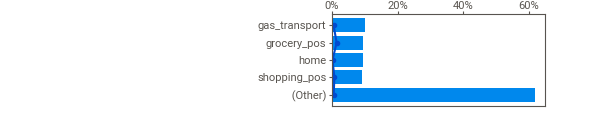
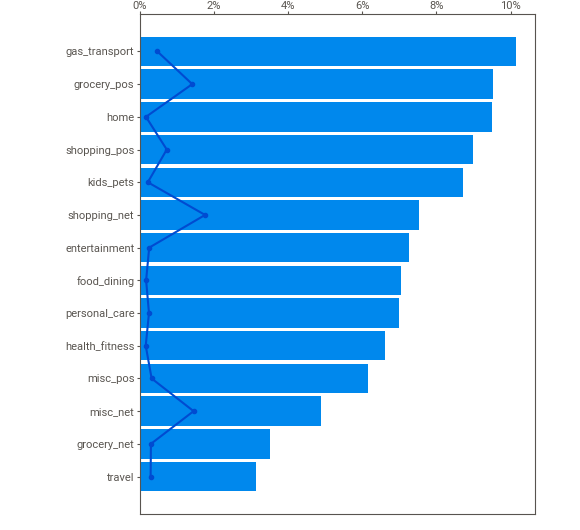
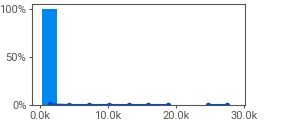
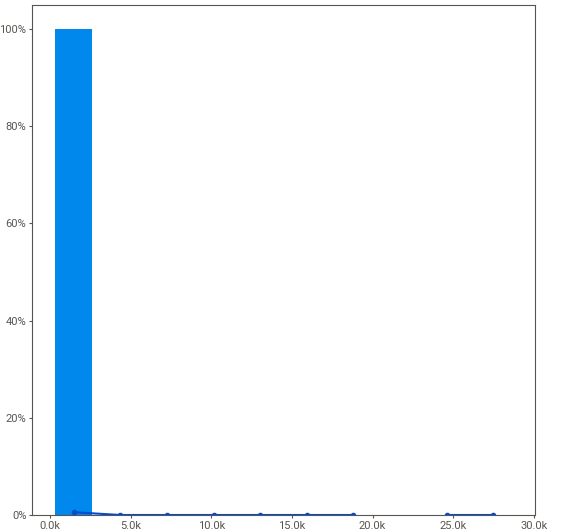
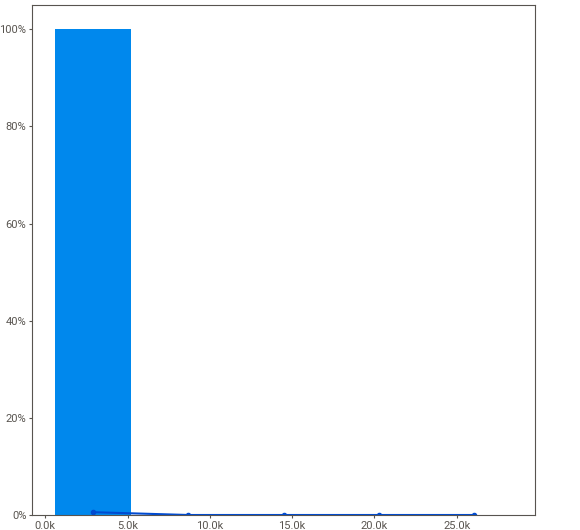
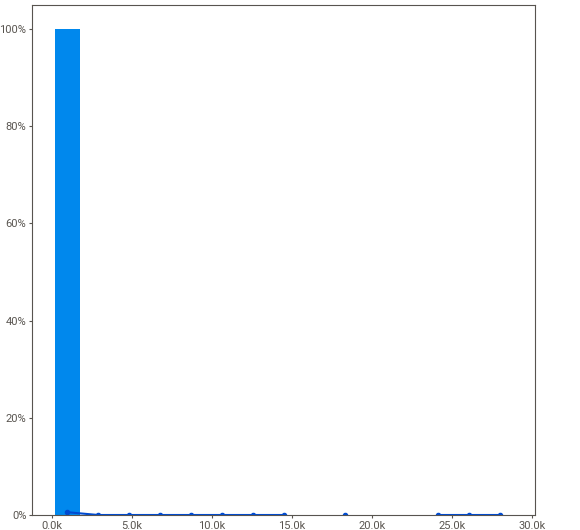
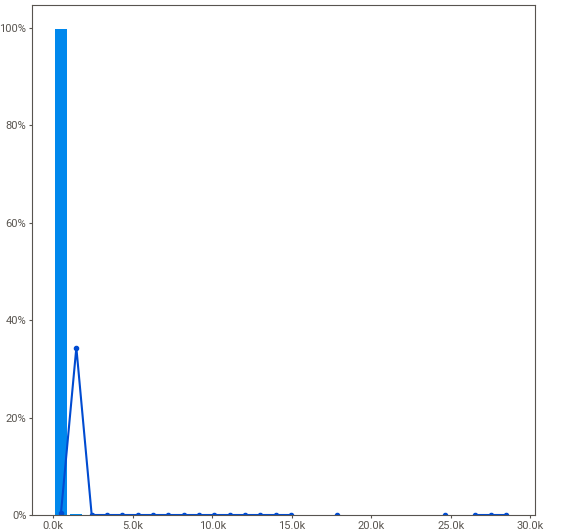
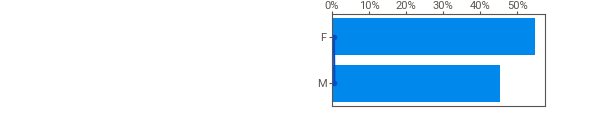
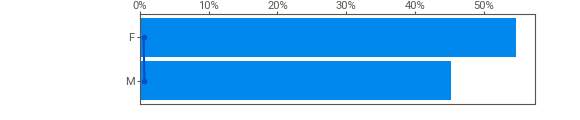
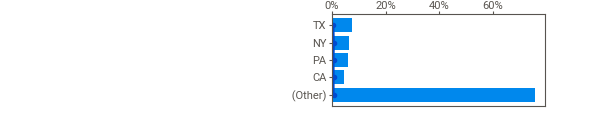
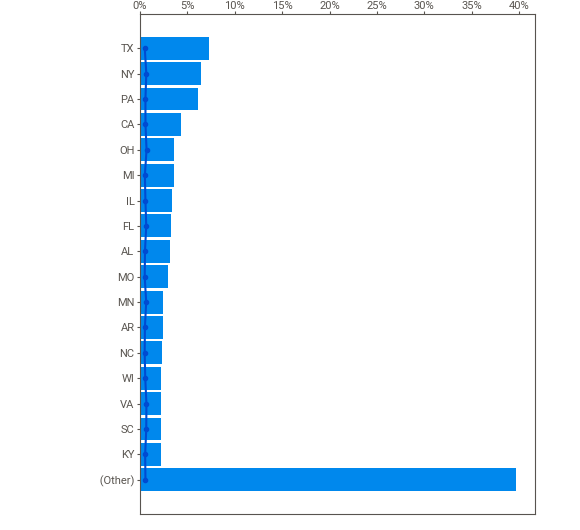
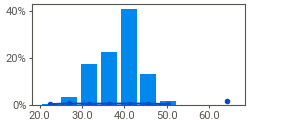
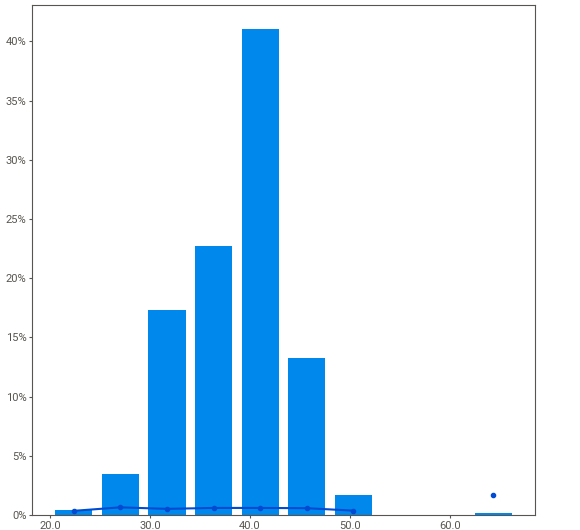
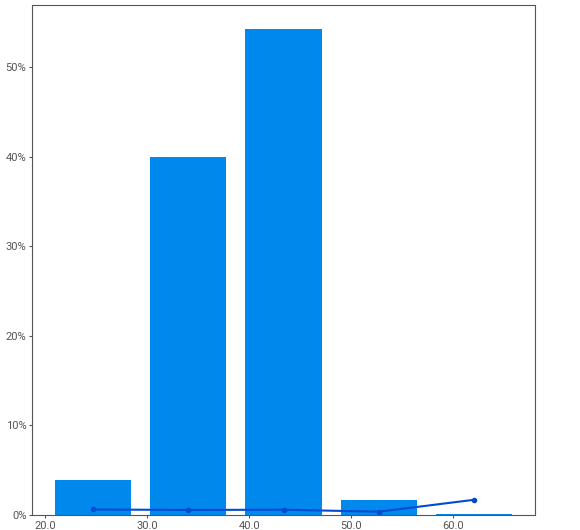
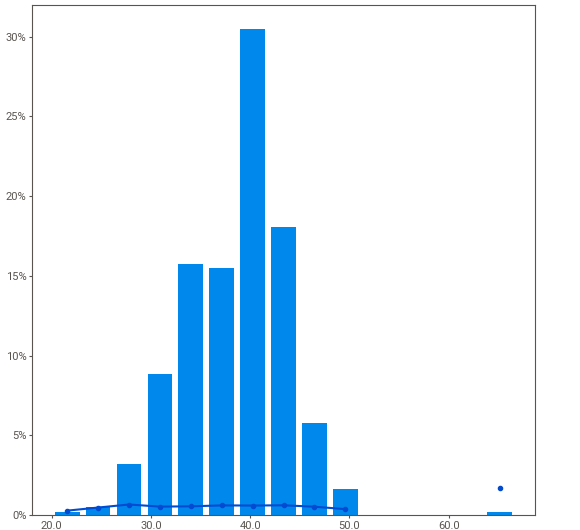
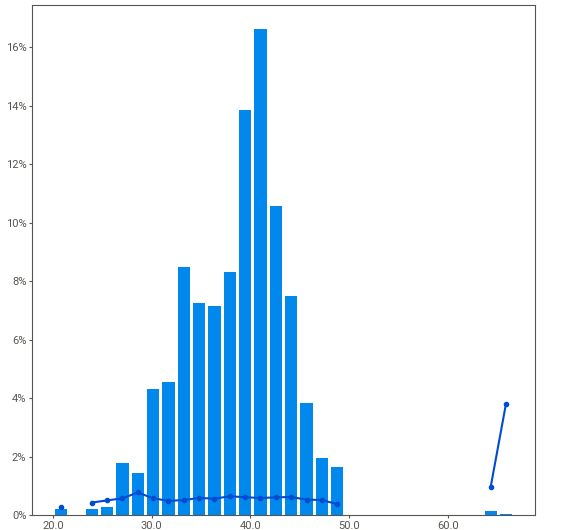
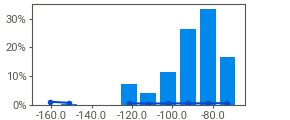
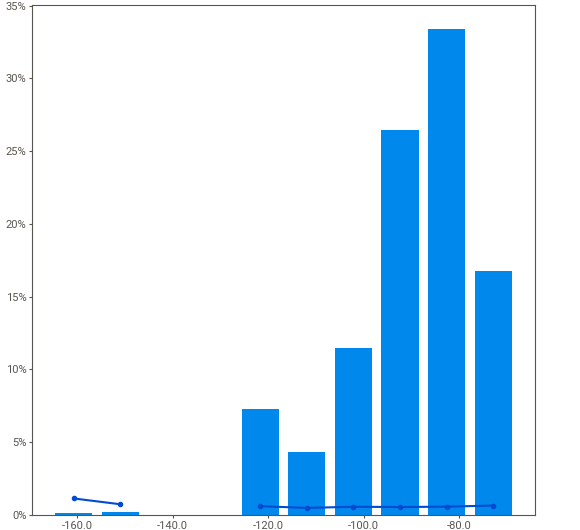
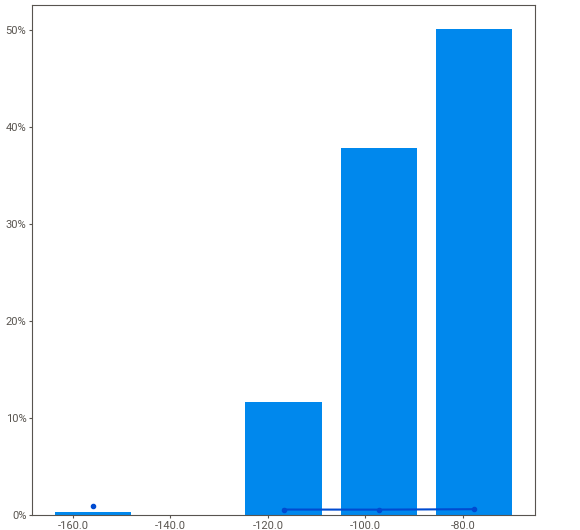
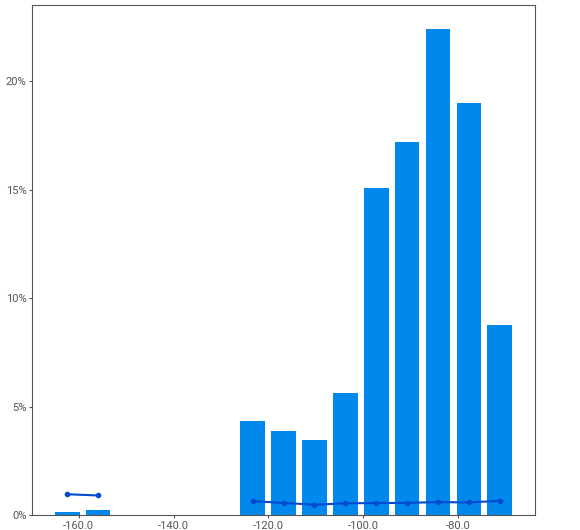
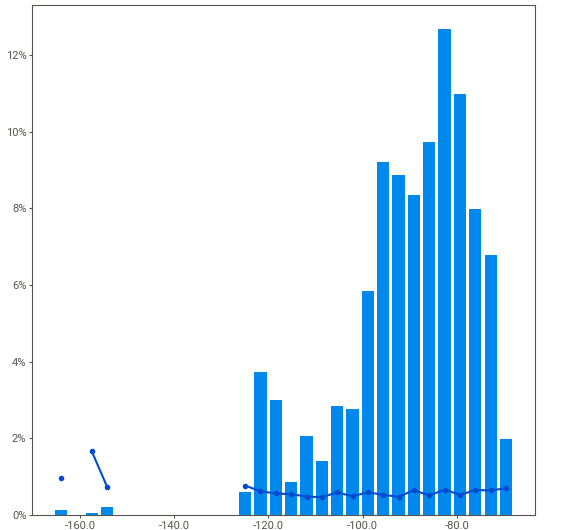
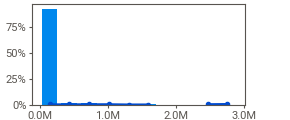
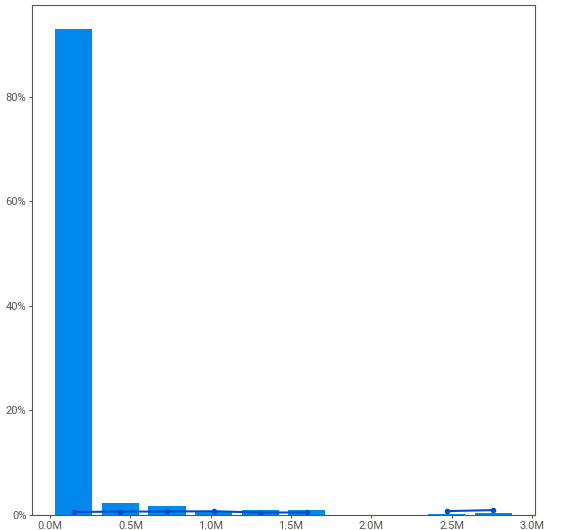
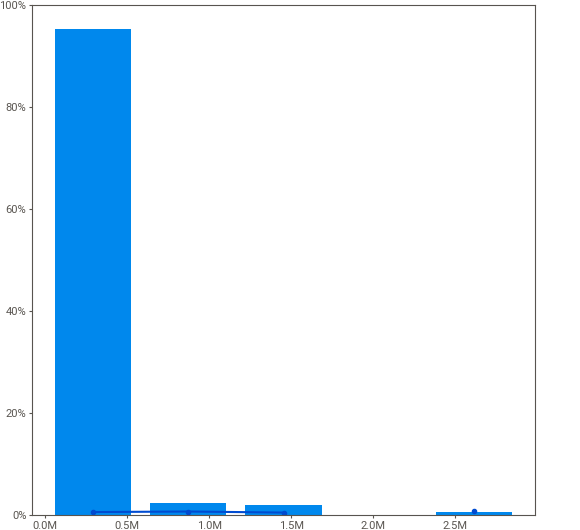
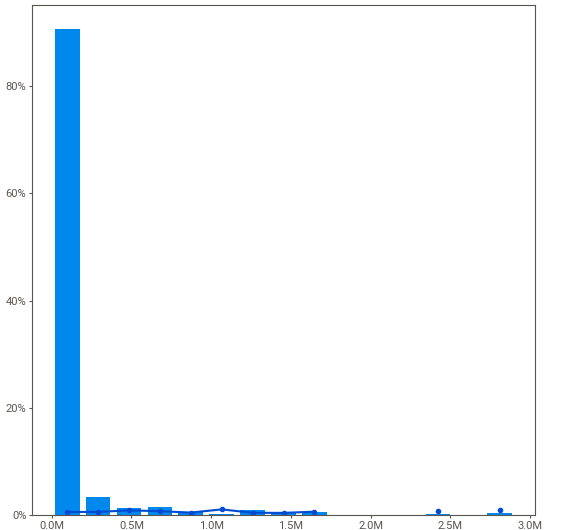
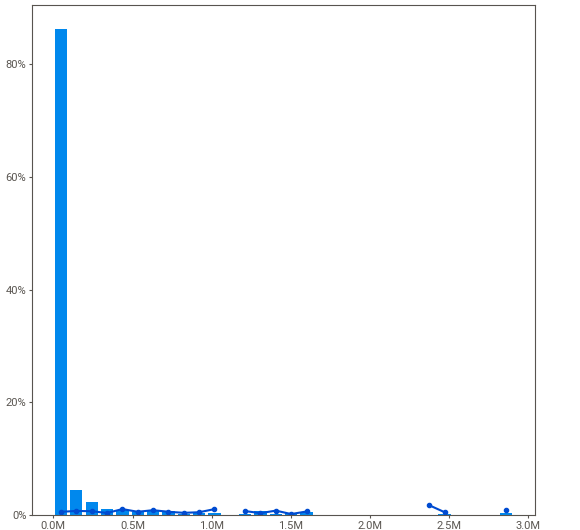
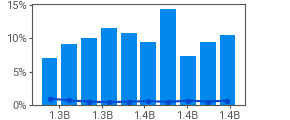
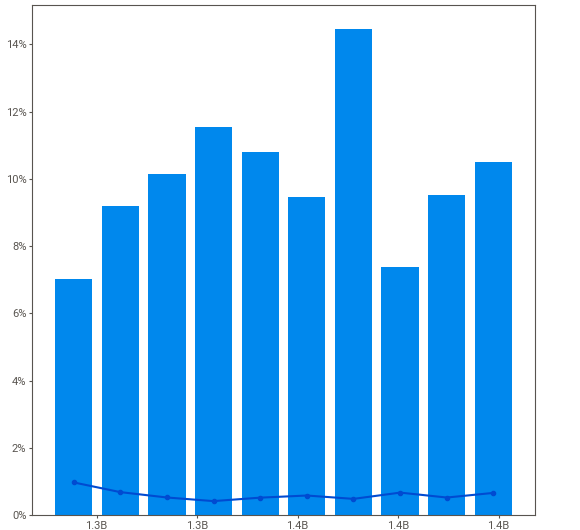
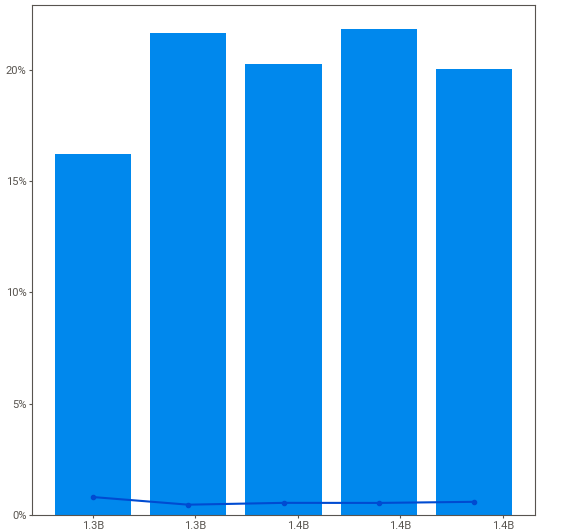
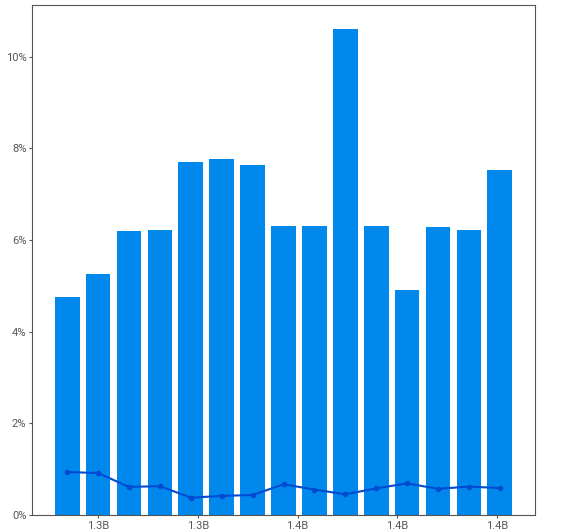
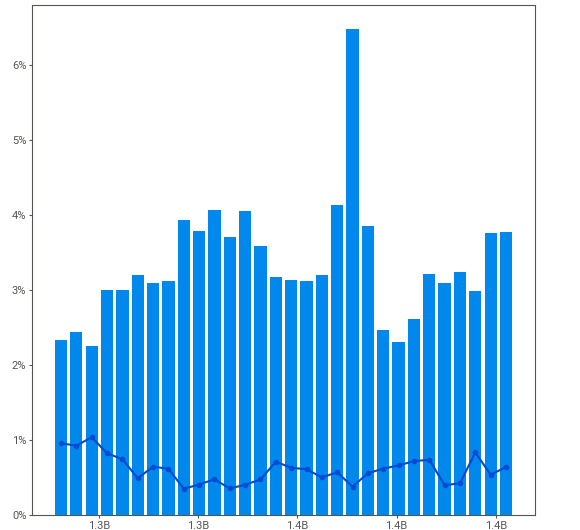
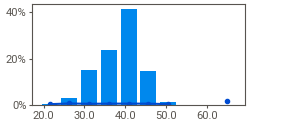
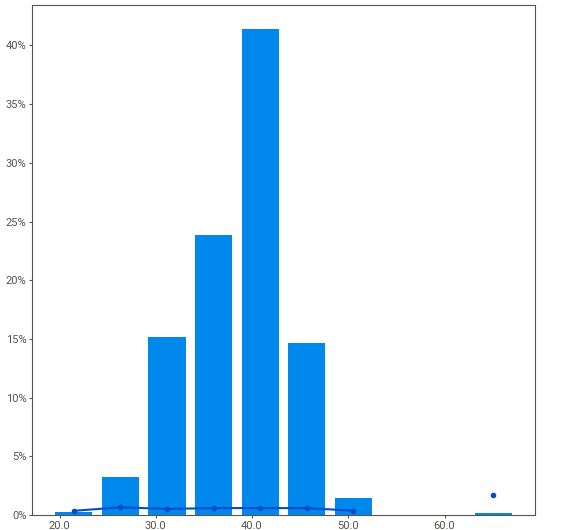
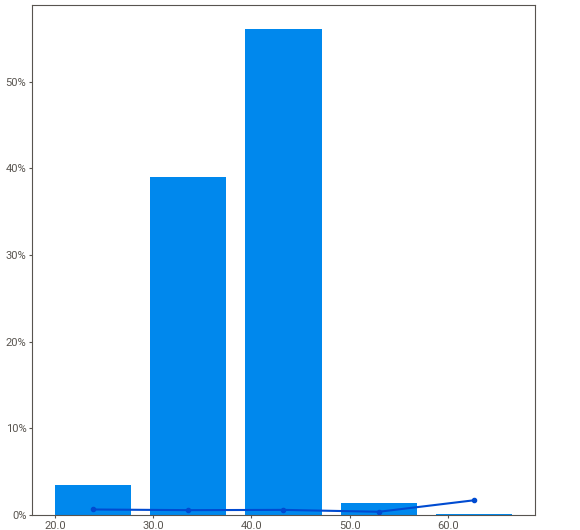
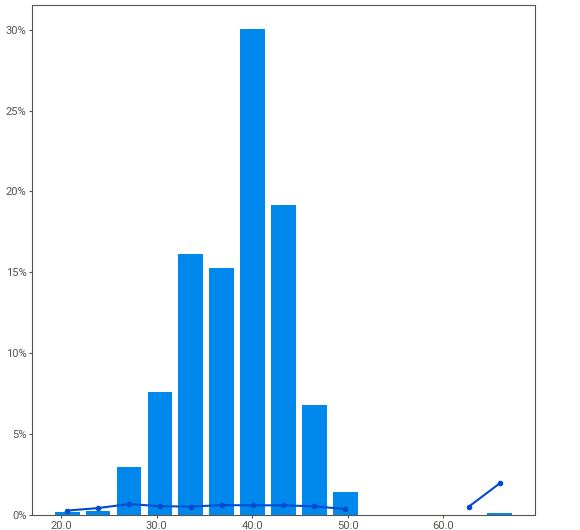
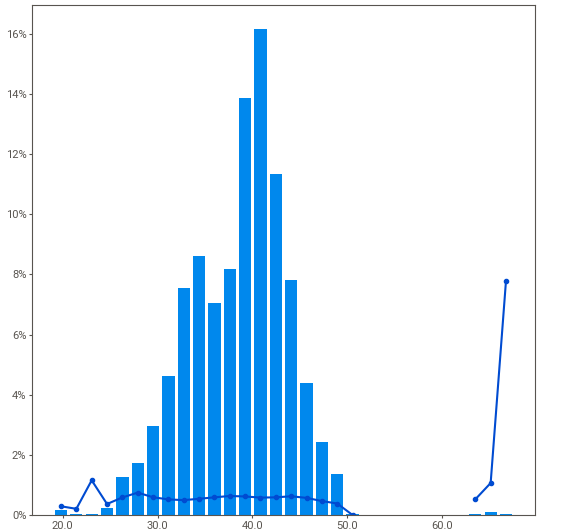
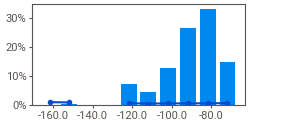
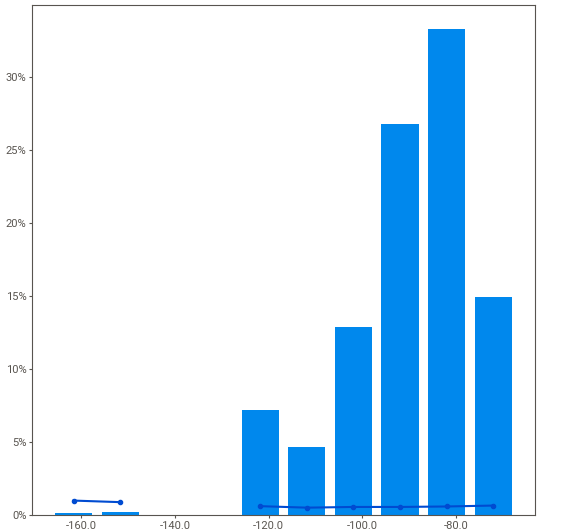
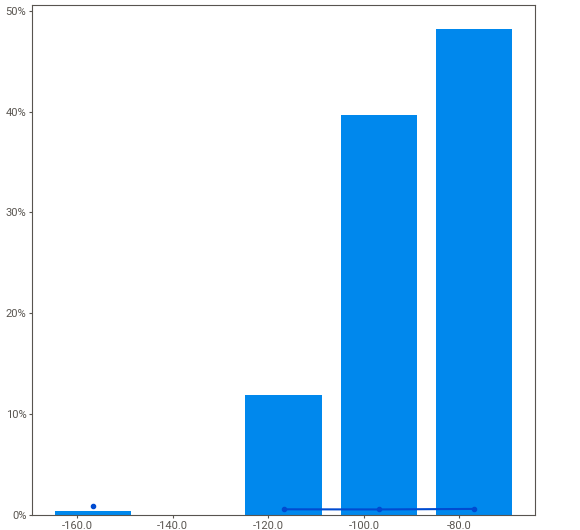
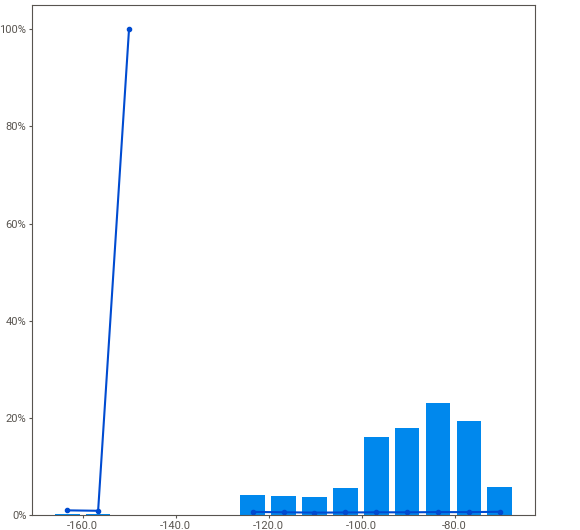
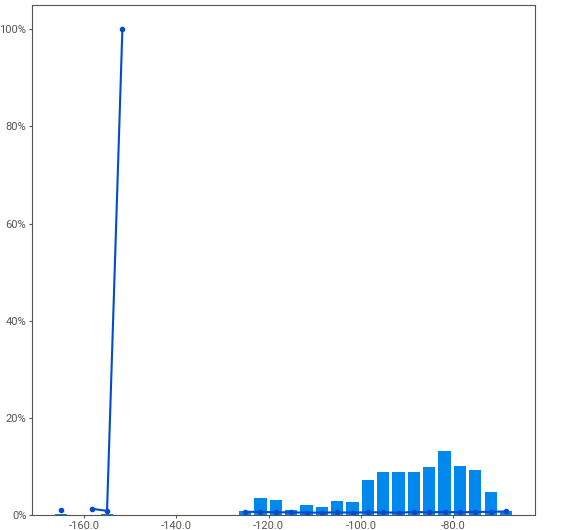
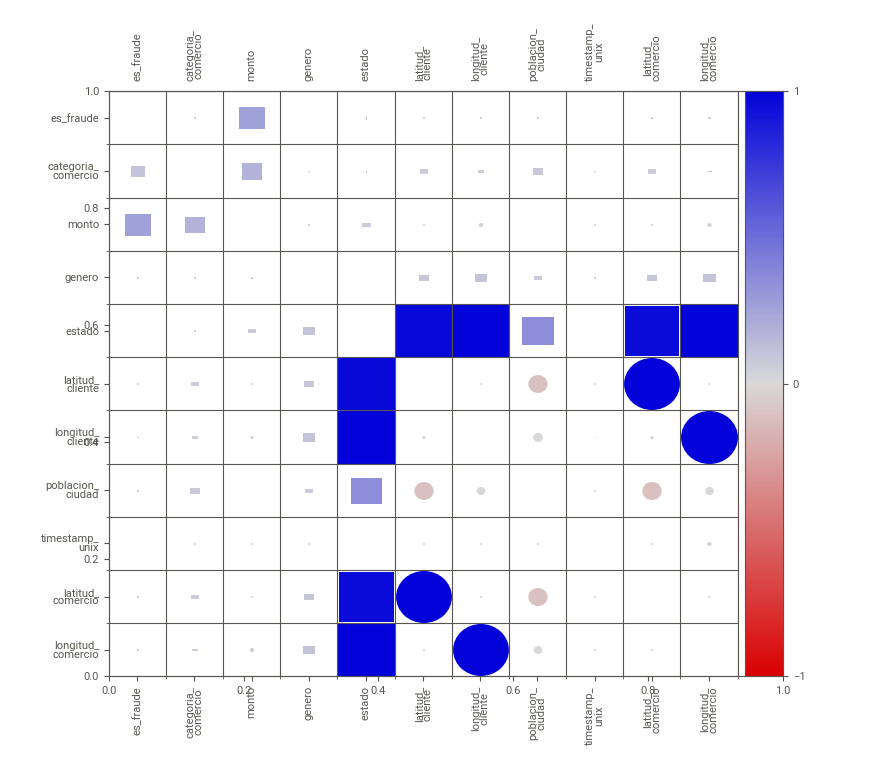
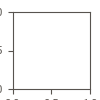

In [13]:
report = sv.analyze(df_train, target_feat="es_fraude")
report.show_notebook()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)



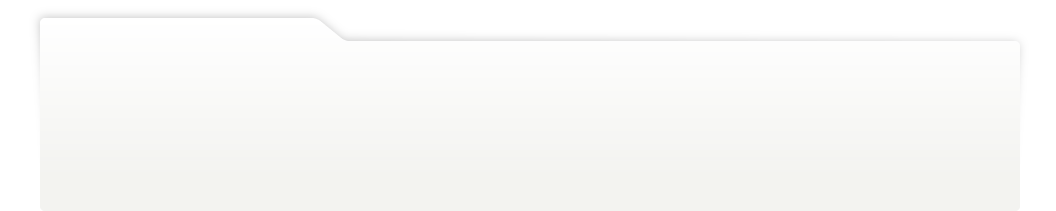
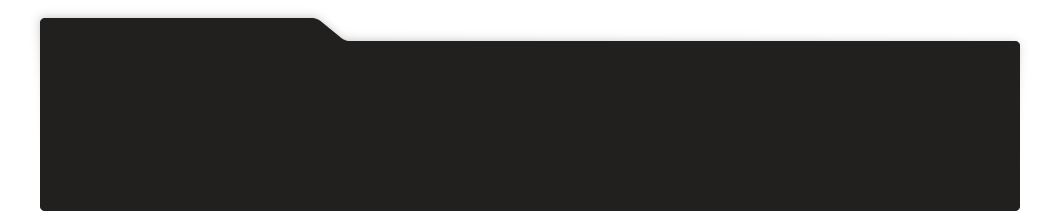
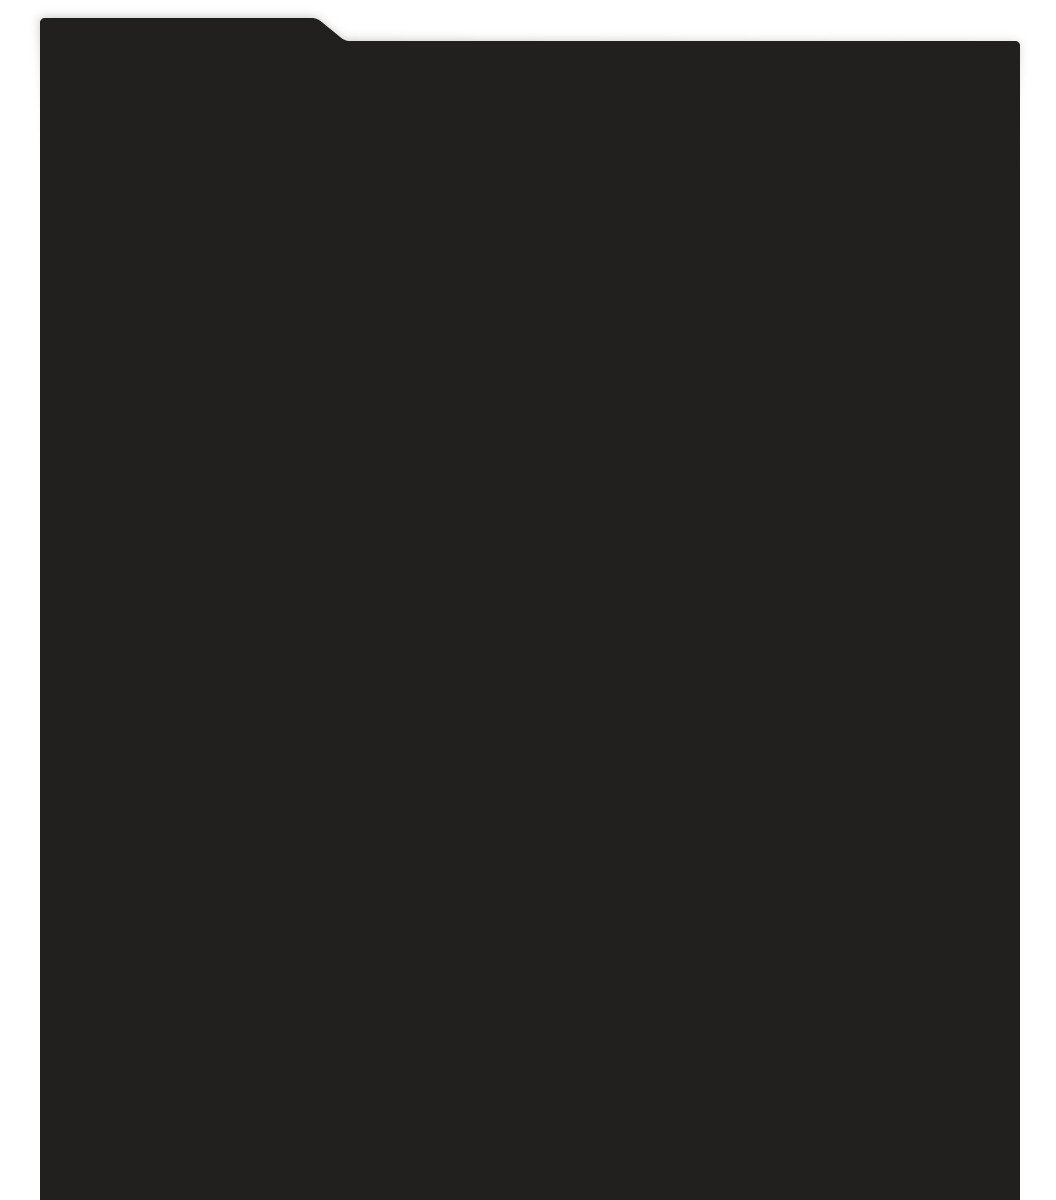
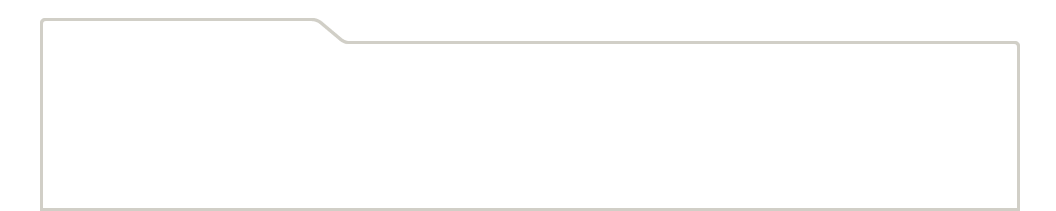
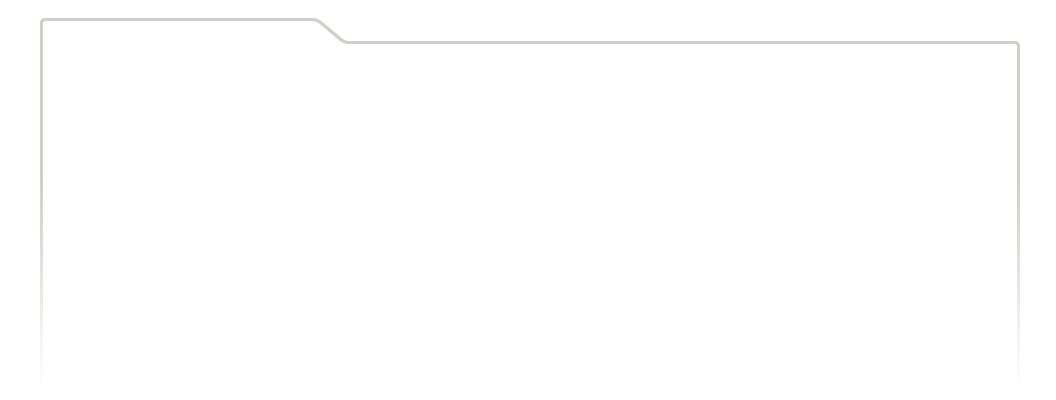
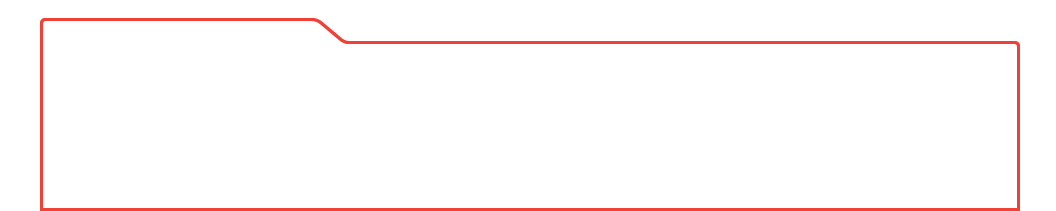
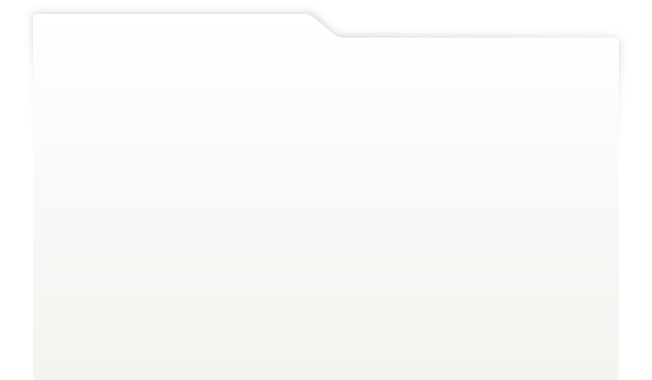
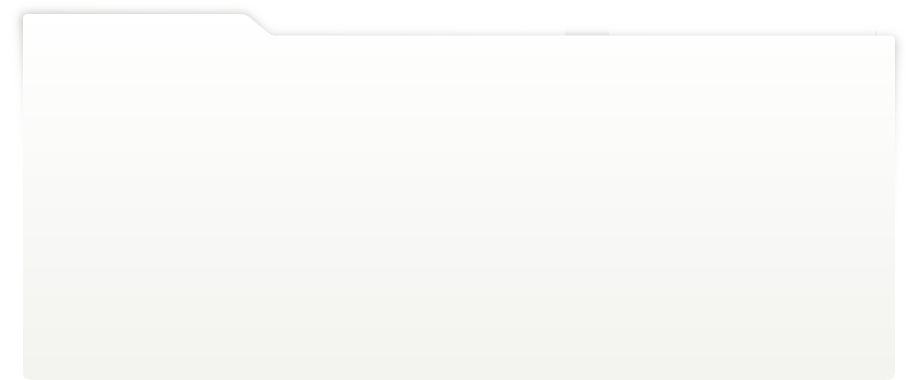
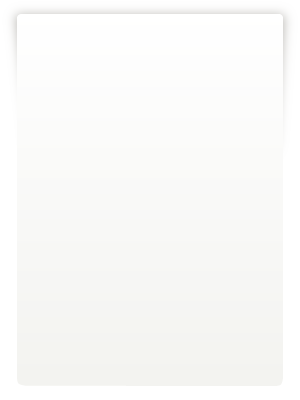
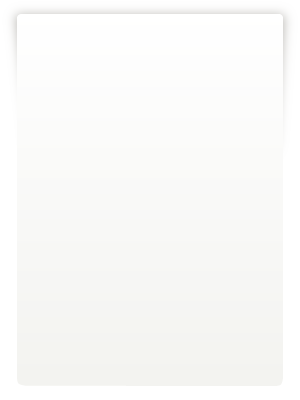
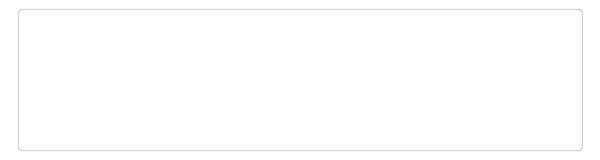
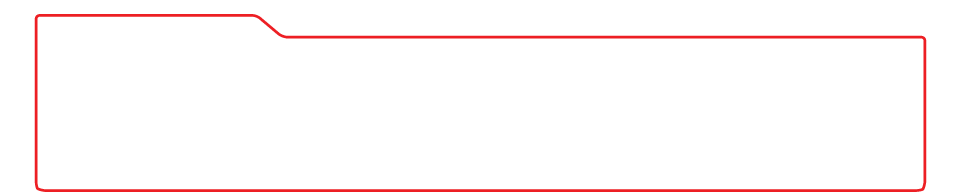
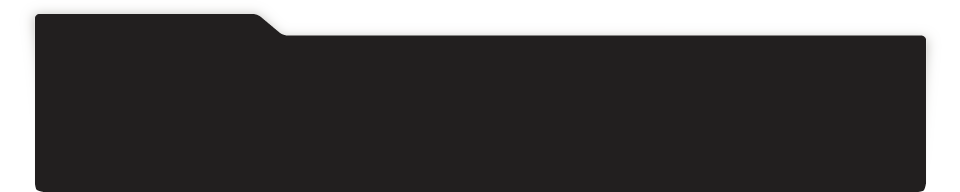
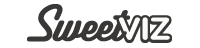
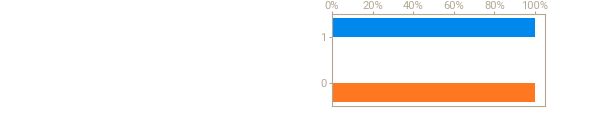
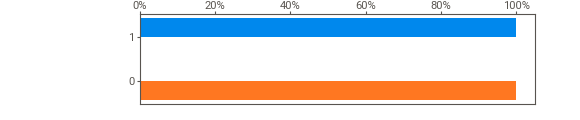
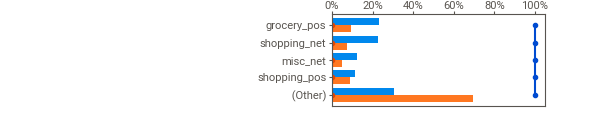
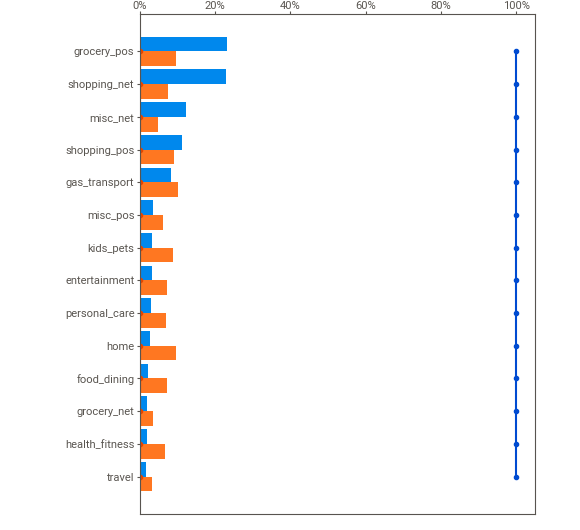
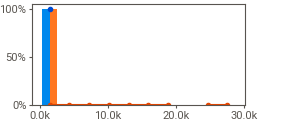
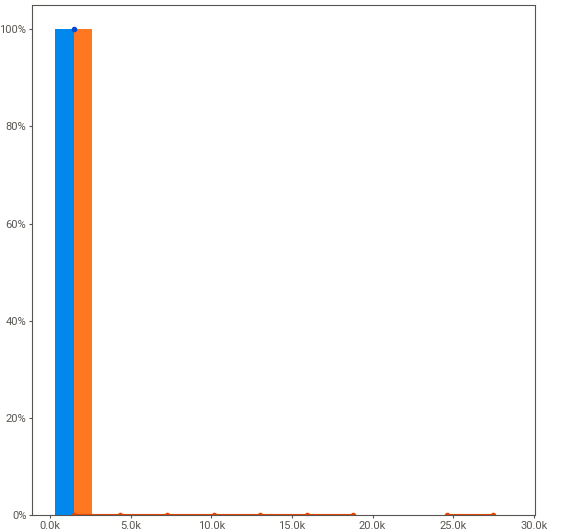
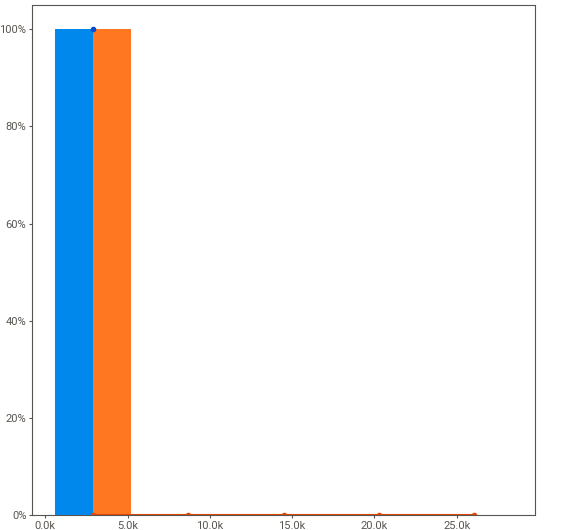
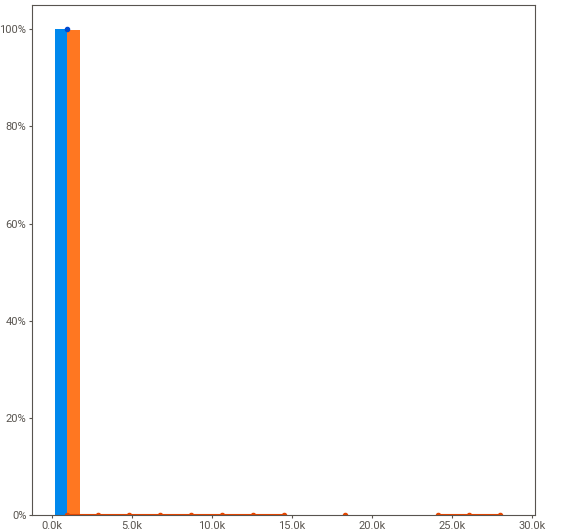
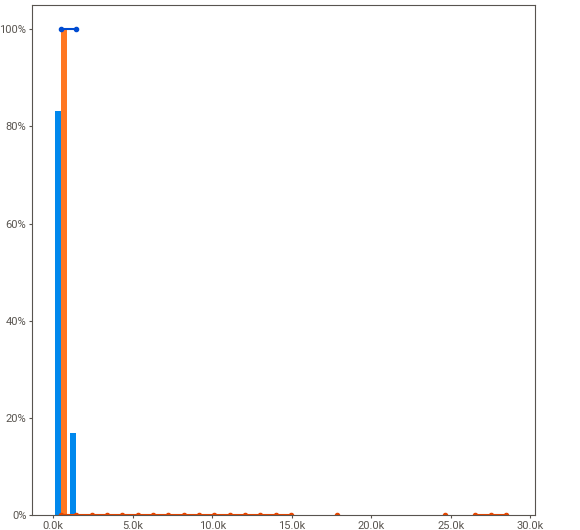
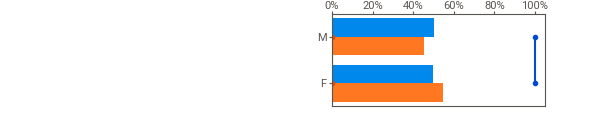
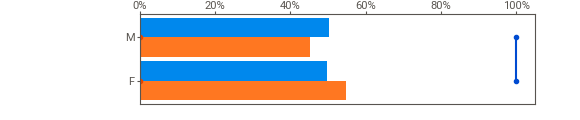
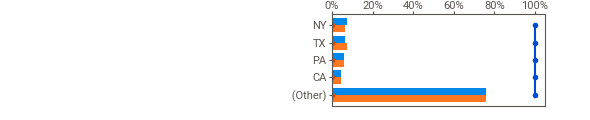
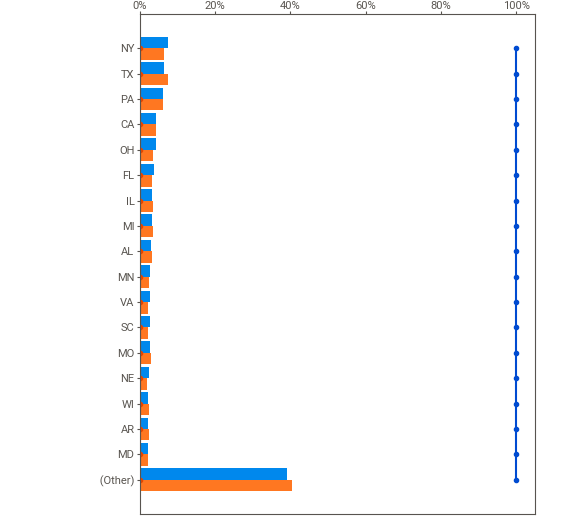
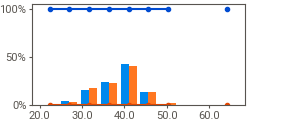
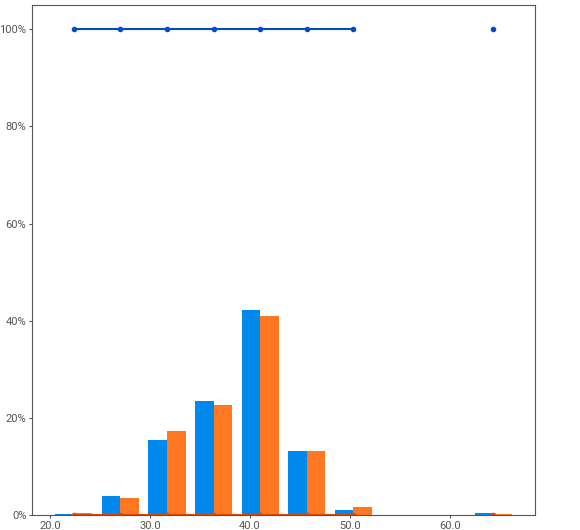
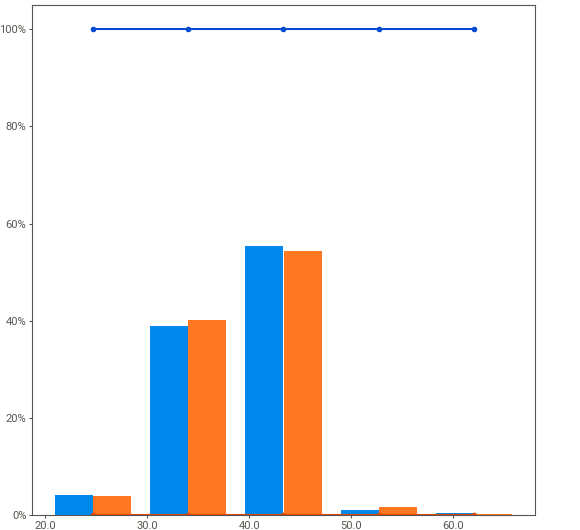
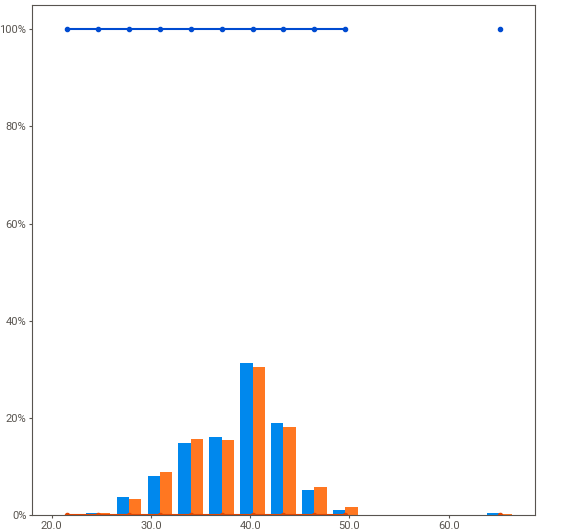
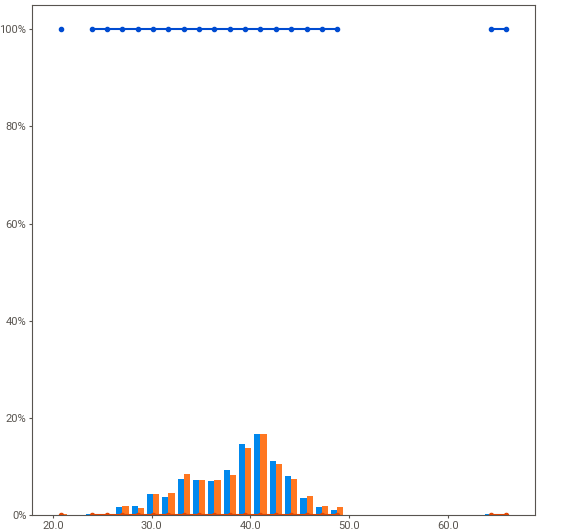
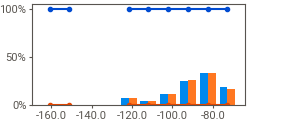
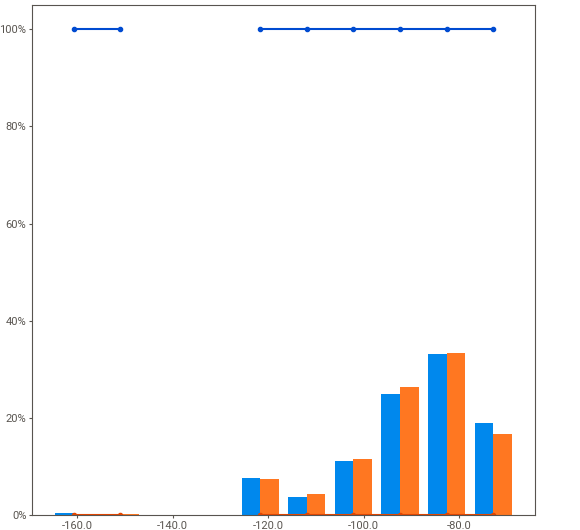
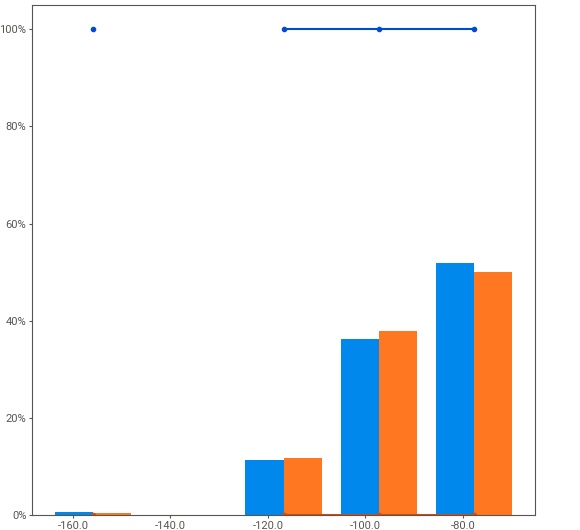
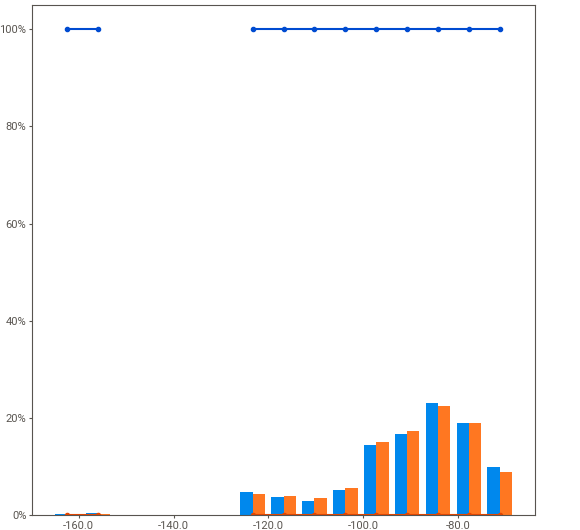
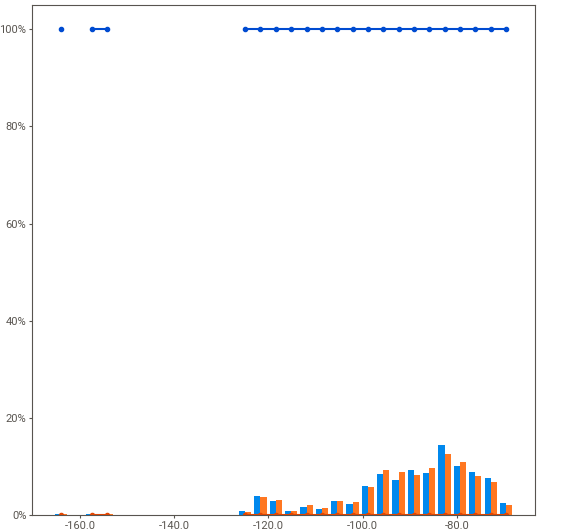
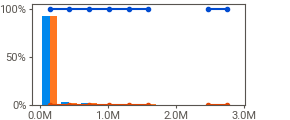
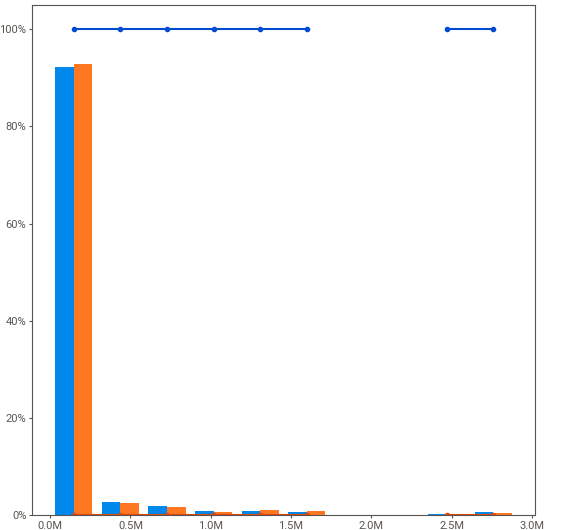
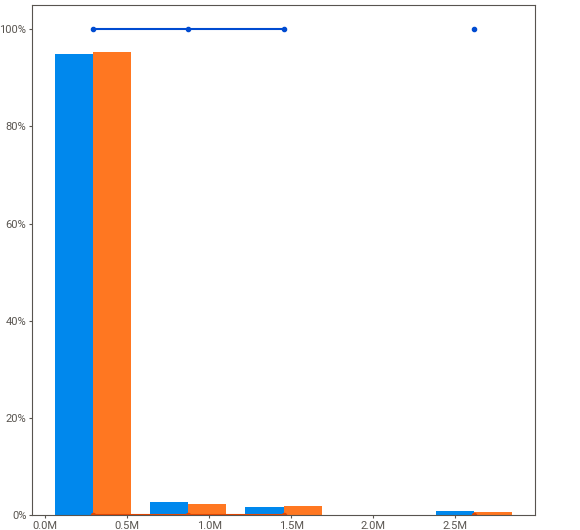
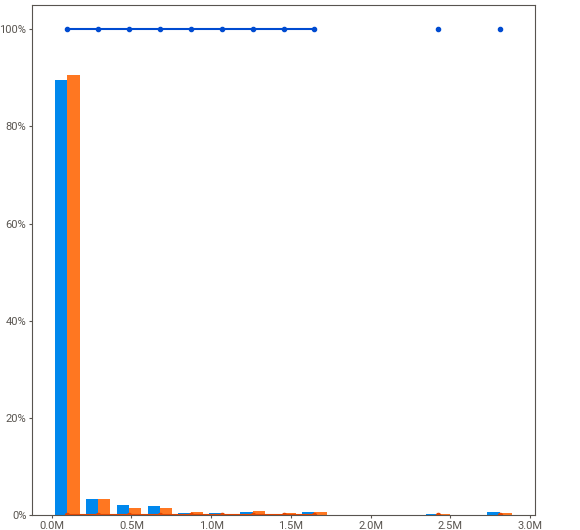
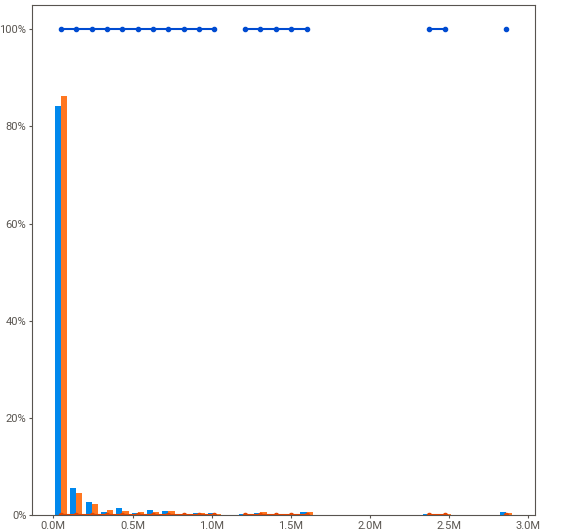
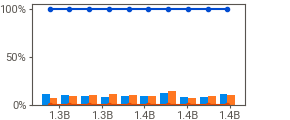
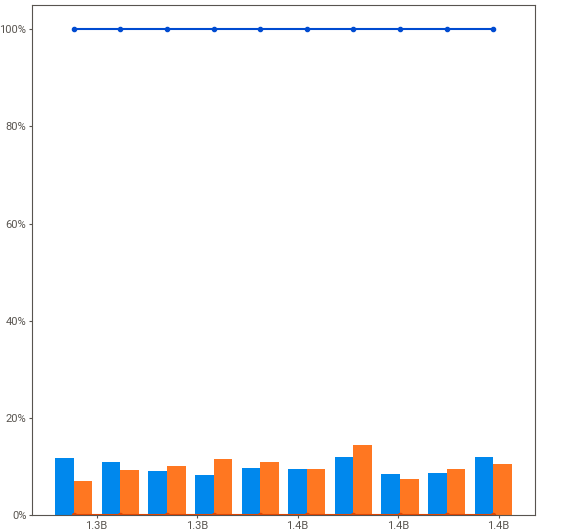
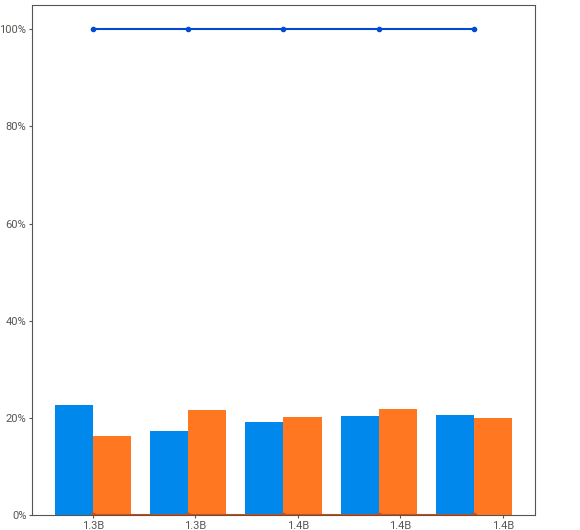
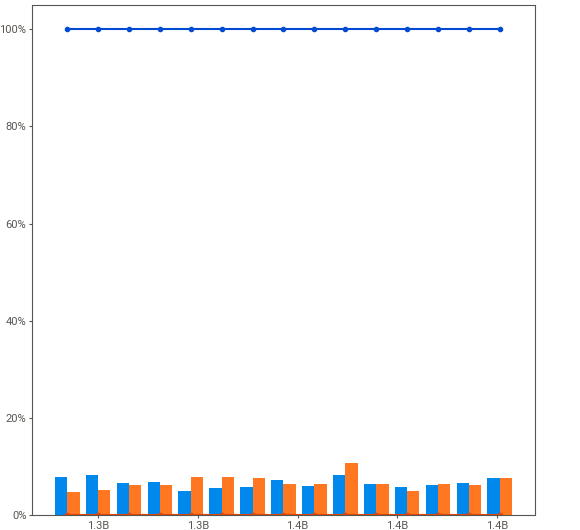
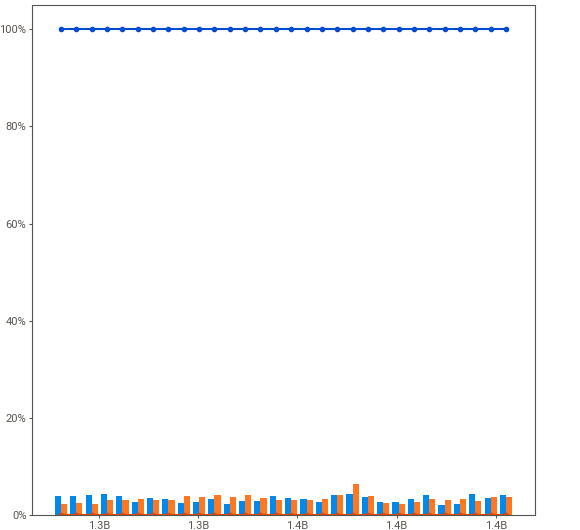
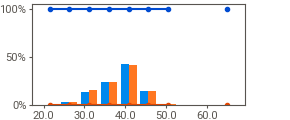
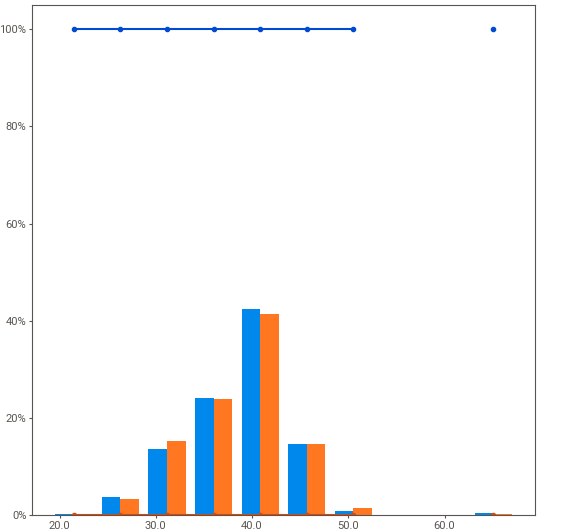
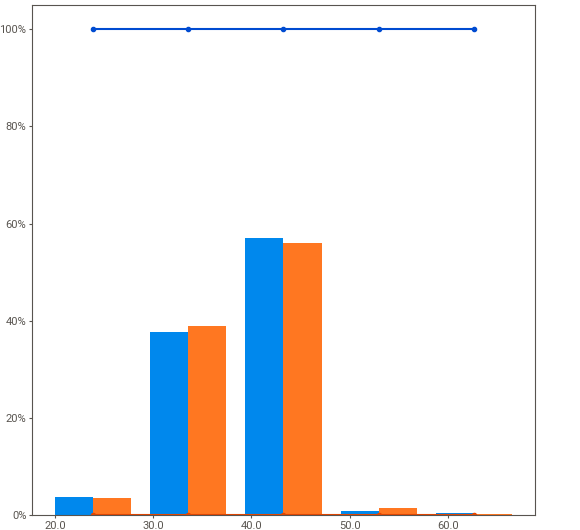
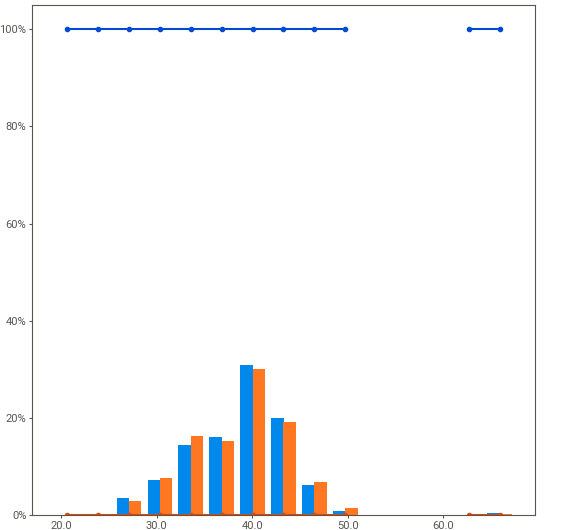
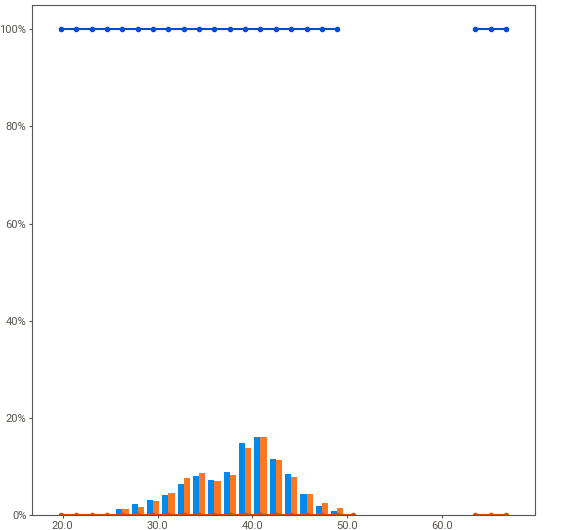
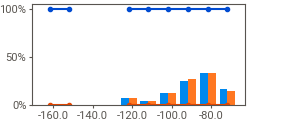
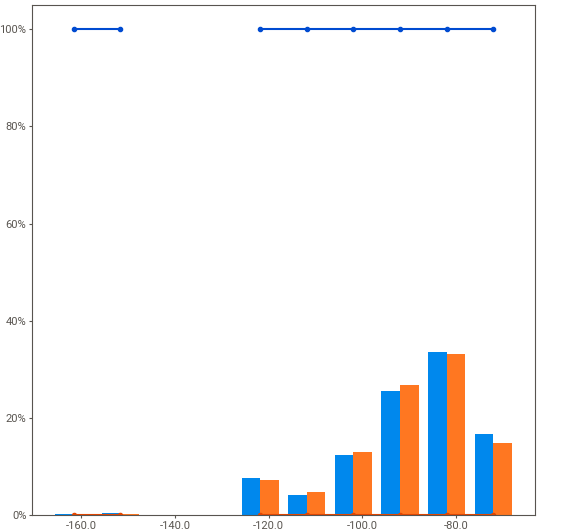
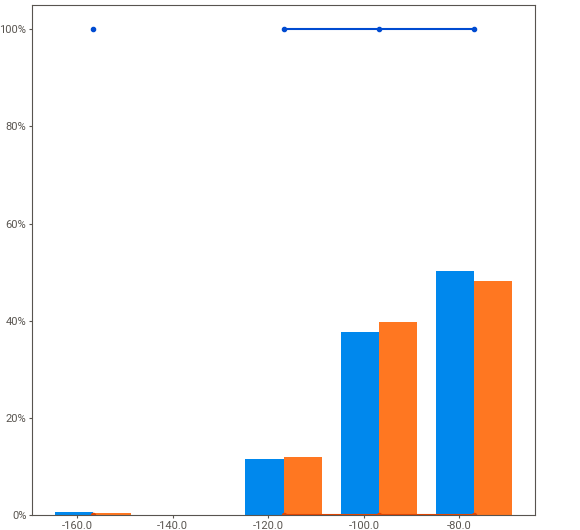
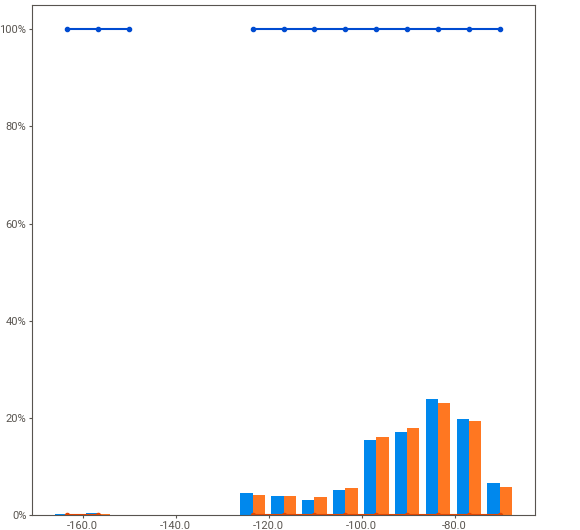
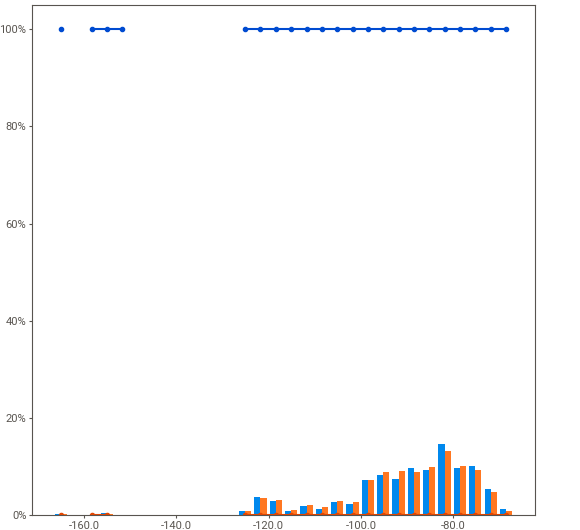
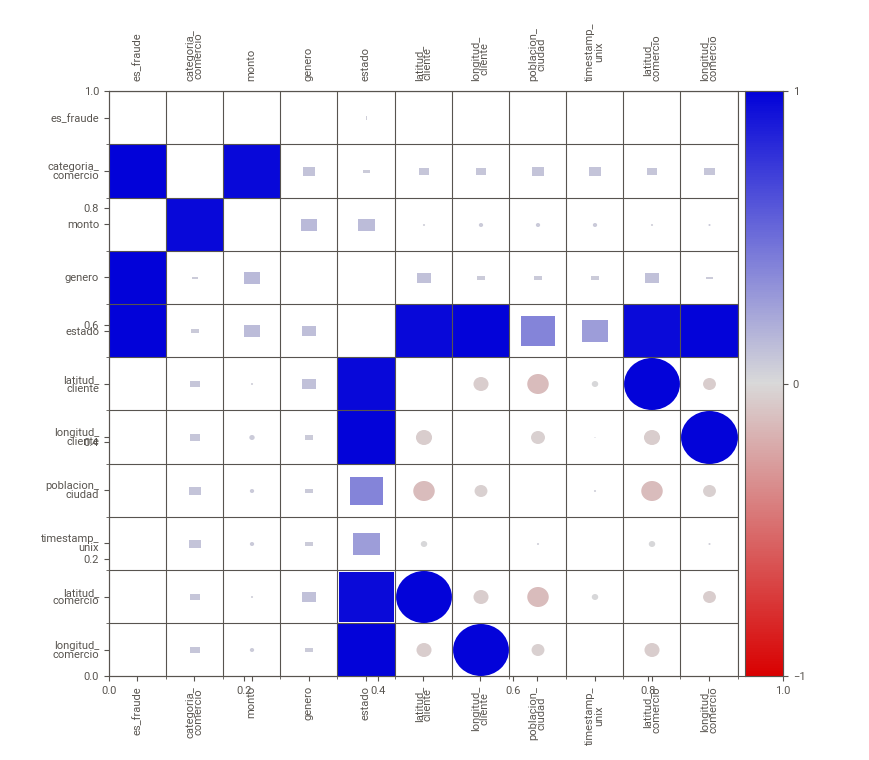
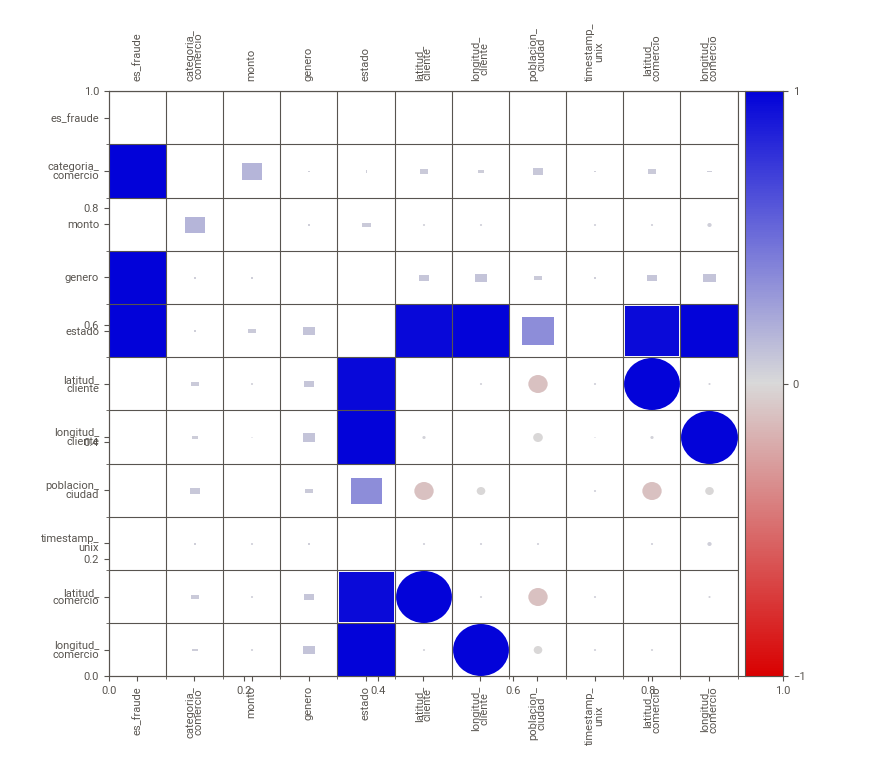

In [14]:
report_fraude = sv.compare_intra(
    df_train,
    df_train["es_fraude"] == 1,
    ["Fraude", "No fraude"],
    target_feat="es_fraude"
)

report_fraude.show_notebook()

In [15]:
df_train["type"] = "train"
df_test["type"] = "test"

df_fraude = pd.concat([df_train, df_test], ignore_index=True)
df_fraude.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 20 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   fecha_hora_transaccion  datetime64[ns]
 1   numero_tarjeta          string        
 2   comercio                object        
 3   categoria_comercio      category      
 4   monto                   float64       
 5   genero                  category      
 6   direccion               object        
 7   ciudad                  object        
 8   estado                  object        
 9   codigo_postal           string        
 10  latitud_cliente         float64       
 11  longitud_cliente        float64       
 12  poblacion_ciudad        int64         
 13  ocupacion               object        
 14  fecha_nacimiento        datetime64[ns]
 15  timestamp_unix          int64         
 16  latitud_comercio        float64       
 17  longitud_comercio       float64       
 18  es

In [16]:
# Usar dataframe existente
transactions_clean_v1 = df_fraude.copy()

# Estandarizar fechas
transactions_clean_v1["fecha_hora_transaccion"] = pd.to_datetime(
    transactions_clean_v1["fecha_hora_transaccion"], errors="coerce"
)

transactions_clean_v1["fecha_nacimiento"] = pd.to_datetime(
    transactions_clean_v1["fecha_nacimiento"], errors="coerce"
)

# Estandarizar columnas numéricas
numeric_cols = [
    "monto", "latitud_cliente", "longitud_cliente", "poblacion_ciudad",
    "timestamp_unix", "latitud_comercio", "longitud_comercio",
    "es_fraude", "codigo_postal"
]

for col in numeric_cols:
    if col in transactions_clean_v1.columns:
        transactions_clean_v1[col] = pd.to_numeric(
            transactions_clean_v1[col], errors="coerce"
        )

# Feature engineering
transactions_clean_v1["hora_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.hour.astype("Int64")
transactions_clean_v1["dia_semana_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.day_name()
transactions_clean_v1["mes_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.month.astype("Int64")

# Edad aproximada del cliente al momento de la transacción
edad_anios = (
    (transactions_clean_v1["fecha_hora_transaccion"] - transactions_clean_v1["fecha_nacimiento"]).dt.days / 365.25
)

transactions_clean_v1["edad_cliente"] = np.floor(edad_anios).astype("Int64")

# Distancia Haversine entre cliente y comercio
lat1 = np.radians(transactions_clean_v1["latitud_cliente"])
lon1 = np.radians(transactions_clean_v1["longitud_cliente"])
lat2 = np.radians(transactions_clean_v1["latitud_comercio"])
lon2 = np.radians(transactions_clean_v1["longitud_comercio"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2.0) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

transactions_clean_v1["distancia_km"] = 6371.0 * c

# Protección de datos personales
pii_cols = ["nombre", "apellido", "direccion"]

transactions_clean_v1 = transactions_clean_v1.drop(
    columns=[c for c in pii_cols if c in transactions_clean_v1.columns]
)

# Remover número de tarjeta, dejando solo últimos 4 dígitos
if "numero_tarjeta" in transactions_clean_v1.columns:
    transactions_clean_v1["tarjeta_ultimos4"] = transactions_clean_v1["numero_tarjeta"].astype(str).str[-4:]
    transactions_clean_v1 = transactions_clean_v1.drop(columns=["numero_tarjeta"])

transactions_clean_v1.head()

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude,type,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011,-82.048,0,train,0,Tuesday,1,30,78.598,2095
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1325376044,49.159,-118.186,0,train,0,Tuesday,1,40,30.212,7322
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.110,M,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,1325376051,43.151,-112.154,0,train,0,Tuesday,1,56,108.206,7661
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,1325376076,47.034,-112.561,0,train,0,Tuesday,1,51,95.673,0240
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.960,M,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,1325376186,38.675,-78.632,0,train,0,Tuesday,1,32,77.557,3984


In [17]:
columnas_finales = [
    "fecha_hora_transaccion",
    "comercio",
    "categoria_comercio",
    "monto",
    "genero",
    "ciudad",
    "estado",
    "codigo_postal",
    "latitud_cliente",
    "longitud_cliente",
    "poblacion_ciudad",
    "ocupacion",
    "fecha_nacimiento",
    "id_transaccion",
    "timestamp_unix",
    "latitud_comercio",
    "longitud_comercio",
    "hora_transaccion",
    "dia_semana_transaccion",
    "mes_transaccion",
    "edad_cliente",
    "distancia_km",
    "tarjeta_ultimos4",
    "es_fraude",
    "type"
]

columnas_existentes = [col for col in columnas_finales if col in transactions_clean_v1.columns]

transactions_clean_v1 = transactions_clean_v1.loc[:, columnas_existentes]

transactions_clean_v1.head()

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011,-82.048,0,Tuesday,1,30,78.598,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1325376044,49.159,-118.186,0,Tuesday,1,40,30.212,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.110,M,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,1325376051,43.151,-112.154,0,Tuesday,1,56,108.206,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,1325376076,47.034,-112.561,0,Tuesday,1,51,95.673,0240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.960,M,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,1325376186,38.675,-78.632,0,Tuesday,1,32,77.557,3984,0,train


In [18]:
transactions_clean_v1["type"].value_counts()

type
train    1296675
test      555719
Name: count, dtype: int64

In [19]:
transactions_clean_v1.loc[
    transactions_clean_v1["type"] == "train",
    "es_fraude"
].value_counts()

es_fraude
0    1289169
1       7506
Name: count, dtype: int64

In [20]:
transactions_clean_v1

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011,-82.048,0,Tuesday,1,30,78.598,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1325376044,49.159,-118.186,0,Tuesday,1,40,30.212,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.110,M,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,1325376051,43.151,-112.154,0,Tuesday,1,56,108.206,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,1325376076,47.034,-112.561,0,Tuesday,1,51,95.673,0240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.960,M,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,1325376186,38.675,-78.632,0,Tuesday,1,32,77.557,3984,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,fraud_Reilly and Sons,health_fitness,43.770,M,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,1388534347,39.947,-91.333,23,Thursday,12,54,77.026,0617,0,test
1852390,2020-12-31 23:59:09,fraud_Hoppe-Parisian,kids_pets,111.840,M,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,1388534349,29.661,-96.187,23,Thursday,12,21,100.074,1656,0,test
1852391,2020-12-31 23:59:15,fraud_Rau-Robel,kids_pets,86.880,F,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,1388534355,46.658,-119.715,23,Thursday,12,39,80.759,8086,0,test
1852392,2020-12-31 23:59:24,fraud_Breitenberg LLC,travel,7.990,M,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,1388534364,44.471,-117.081,23,Thursday,12,55,52.933,9158,0,test


In [21]:
transactions_clean_v1.loc[transactions_clean_v1["type"]=='test',"es_fraude"].value_counts()

es_fraude
0    553574
1      2145
Name: count, dtype: int64

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)



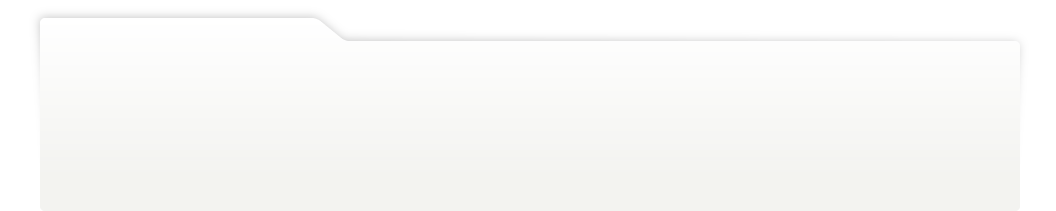
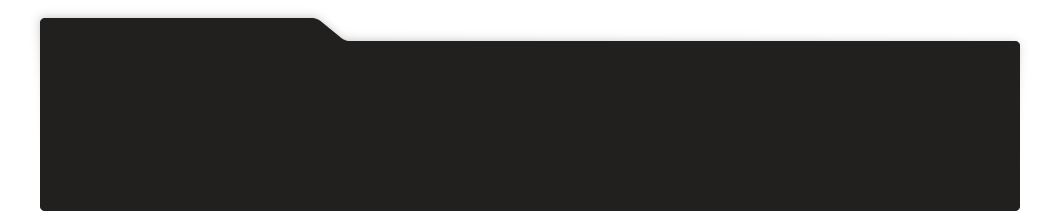
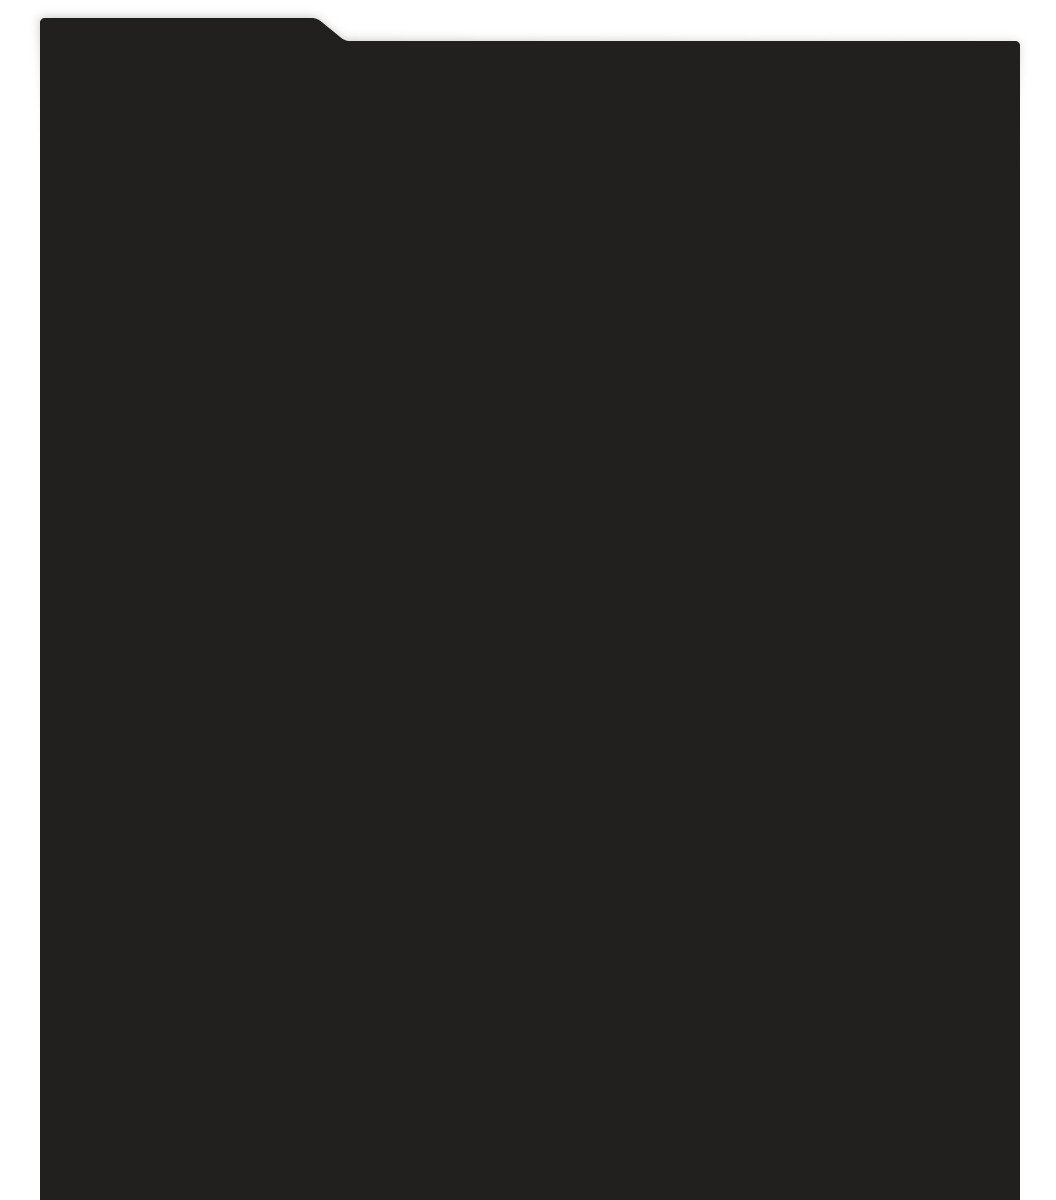
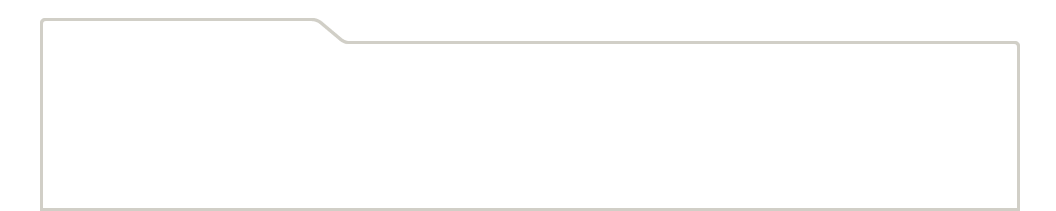
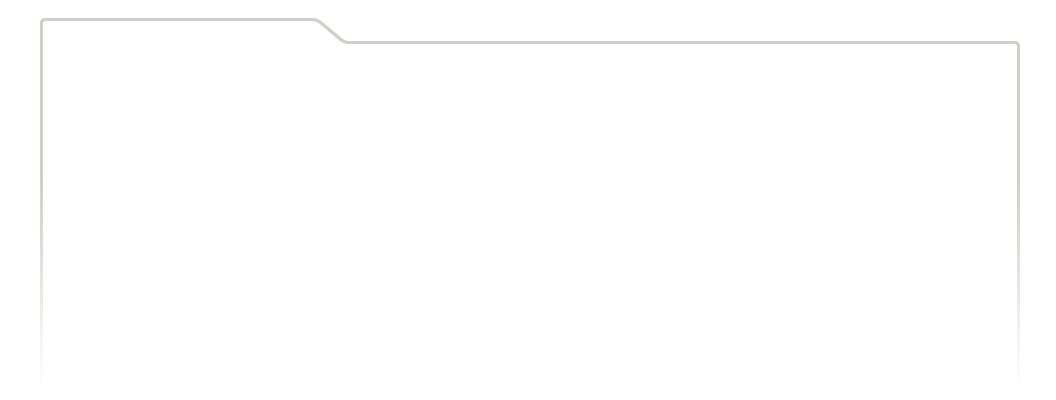
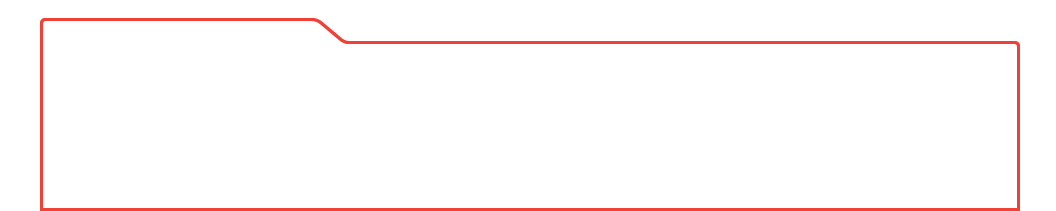
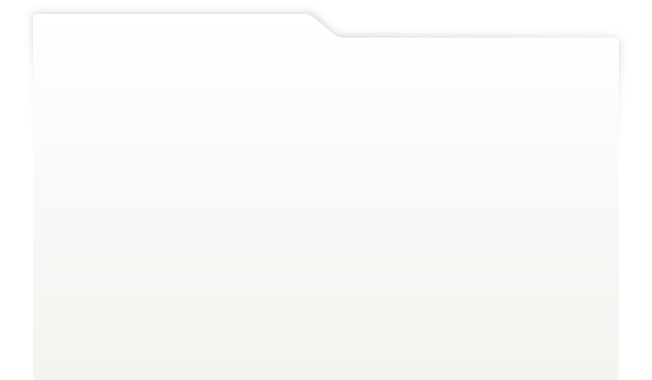
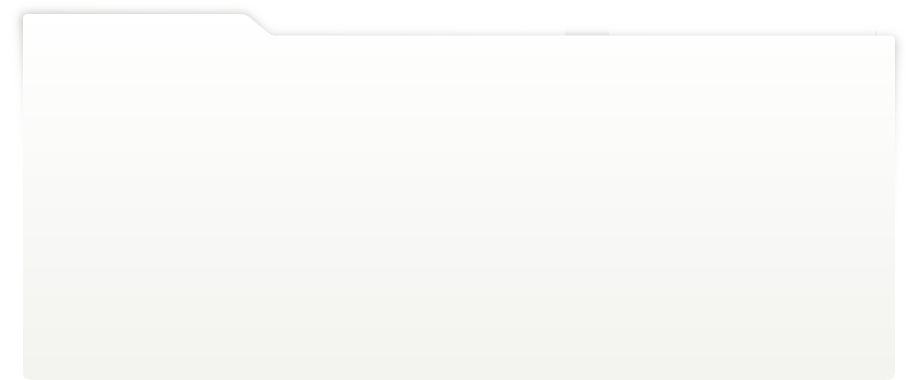
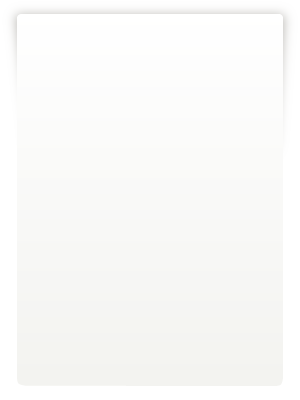
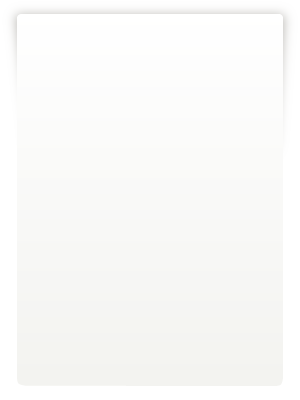
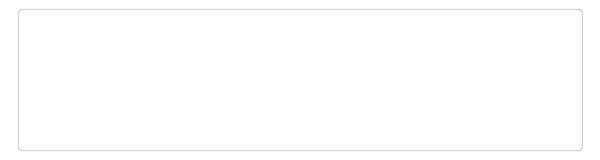
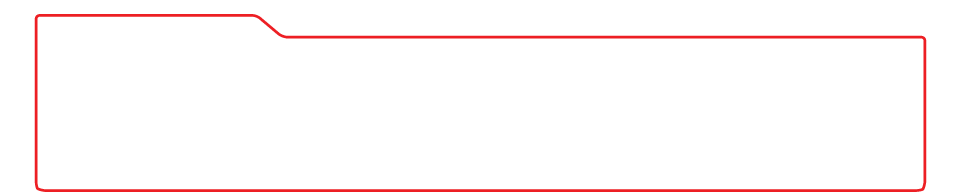
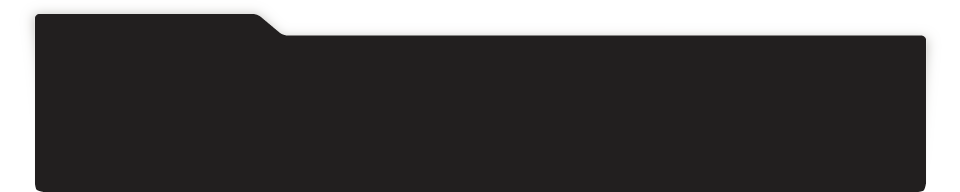
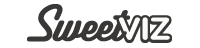
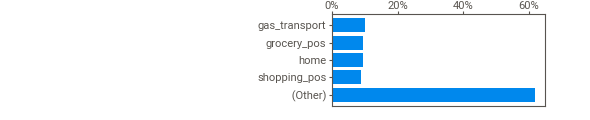
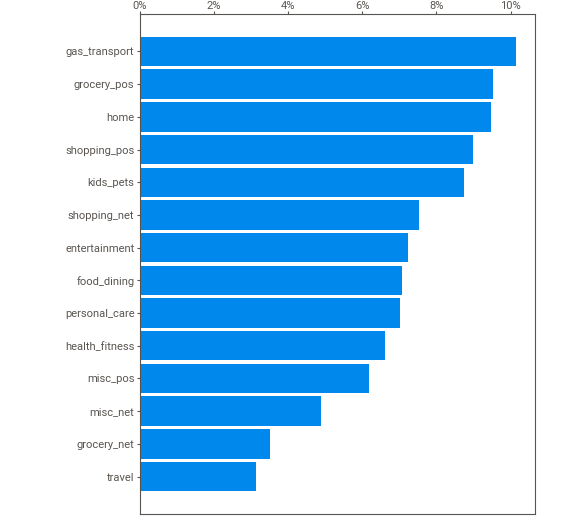
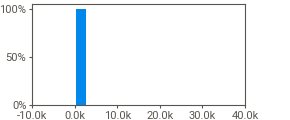
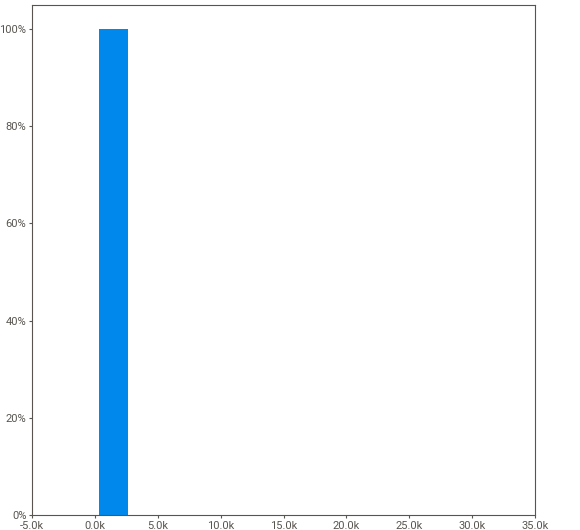
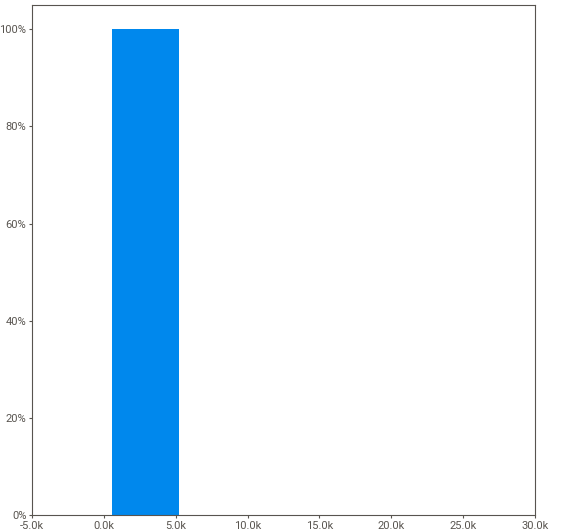
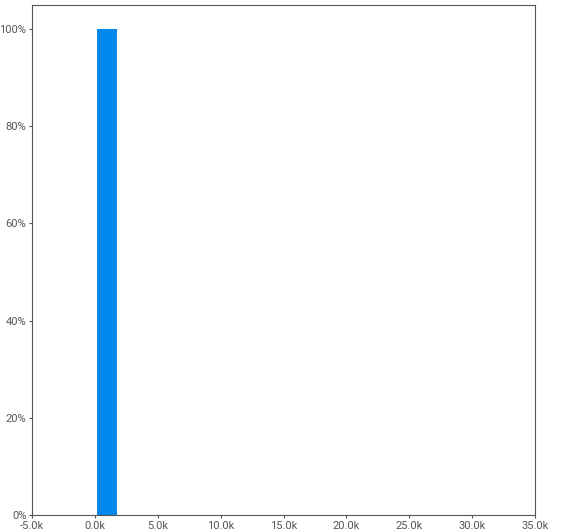
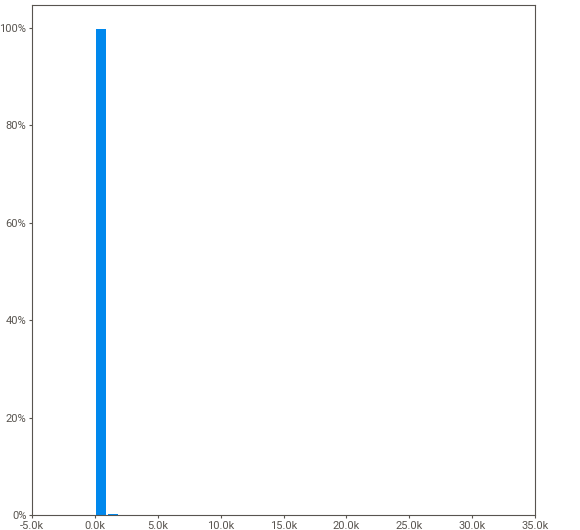
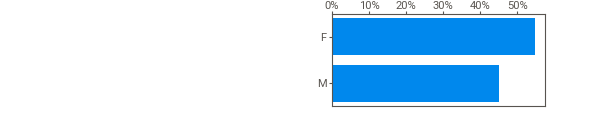
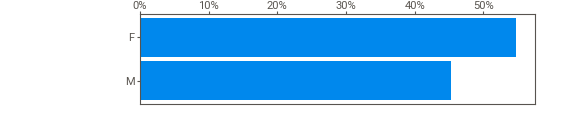
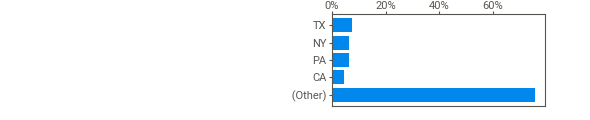
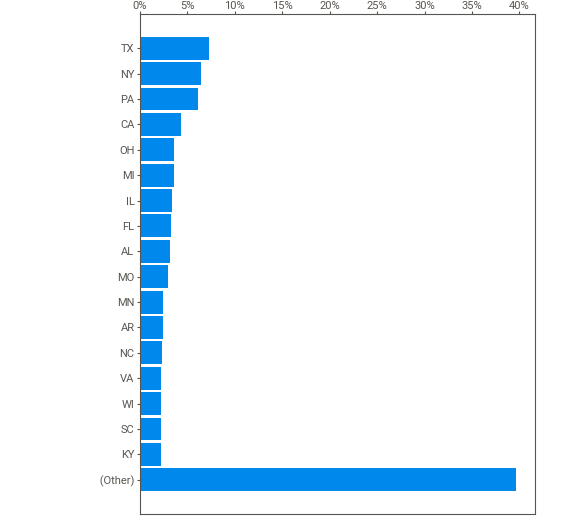
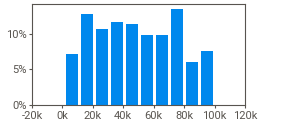
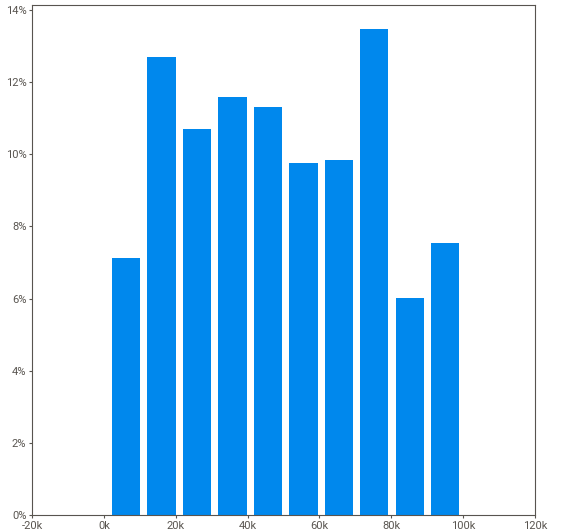
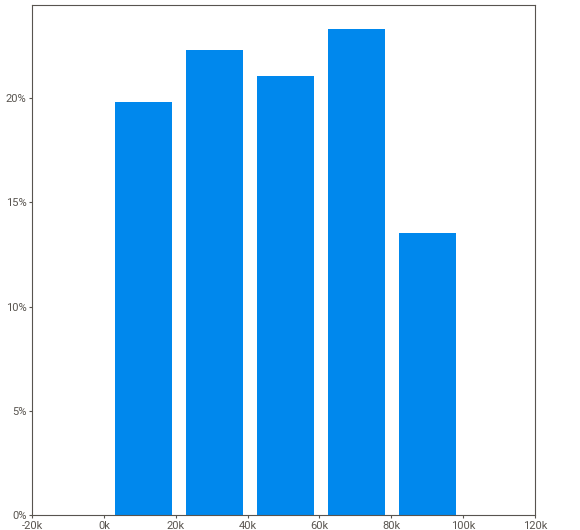
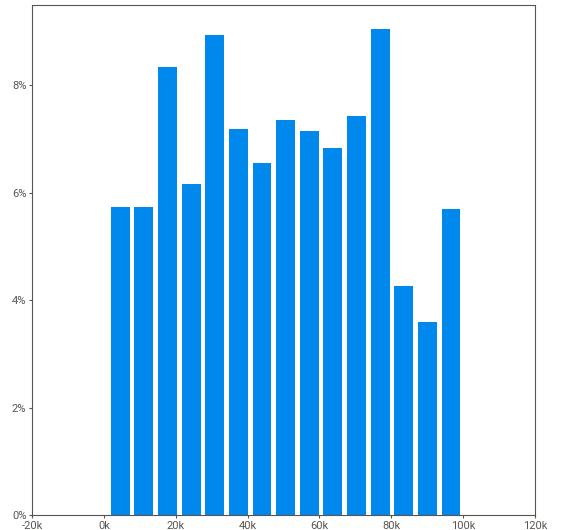
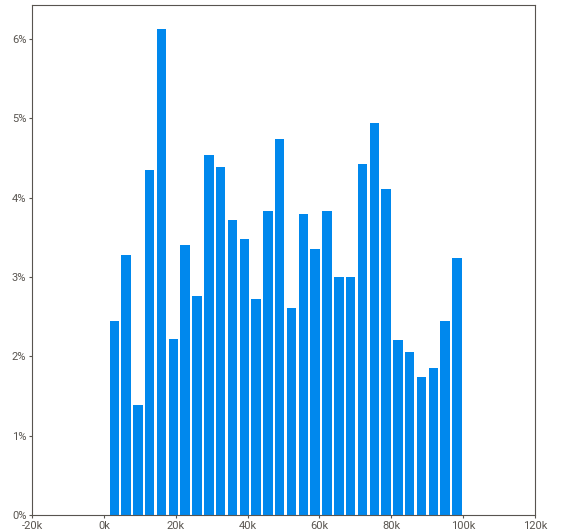
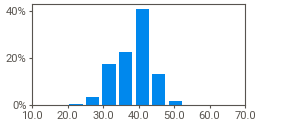
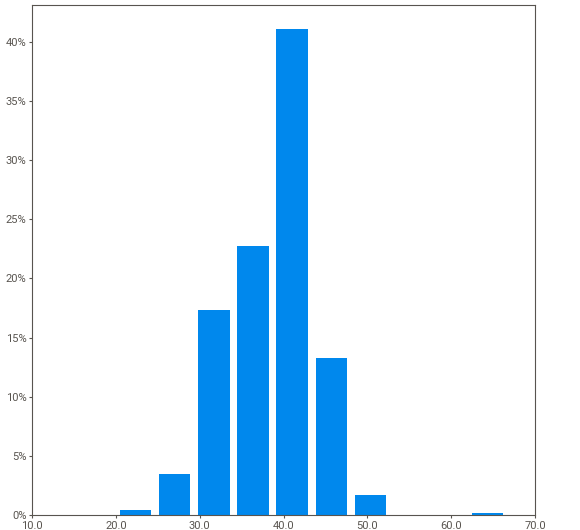
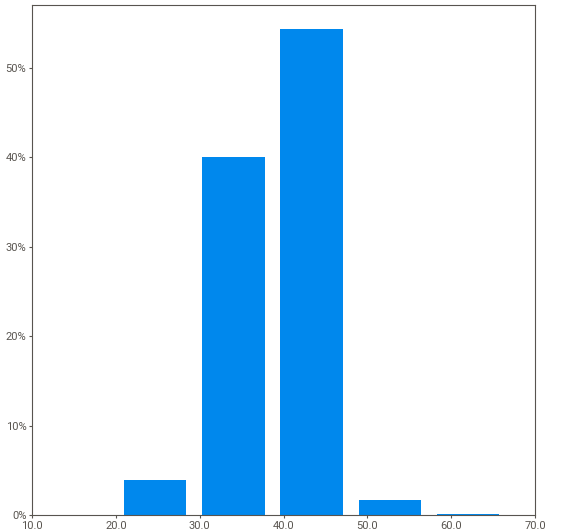
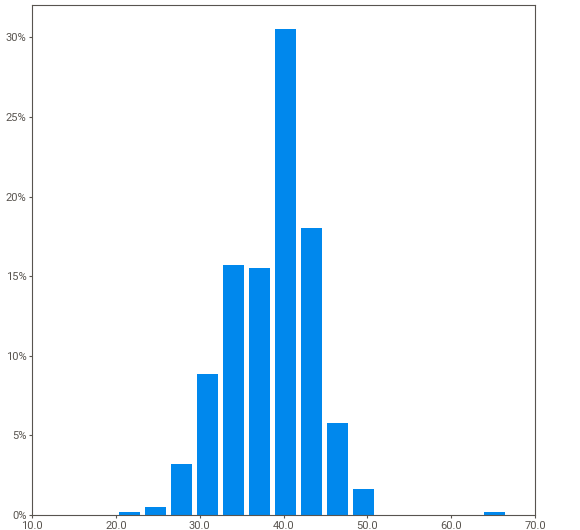
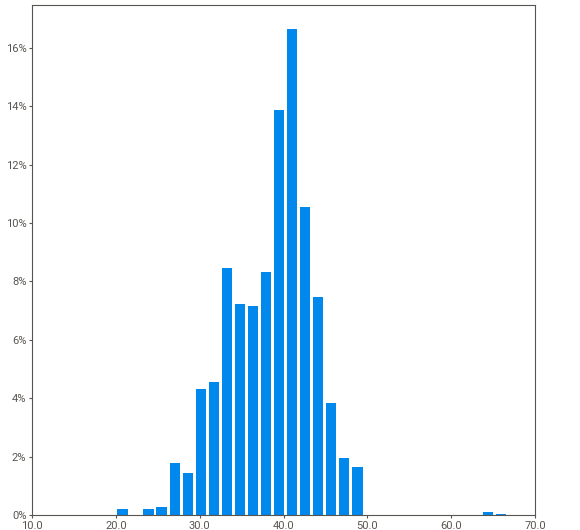
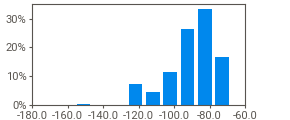
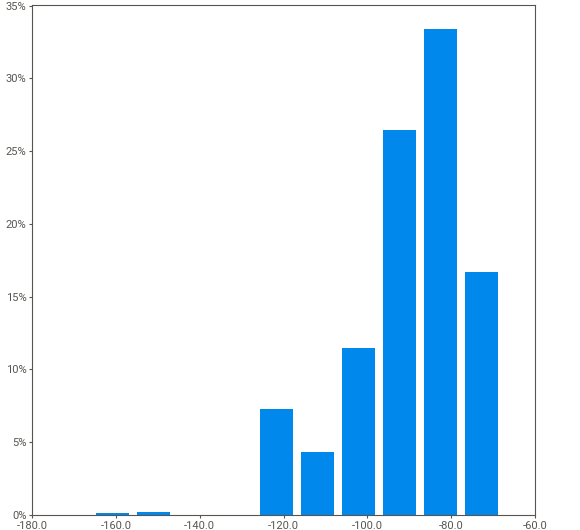
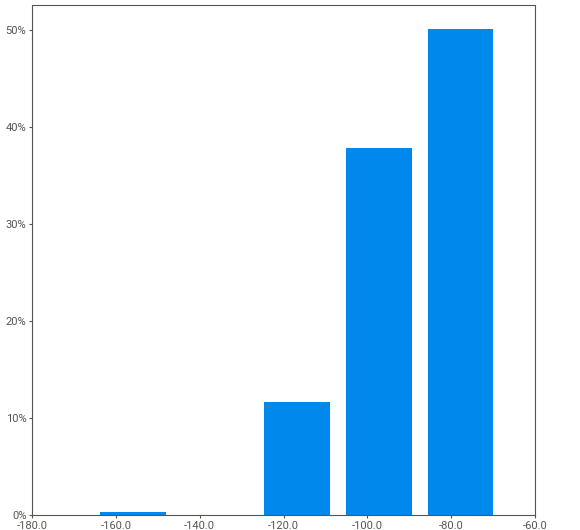
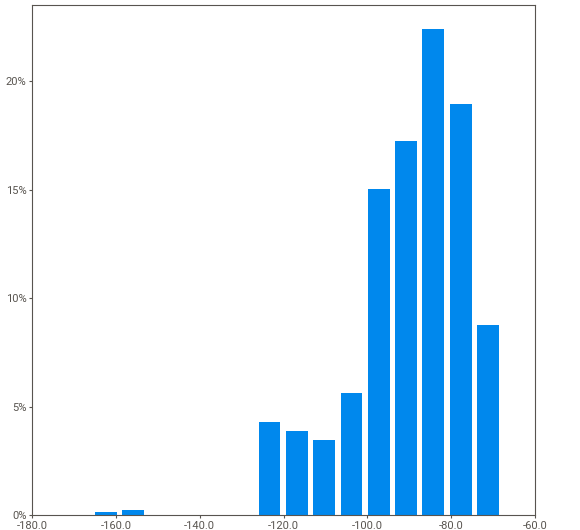
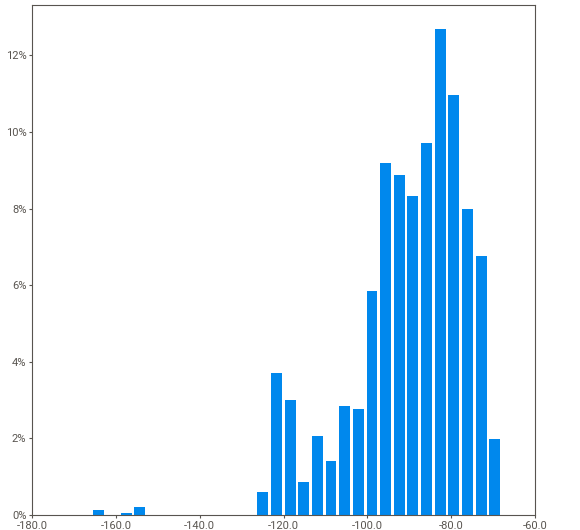
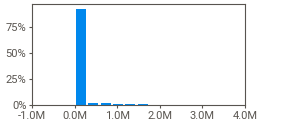
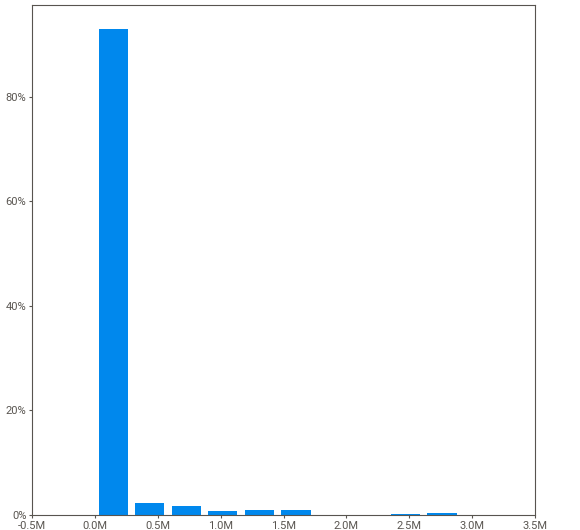
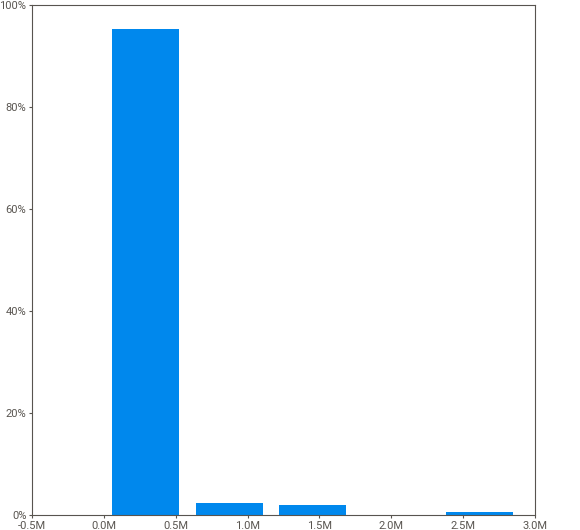
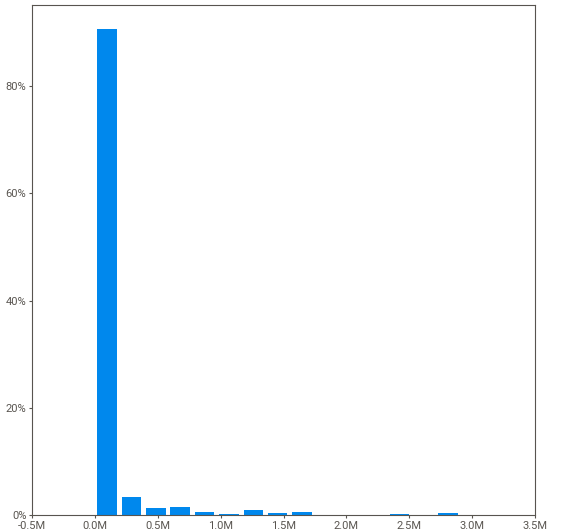
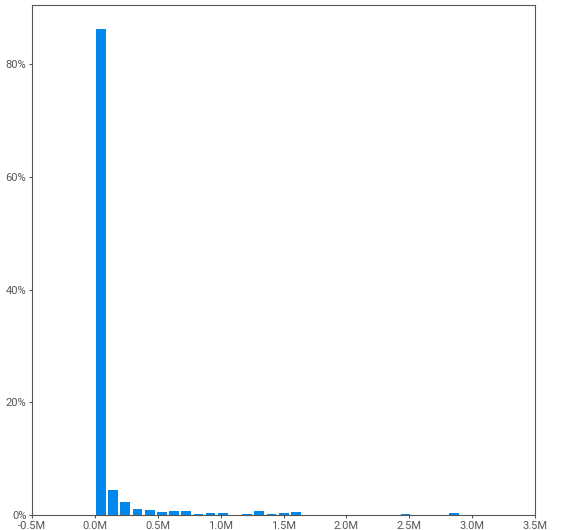
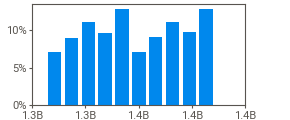
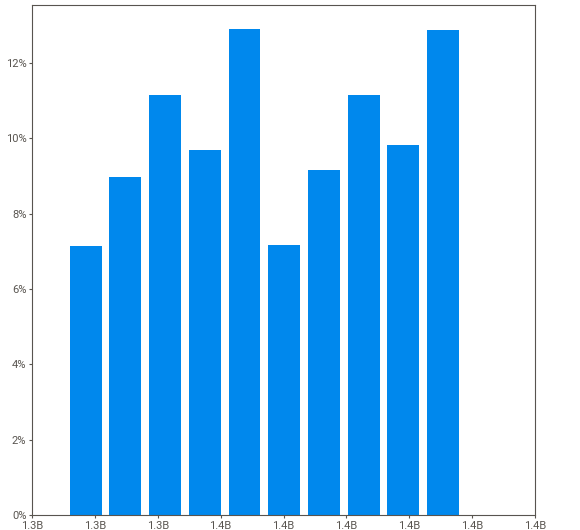
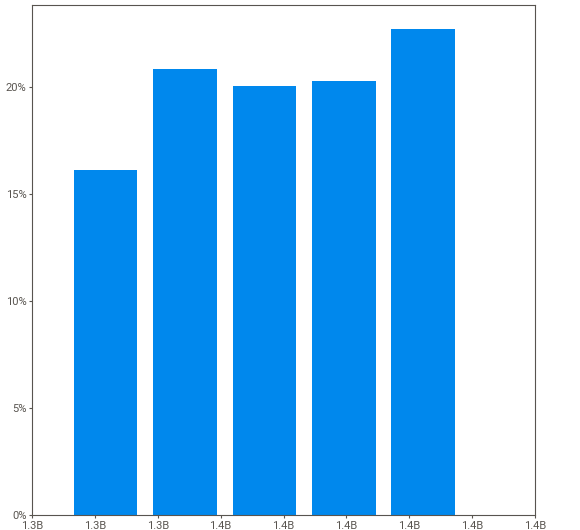
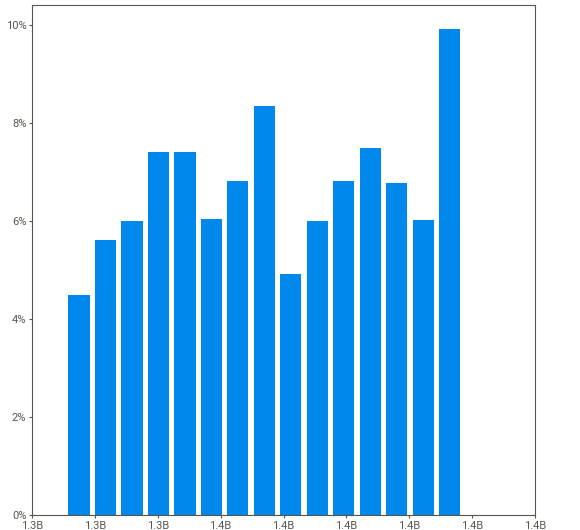
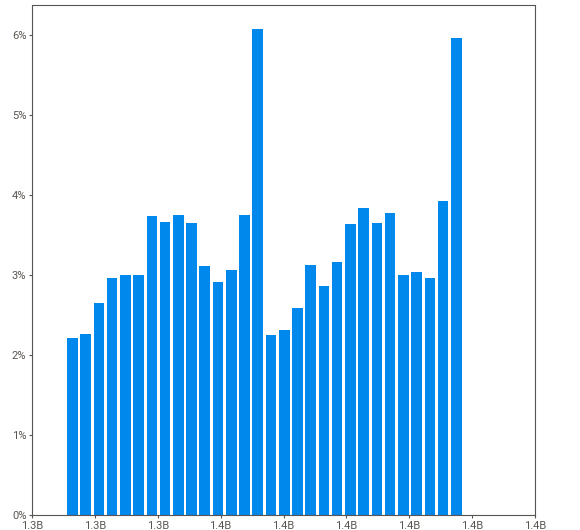
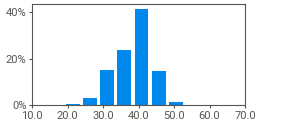
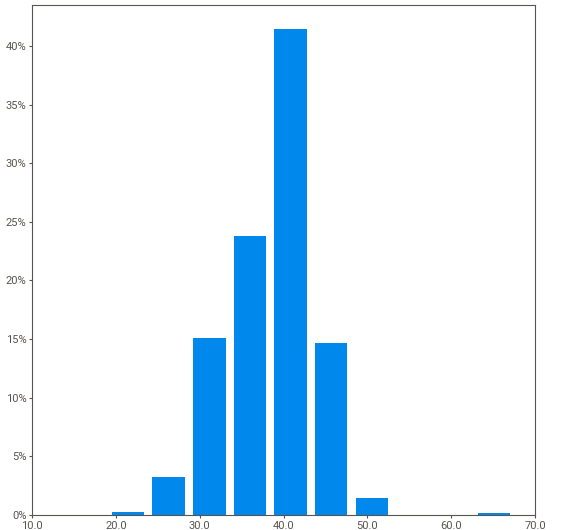
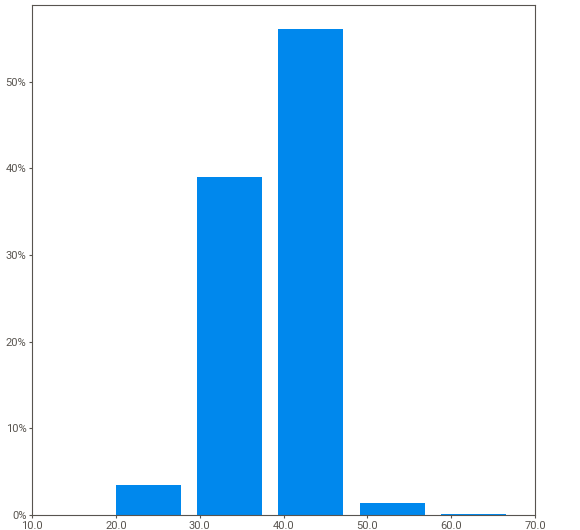
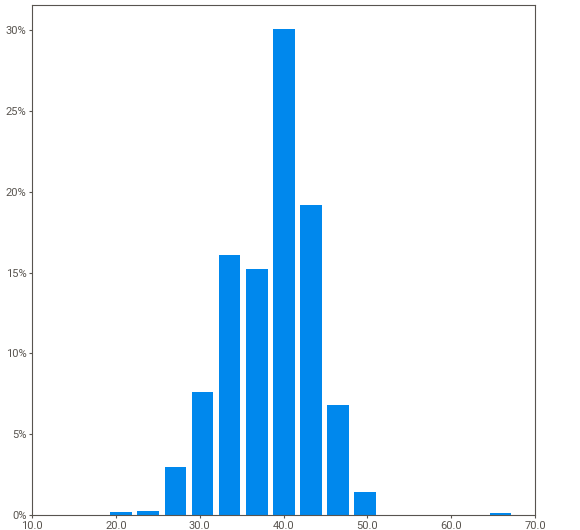
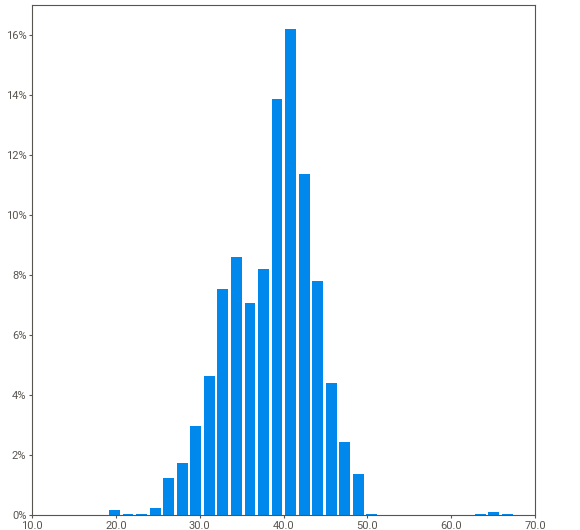
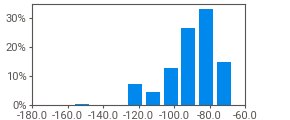
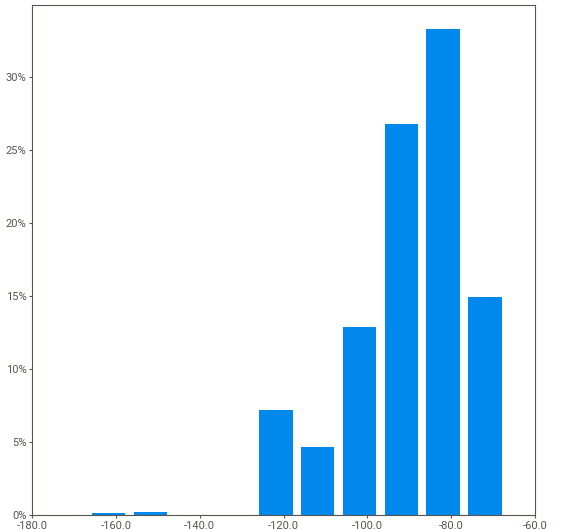
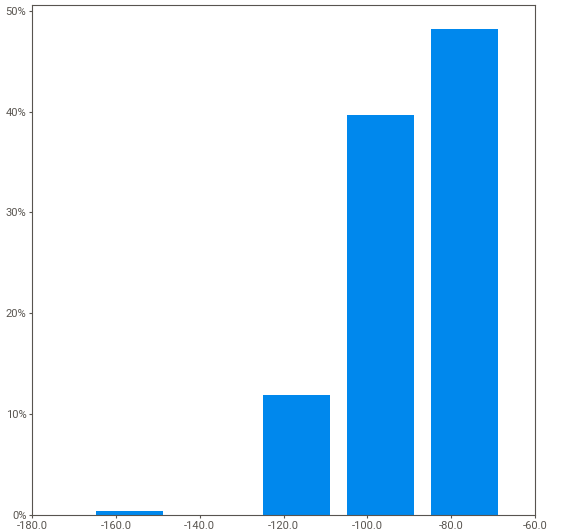
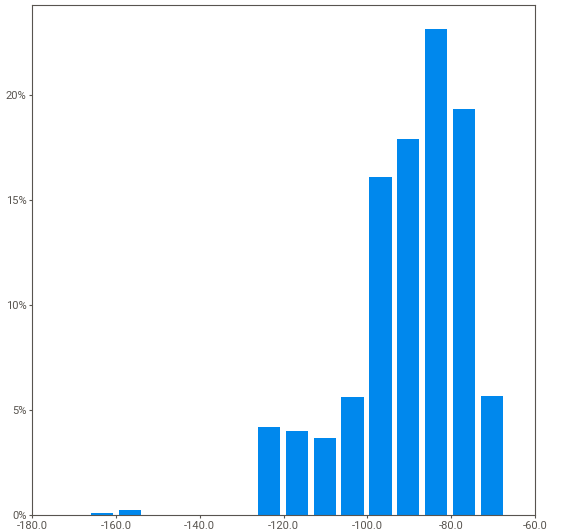
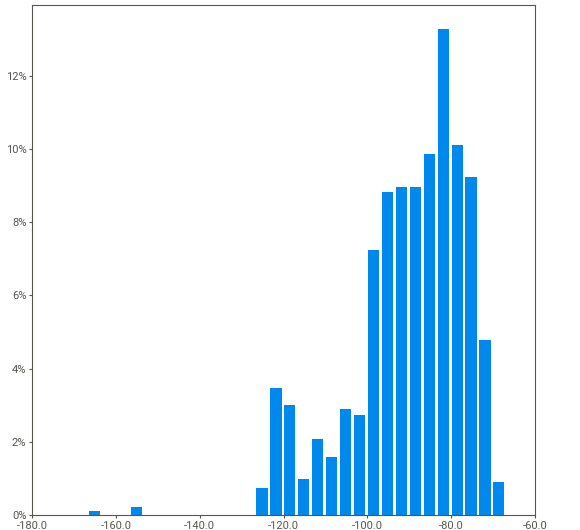
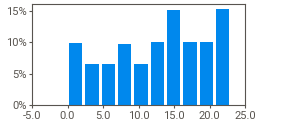
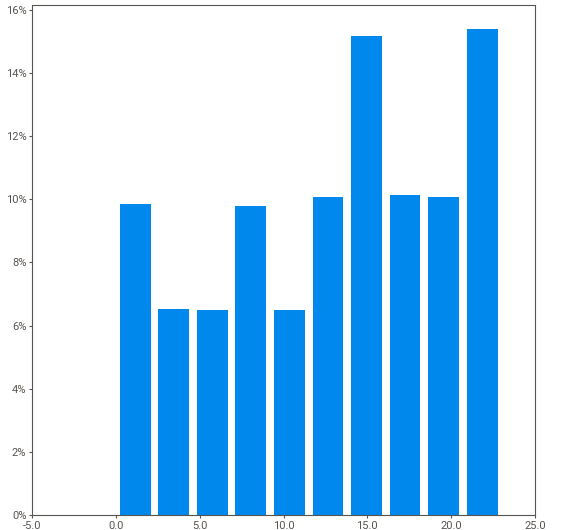
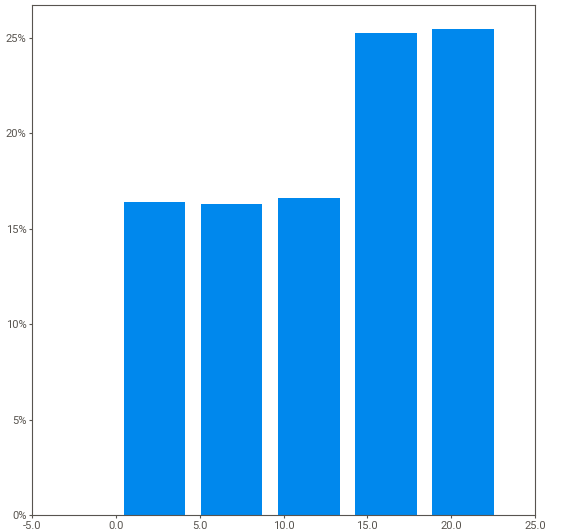
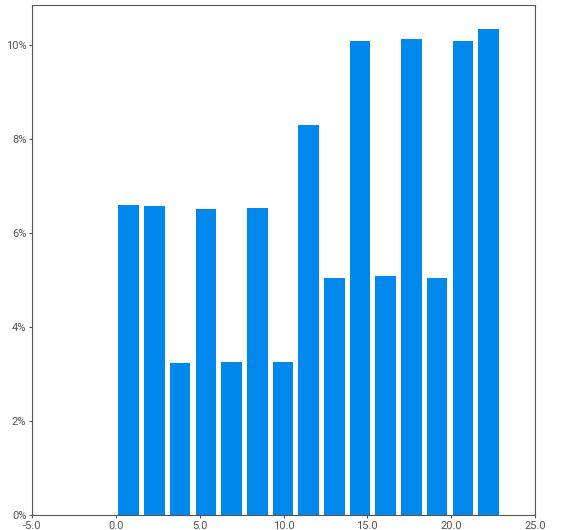
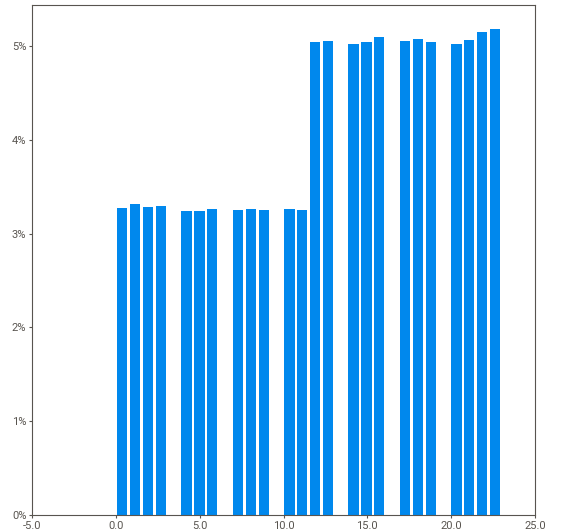
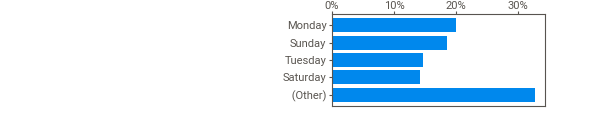
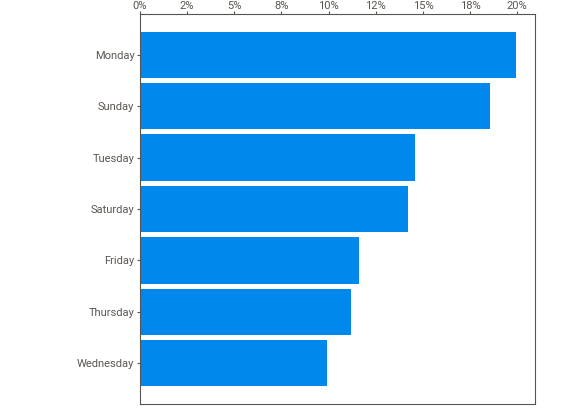
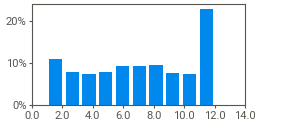
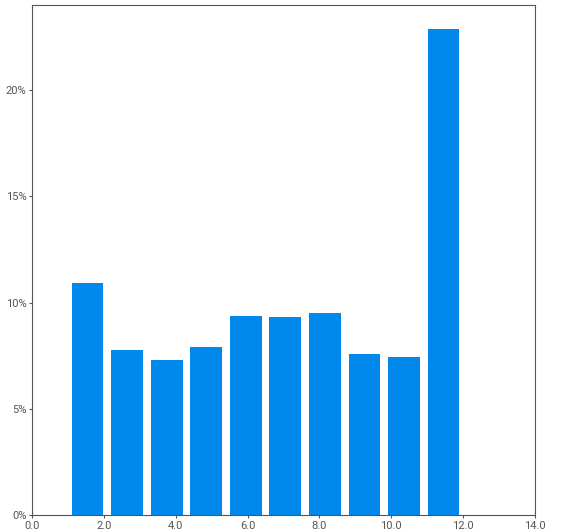
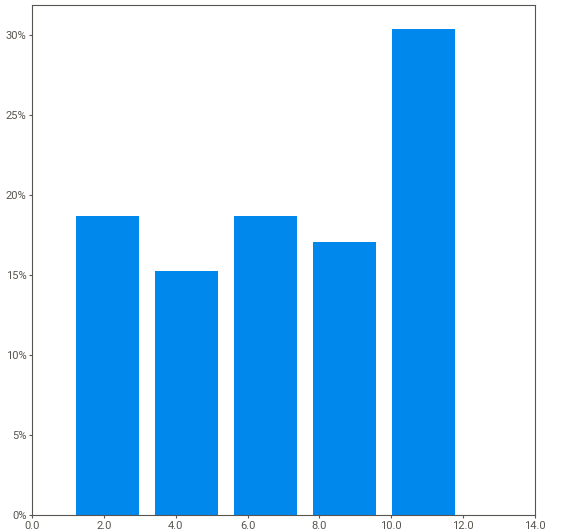
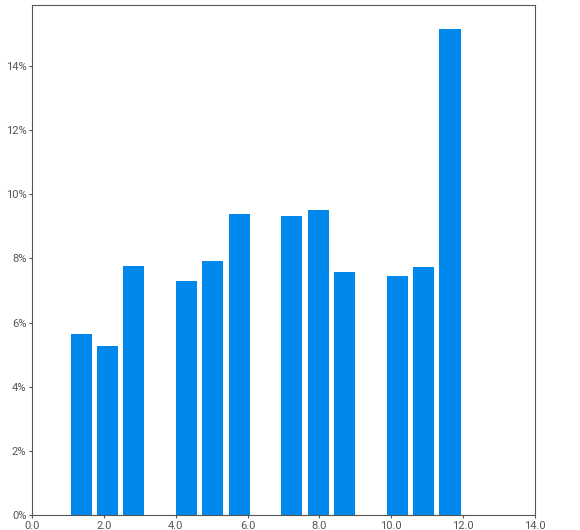
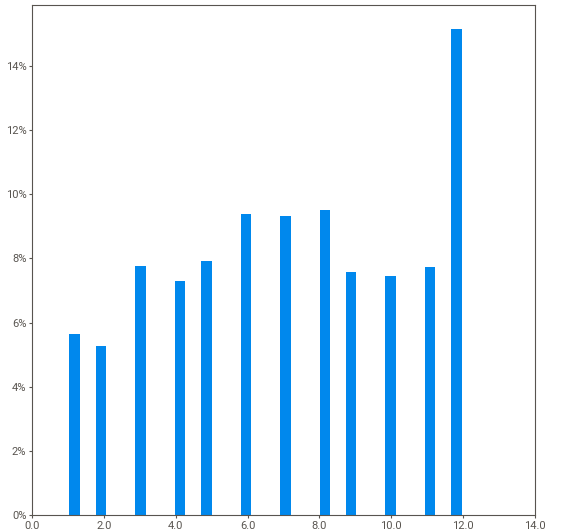
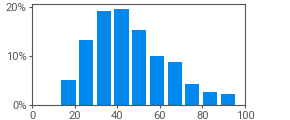
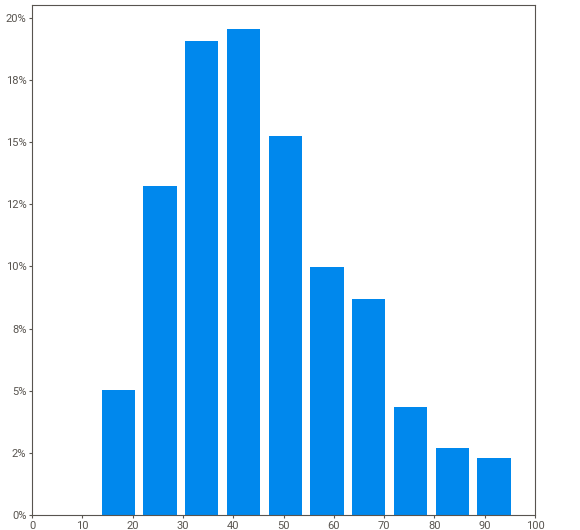
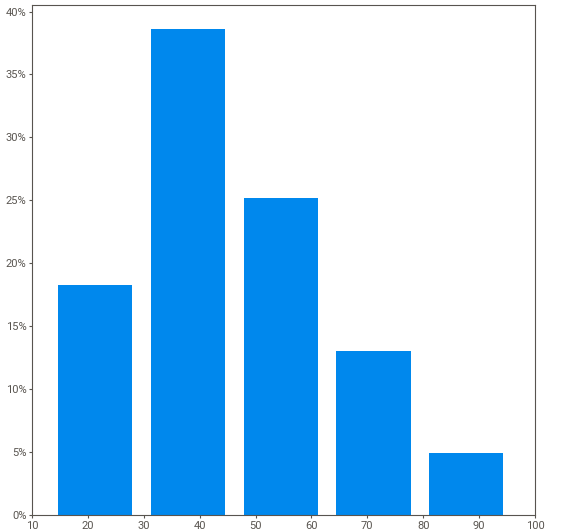
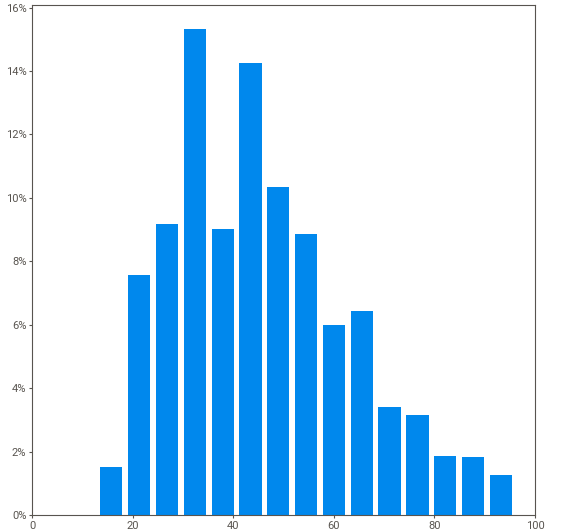
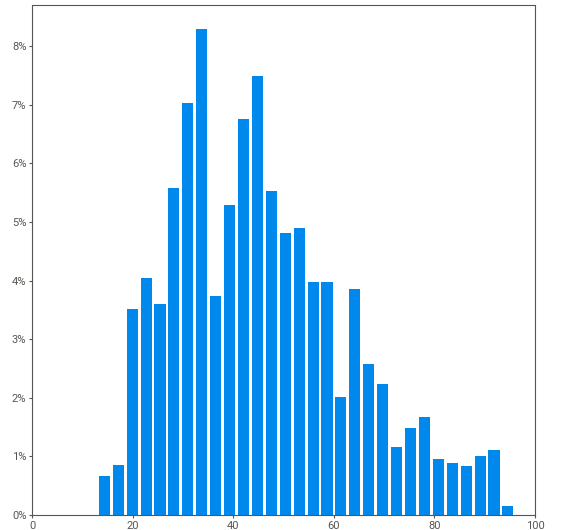
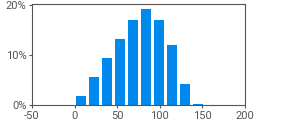
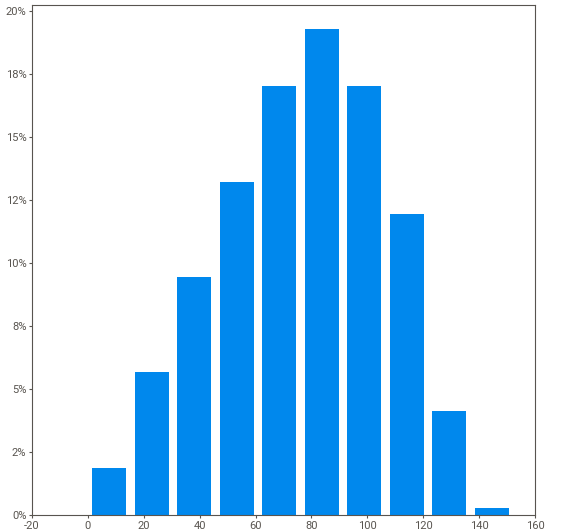
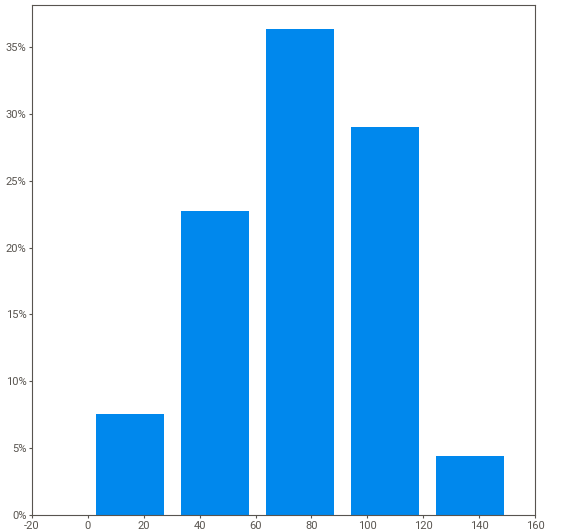
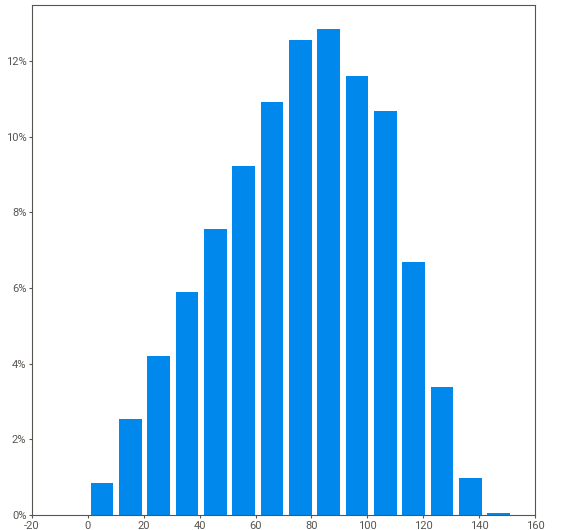
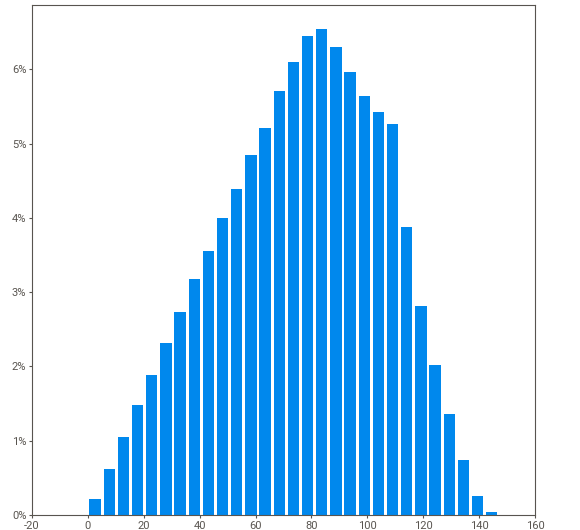
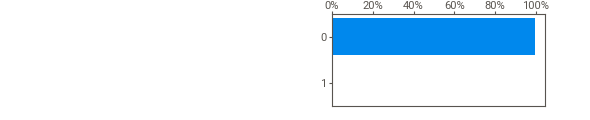
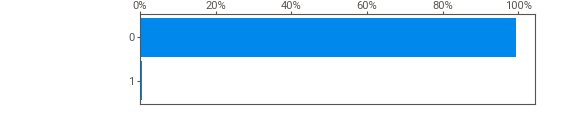
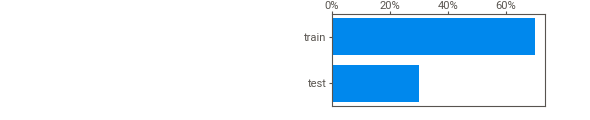
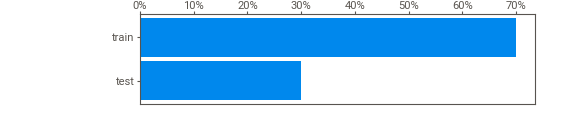
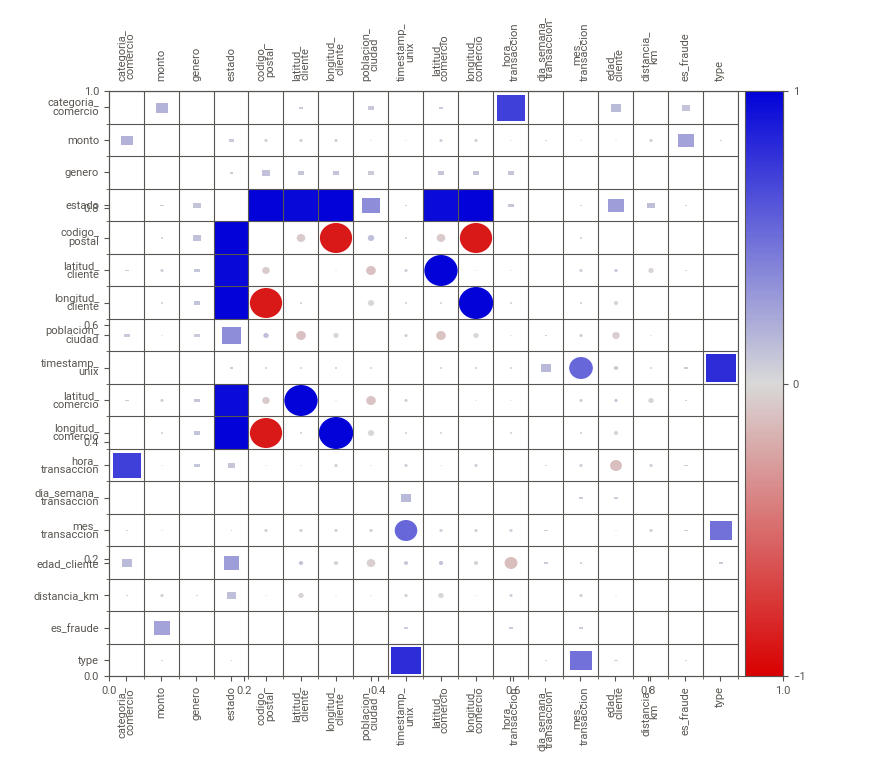
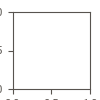

In [22]:
import sweetviz as sv

report = sv.analyze(transactions_clean_v1)
report.show_notebook()

In [23]:
from pathlib import Path

current = Path.cwd().resolve()

# Si estás en notebooks, la raíz es la carpeta anterior
project_root = current.parent

output_dir = project_root / "data" / "interim"
output_dir.mkdir(parents=True, exist_ok=True)

transactions_clean_v1.to_csv(
    output_dir / "transactions_clean_v2.csv",
    index=False
)

print(f"Archivo guardado en: {output_dir.resolve()}")

Archivo guardado en: C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\interim


# Semana 5

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

from scipy import sparse
from scipy.sparse import save_npz, hstack

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD

import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [4]:
current = Path.cwd().resolve()
print("Estoy trabajando en:", current)

# Si estás dentro de la carpeta notebooks
project_root = current.parent

input_path = project_root / "data" / "interim" / "transactions_clean_v2.csv"

print("Buscando archivo en:")
print(input_path)

if not input_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {input_path}")

df = pd.read_csv(input_path)

print("Archivo cargado correctamente")
print("Shape:", df.shape)

display(df.head())

Estoy trabajando en: C:\Users\karim\Downloads\UPC 2026-1\BigData\Fraud-Project\notebooks
Buscando archivo en:
C:\Users\karim\Downloads\UPC 2026-1\BigData\Fraud-Project\data\interim\transactions_clean_v2.csv
Archivo cargado correctamente
Shape: (1852394, 24)


,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011,-82.048,0,Tuesday,1,30,78.598,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1325376044,49.159,-118.186,0,Tuesday,1,40,30.212,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.110,M,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,1325376051,43.151,-112.154,0,Tuesday,1,56,108.206,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,1325376076,47.034,-112.561,0,Tuesday,1,51,95.673,240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.960,M,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,1325376186,38.675,-78.632,0,Tuesday,1,32,77.557,3984,0,train


In [5]:
#cantidad de unicos por columna

for col in df.columns:
    num_unicos = df[col].nunique()
    print(f"{col}: {num_unicos} únicos")

fecha_hora_transaccion: 1819551 únicos
comercio: 693 únicos
categoria_comercio: 14 únicos
monto: 60616 únicos
genero: 2 únicos
ciudad: 906 únicos
estado: 51 únicos
codigo_postal: 985 únicos
latitud_cliente: 983 únicos
longitud_cliente: 983 únicos
poblacion_ciudad: 891 únicos
ocupacion: 497 únicos
fecha_nacimiento: 984 únicos
timestamp_unix: 1819583 únicos
latitud_comercio: 1754157 únicos
longitud_comercio: 1809753 únicos
hora_transaccion: 24 únicos
dia_semana_transaccion: 7 únicos
mes_transaccion: 12 únicos
edad_cliente: 84 únicos
distancia_km: 1852394 únicos
tarjeta_ultimos4: 933 únicos
es_fraude: 2 únicos
type: 2 únicos


In [6]:
print("Columnas disponibles:")
for col in df.columns:
    print("-", col)

# Detectar automáticamente la columna objetivo
if "es_fraude" in df.columns:
    target_col = "es_fraude"
elif "is_fraud" in df.columns:
    target_col = "is_fraud"
else:
    raise ValueError("No se encontró la columna objetivo: es_fraude o is_fraud")

print("\nTarget usado:", target_col)
print(df[target_col].value_counts())

Columnas disponibles:
- fecha_hora_transaccion
- comercio
- categoria_comercio
- monto
- genero
- ciudad
- estado
- codigo_postal
- latitud_cliente
- longitud_cliente
- poblacion_ciudad
- ocupacion
- fecha_nacimiento
- timestamp_unix
- latitud_comercio
- longitud_comercio
- hora_transaccion
- dia_semana_transaccion
- mes_transaccion
- edad_cliente
- distancia_km
- tarjeta_ultimos4
- es_fraude
- type

Target usado: es_fraude
es_fraude
0    1842743
1       9651
Name: count, dtype: int64


In [7]:
df_features = df[df["type"]=="train"].copy()
df_features_test = df[df["type"]=="test"].copy()

# Convertir fechas
if "fecha_hora_transaccion" in df_features.columns:
    df_features["fecha_hora_transaccion"] = pd.to_datetime(
        df_features["fecha_hora_transaccion"],
        errors="coerce"
    )
    df_features_test["fecha_hora_transaccion"] = pd.to_datetime(
        df_features_test["fecha_hora_transaccion"],
        errors="coerce"
    )

if "fecha_nacimiento" in df_features.columns:
    df_features["fecha_nacimiento"] = pd.to_datetime(
        df_features["fecha_nacimiento"],
        errors="coerce"
    )
    df_features_test["fecha_nacimiento"] = pd.to_datetime(
        df_features_test["fecha_nacimiento"],
        errors="coerce"
    )

# Crear features temporales a partir de fecha_hora_transaccion
if "fecha_hora_transaccion" in df_features.columns:
    df_features["hora_transaccion"] = df_features["fecha_hora_transaccion"].dt.hour
    df_features["dia_semana_num"] = df_features["fecha_hora_transaccion"].dt.dayofweek
    df_features["dia_semana_transaccion"] = df_features["fecha_hora_transaccion"].dt.day_name()
    df_features["mes_transaccion"] = df_features["fecha_hora_transaccion"].dt.month

    df_features_test["hora_transaccion"] = df_features_test["fecha_hora_transaccion"].dt.hour
    df_features_test["dia_semana_num"] = df_features_test["fecha_hora_transaccion"].dt.dayofweek
    df_features_test["dia_semana_transaccion"] = df_features_test["fecha_hora_transaccion"].dt.day_name()
    df_features_test["mes_transaccion"] = df_features_test["fecha_hora_transaccion"].dt.month

# Feature: fin de semana
if "dia_semana_num" in df_features.columns:
    df_features["es_fin_de_semana"] = df_features["dia_semana_num"].isin([5, 6]).astype(int)

    df_features_test["es_fin_de_semana"] = df_features_test["dia_semana_num"].isin([5, 6]).astype(int)

# Features cíclicas para hora
if "hora_transaccion" in df_features.columns:
    df_features["hora_sin"] = np.sin(2 * np.pi * df_features["hora_transaccion"] / 24)
    df_features["hora_cos"] = np.cos(2 * np.pi * df_features["hora_transaccion"] / 24)

    df_features_test["hora_sin"] = np.sin(2 * np.pi * df_features_test["hora_transaccion"] / 24)
    df_features_test["hora_cos"] = np.cos(2 * np.pi * df_features_test["hora_transaccion"] / 24)
    

# Features cíclicas para mes
if "mes_transaccion" in df_features.columns:
    df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes_transaccion"] / 12)
    df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes_transaccion"] / 12)

    df_features_test["mes_sin"] = np.sin(2 * np.pi * df_features_test["mes_transaccion"] / 12)
    df_features_test["mes_cos"] = np.cos(2 * np.pi * df_features_test["mes_transaccion"] / 12)

# Feature: periodo del día
def clasificar_periodo(hora):
    if pd.isna(hora):
        return "desconocido"
    elif 0 <= hora <= 5:
        return "madrugada"
    elif 6 <= hora <= 11:
        return "mañana"
    elif 12 <= hora <= 17:
        return "tarde"
    else:
        return "noche"

if "hora_transaccion" in df_features.columns:
    df_features["periodo_dia"] = df_features["hora_transaccion"].apply(clasificar_periodo)

    df_features_test["periodo_dia"] = df_features_test["hora_transaccion"].apply(clasificar_periodo)

# Feature: log del monto
if "monto" in df_features.columns:
    df_features["log_monto"] = np.log1p(df_features["monto"])

    df_features_test["log_monto"] = np.log1p(df_features_test["monto"])



# Texto combinado para representación textual
#text_cols = [c for c in ["comercio", "ocupacion"] if c in df_features.columns]

#if len(text_cols) > 0:
    #df_features["texto_comercio_ocupacion"] = (
        #df_features[text_cols]
        #.fillna("")
        #.astype(str)
        #.agg(" ".join, axis=1)
 #   )
#else:
   # df_features["texto_comercio_ocupacion"] = ""



print("Shape después de feature engineering:", df_features.shape)
print("Shape test después de feature engineering:", df_features_test.shape  )
#display(df_features["texto_comercio_ocupacion"].head())

Shape después de feature engineering: (1296675, 32)
Shape test después de feature engineering: (555719, 32)


In [8]:
df_features_test["es_fraude"].value_counts()

es_fraude
0    553574
1      2145
Name: count, dtype: int64

Regarding time features, we chose cyclical time features for hour and month using sine and cosine transforms. Because hour and month “wrap around” (23 is close to 0; December is close to January), treating them as plain integers can mislead models. The code maps hour and month onto a circle via

- $hora\_sin = \sin\!\left(2\pi \cdot \frac{hora}{24}\right)$ and $hora\_cos = \cos\!\left(2\pi \cdot \frac{hora}{24}\right)$  
- $mes\_sin = \sin\!\left(2\pi \cdot \frac{mes}{12}\right)$ and $mes\_cos = \cos\!\left(2\pi \cdot \frac{mes}{12}\right)$ 

 using both sine and cosine preserves the circular structure (each time point maps to a unique position on the unit circle), which often helps linear models and tree-based models learn smooth periodic patterns without creating an artificial “gap” at the boundary

In [9]:
MAX_ROWS = 75000
MAX_FRAUD = 7500

df_features[target_col] = pd.to_numeric(df_features[target_col], errors="coerce")

df_valid = df_features.dropna(subset=[target_col]).copy()
df_valid[target_col] = df_valid[target_col].astype(int)

if len(df_valid) > MAX_ROWS:
    df_fraud = df_valid[df_valid[target_col] == 1]
    df_normal = df_valid[df_valid[target_col] == 0]
    
    n_fraud = min(len(df_fraud), MAX_FRAUD)
    n_normal = min(len(df_normal), MAX_ROWS - n_fraud)
    
    df_model = pd.concat([
        df_fraud.sample(n=n_fraud, random_state=RANDOM_STATE),
        df_normal.sample(n=n_normal, random_state=RANDOM_STATE)
    ])
    
    df_model = df_model.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model = df_valid.copy().reset_index(drop=True)

#para el test

MAX_TEST_ROWS = 21000
MAX_TEST_FRAUD = 2100
df_features_test[target_col] = pd.to_numeric(df_features_test[target_col], errors="coerce")

df_valid_test = df_features_test.dropna(subset=[target_col]).copy()
df_valid_test[target_col] = df_valid_test[target_col].astype(int)

if len(df_valid_test) > MAX_TEST_ROWS:
    df_fraud_test = df_valid_test[df_valid_test[target_col] == 1]
    df_normal_test = df_valid_test[df_valid_test[target_col] == 0]
    
    n_fraud_test = min(len(df_fraud_test), MAX_TEST_FRAUD)
    n_normal_test = min(len(df_normal_test), MAX_TEST_ROWS - n_fraud_test)
    
    df_model_test = pd.concat([
        df_fraud_test.sample(n=n_fraud_test, random_state=RANDOM_STATE),
        df_normal_test.sample(n=n_normal_test, random_state=RANDOM_STATE)
    ])
    
    df_model_test = df_model_test.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model_test = df_valid_test.copy().reset_index(drop=True)

#y = df_model[target_col].values

print()
print("Shape de muestra usada:", df_model.shape)
print("Distribución del target:")
print(df_model[target_col].value_counts())

print()
print("Shape de muestra usada:", df_model_test.shape)
print("Distribución del target:")
print(df_model_test[target_col].value_counts())


Shape de muestra usada: (75000, 32)
Distribución del target:
es_fraude
0    67500
1     7500
Name: count, dtype: int64

Shape de muestra usada: (21000, 32)
Distribución del target:
es_fraude
0    18900
1     2100
Name: count, dtype: int64


In [10]:
df_features_test.shape

(555719, 32)

In [11]:
numeric_candidates = [
    #"monto",
    "log_monto",
    #"latitud_cliente",
    #"longitud_cliente",
    "poblacion_ciudad",
    #"latitud_comercio",
    #"longitud_comercio",
    #"timestamp_unix",
    #"hora_transaccion",
    "dia_semana_num",
    "mes_transaccion",
    "edad_cliente",
    "distancia_km",
    "es_fin_de_semana",
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",
    "es_fraude"  
]


low_cardinality = [
    "genero",
    "categoria_comercio",
    "dia_semana_transaccion",
    "periodo_dia",
    "estado"
]

high_cardinality = [
    "ciudad",
    "comercio",
    "ocupacion",
    "codigo_postal"
]

drop_features = [
    "timestamp_unix",
    "hora_transaccion",
    "mes_transaccion",
    "dia_semana_num",
    "type"
]

df_model = df_model.drop(columns=[c for c in drop_features if c in df_model.columns])
numeric_features = [c for c in numeric_candidates if c in df_model.columns]
categorical_features = [c for c in low_cardinality+high_cardinality if c in df_model.columns]



print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

#print("\nVariable de texto:")
#print(text_feature)

Variables numéricas:
['log_monto', 'poblacion_ciudad', 'edad_cliente', 'distancia_km', 'es_fin_de_semana', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'es_fraude']

Variables categóricas:
['genero', 'categoria_comercio', 'dia_semana_transaccion', 'periodo_dia', 'estado', 'ciudad', 'comercio', 'ocupacion', 'codigo_postal']


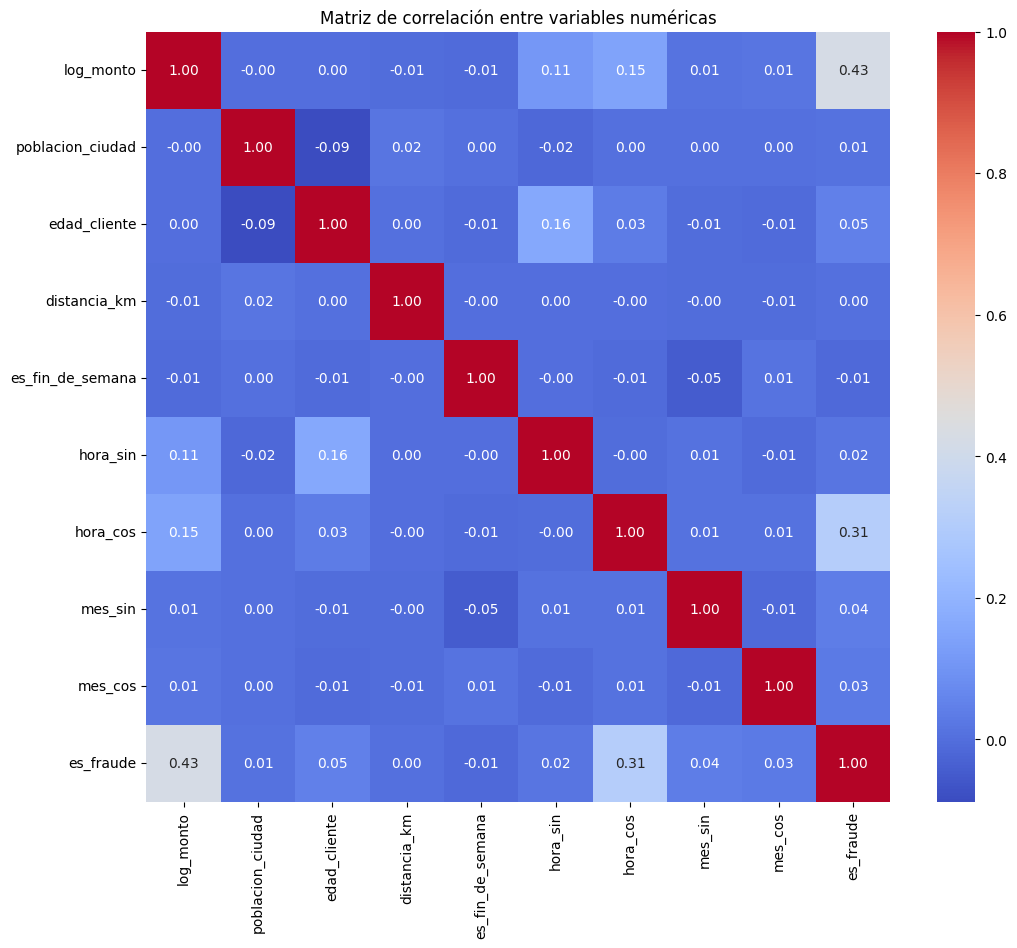

In [12]:
## Correlation matrix
import seaborn as sns   
correlation_matrix = df_model.loc[:,numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,          # Annotate cells
            fmt=".2f",           # 2 decimal places
            cmap='coolwarm',     # Color scheme
            annot_kws={"size": 10}) # Font size

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

By analyzing the correlation matrix, we can gain insights into which features are most informative for the dependent variable “es_fraude.” In this case, we observe that “monto” has a strong correlation with the target variable, which makes sense since fraudulent transactions are often associated with higher amounts.

On the other hand, correlation analysis can also help us identify redundant features. For example, “es_fin_de_semana” shows a high correlation with “dia_de_semana_num,” indicating that both variables capture similar information. This redundancy suggests that one of them can be removed, selecting the feature that contributes more effectively to the model.

This process is important for several reasons, including reducing redundancy, avoiding unnecessary complexity, and improving model interpretability.

## OnehotEncoding

In [13]:
try:
    from category_encoders import TargetEncoder
except Exception as e:
    import sys, subprocess
    print("category_encoders no está instalado. Intentando instalarlo en el kernel:", sys.executable)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'category_encoders'])
    from category_encoders import TargetEncoder
def crear_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

low_card_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])


text_pipeline = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=300,
        min_df=2,
        ngram_range=(1, 2)
    ))
])

if "es_fraude" in numeric_features:
    numeric_features = [c for c in numeric_features if c != "es_fraude"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("low_cat", low_card_pipeline, low_cardinality),
        ("high_cat", high_card_pipeline, high_cardinality)
    ]
)

X_train = df_model.drop(columns=["es_fraude"])
y_train = df_model["es_fraude"]

X_test = df_model_test.drop(columns=["es_fraude"])
y_test = df_model_test["es_fraude"]

X_features = preprocessor.fit_transform(X_train, y_train)
X_test_features = preprocessor.transform(X_test)



print("Matriz final X_features:", X_features.shape)
print("Tipo de matriz:", type(X_features))

print("Matriz final X_test_features:", X_test_features.shape)
print("Tipo de matriz:", type(X_test_features))

Matriz final X_features: (75000, 91)
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>
Matriz final X_test_features: (21000, 91)
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>


In [14]:
X_numeric = preprocessor.named_transformers_["num"].transform(
    X_train[numeric_features]
)

X_low_cat = preprocessor.named_transformers_["low_cat"].transform(
    X_train[low_cardinality]
)

X_high_cat = preprocessor.named_transformers_["high_cat"].transform(
    X_train[high_cardinality]
)

X_numeric_test = preprocessor.named_transformers_["num"].transform(
    X_test[numeric_features]
)

X_low_cat_test = preprocessor.named_transformers_["low_cat"].transform(
    X_test[low_cardinality]
)   

X_high_cat_test = preprocessor.named_transformers_["high_cat"].transform(
    X_test[high_cardinality]
)



print("Matriz numérica:", X_numeric.shape)
print("Matriz low categorical:", X_low_cat.shape)
print("Matriz high categorical:", X_high_cat.shape)
print("Matriz completa:", X_features.shape)

print("Matriz numérica test:", X_numeric_test.shape)
print("Matriz low categorical test:", X_low_cat_test.shape)
print("Matriz high categorical test:", X_high_cat_test.shape)
print("Matriz completa test:", X_test_features.shape)

Matriz numérica: (75000, 9)
Matriz low categorical: (75000, 78)
Matriz high categorical: (75000, 4)
Matriz completa: (75000, 91)
Matriz numérica test: (21000, 9)
Matriz low categorical test: (21000, 78)
Matriz high categorical test: (21000, 4)
Matriz completa test: (21000, 91)


In [15]:
feature_names = preprocessor.get_feature_names_out()

feature_names_df = pd.DataFrame({
    "feature": feature_names
})

print("Cantidad total de features:", len(feature_names_df))
display(feature_names_df.head(20))

Cantidad total de features: 91


,feature
0,num__log_monto
1,num__poblacion_ciudad
2,num__edad_cliente
3,num__distancia_km
4,num__es_fin_de_semana
5,num__hora_sin
6,num__hora_cos
7,num__mes_sin
8,num__mes_cos
9,low_cat__genero_F


## Dimensionality reduction

### PCA

In [16]:
from sklearn.decomposition import PCA

max_pca_components = X_numeric.shape[1]

pca_model = PCA(
    n_components=max_pca_components,
    random_state=42
)

X_pca = pca_model.fit_transform(X_numeric)

pca_explained = pca_model.explained_variance_ratio_
pca_cumulative = np.cumsum(pca_explained)

print("Shape PCA:", X_pca.shape)

pca_results = pd.DataFrame({
    "componente": range(1, len(pca_explained) + 1),
    "varianza_explicada": pca_explained,
    "varianza_acumulada": pca_cumulative
})

display(pca_results)

Shape PCA: (75000, 9)


,componente,varianza_explicada,varianza_acumulada
0,1,0.138,0.138
1,2,0.124,0.262
2,3,0.117,0.379
3,4,0.112,0.491
4,5,0.110,0.601
5,6,0.109,0.710
6,7,0.106,0.816
7,8,0.100,0.915
8,9,0.085,1.000


In [17]:
from sklearn.decomposition import PCA
#PCA para todas las features
max_pca_components2 = X_features.shape[1]
pca_model2 = PCA(
    n_components=max_pca_components2,
    random_state=42
)
# PCA para todas las features
max_pca_components2 = min(X_features.shape[0], X_features.shape[1]) - 1

pca_model2 = PCA(
    n_components=max_pca_components2,
    random_state=42
)

X_pca2 = pca_model2.fit_transform(X_features)
pca_explained2 = pca_model2.explained_variance_ratio_
pca_cumulative2 = np.cumsum(pca_explained2)
print("Shape PCA:", X_pca2.shape)
pca_results2 = pd.DataFrame({
    "componente": range(1, len(pca_explained2) + 1),
    "varianza_explicada": pca_explained2,
    "varianza_acumulada": pca_cumulative2
})
display(pca_results2[pca_results2["componente"] <= 50])


Shape PCA: (75000, 90)


,componente,varianza_explicada,varianza_acumulada
0,1,0.109,0.109
1,2,0.098,0.207
2,3,0.091,0.297
3,4,0.081,0.378
4,5,0.078,0.456
5,6,0.077,0.533
6,7,0.075,0.608
7,8,0.072,0.680
8,9,0.064,0.743
9,10,0.038,0.781


### TruncatedSVD

In [18]:
max_svd_components = min(50, X_features.shape[1] - 1, X_features.shape[0] - 1)

svd_model = TruncatedSVD(n_components=max_svd_components, random_state=RANDOM_STATE)
X_svd = svd_model.fit_transform(X_features)

svd_explained = svd_model.explained_variance_ratio_
svd_cumulative = np.cumsum(svd_explained)

print("Shape SVD:", X_svd.shape)

svd_results = pd.DataFrame({
    "componente": range(1, len(svd_explained) + 1),
    "energia_retenida": svd_explained,
    "energia_acumulada": svd_cumulative
})

display(svd_results.head(50))

Shape SVD: (75000, 50)


,componente,energia_retenida,energia_acumulada
0,1,0.108,0.108
1,2,0.096,0.204
2,3,0.089,0.293
3,4,0.023,0.317
4,5,0.063,0.380
5,6,0.077,0.457
6,7,0.077,0.534
7,8,0.075,0.609
8,9,0.072,0.681
9,10,0.063,0.744


### PCA (NUMERICO) VS TruncatedSVD

In [19]:
componentes_a_comparar = [2, 5, 9, 20, 50]

comparison_rows = []

# PCA numérico
for k in componentes_a_comparar:
    if k <= max_pca_components:
        pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
        Z = pca_k.fit_transform(X_numeric)
        X_rec = pca_k.inverse_transform(Z)
        
        reconstruction_error = (
            np.linalg.norm(X_numeric - X_rec) / np.linalg.norm(X_numeric)
        )
        
        comparison_rows.append({
            "metodo": "PCA - solo numéricas",
            "componentes": k,
            "varianza_o_energia_acumulada": pca_k.explained_variance_ratio_.sum(),
            "error_reconstruccion_relativo": reconstruction_error,
            "matriz_usada": "X_numeric"
        })

# SVD matriz completa
if sparse.issparse(X_features):
    X_features_dense = X_features.toarray()
else:
    X_features_dense = np.asarray(X_features)

norm_X_features = np.linalg.norm(X_features_dense)

for k in componentes_a_comparar:
    if k <= max_svd_components:
        svd_k = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
        Z = svd_k.fit_transform(X_features)
        X_rec = svd_k.inverse_transform(Z)
        
        reconstruction_error = (
            np.linalg.norm(X_features_dense - X_rec) / norm_X_features
        )
        
        comparison_rows.append({
            "metodo": "SVD - matriz completa",
            "componentes": k,
            "varianza_o_energia_acumulada": svd_k.explained_variance_ratio_.sum(),
            "error_reconstruccion_relativo": reconstruction_error,
            "matriz_usada": "X_features"
        })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

,metodo,componentes,varianza_o_energia_acumulada,error_reconstruccion_relativo,matriz_usada
0,PCA - solo numéricas,2,0.262,0.859,X_numeric
1,PCA - solo numéricas,5,0.601,0.632,X_numeric
2,PCA - solo numéricas,9,1.000,0.000,X_numeric
3,SVD - matriz completa,2,0.204,0.899,X_features
4,SVD - matriz completa,5,0.380,0.758,X_features
5,SVD - matriz completa,9,0.681,0.544,X_features
6,SVD - matriz completa,20,0.874,0.341,X_features
7,SVD - matriz completa,50,0.972,0.162,X_features


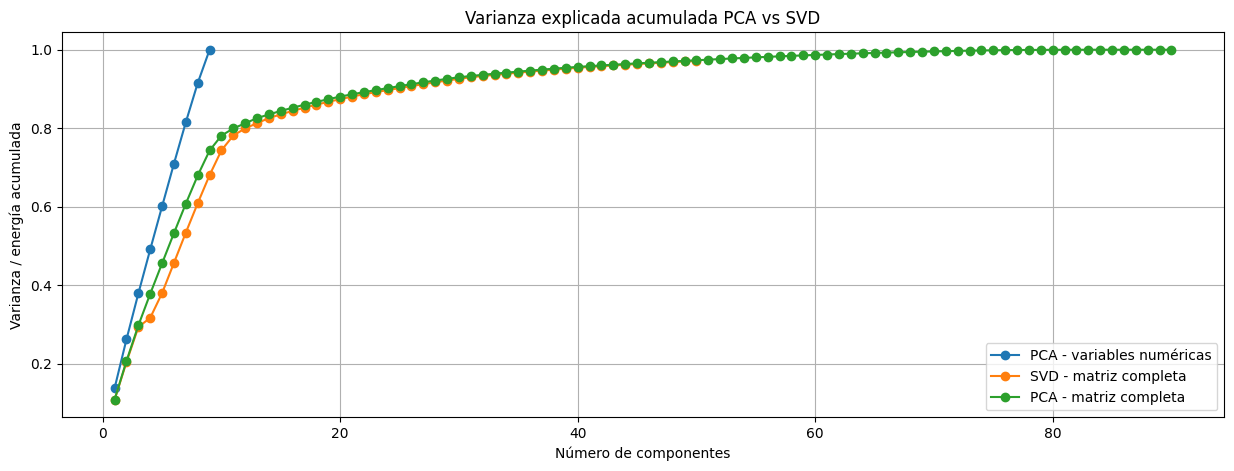

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    range(1, len(pca_cumulative) + 1),
    pca_cumulative,
    marker="o",
    label="PCA - variables numéricas"
)

plt.plot(
    range(1, len(svd_cumulative) + 1),
    svd_cumulative,
    marker="o",
    label="SVD - matriz completa"
)

plt.plot(
     range(1, len(pca_cumulative2) + 1),
     pca_cumulative2,
    marker="o",
    label="PCA - matriz completa"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza / energía acumulada")
plt.title("Varianza explicada acumulada PCA vs SVD")
plt.legend()
plt.grid(True)
plt.show()

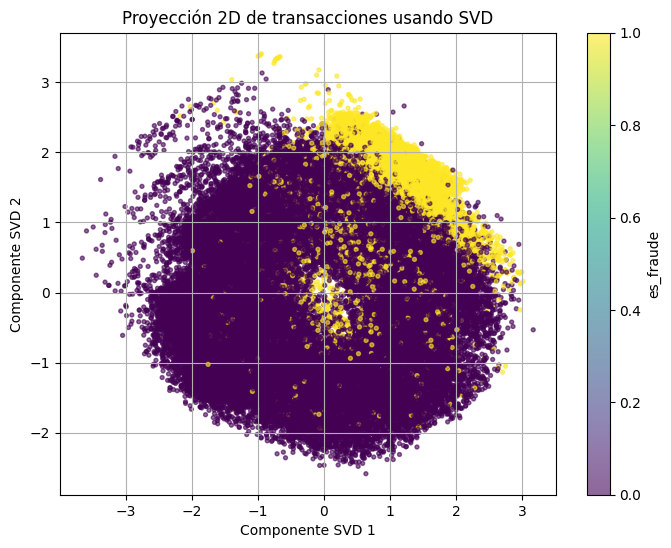

In [21]:
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_svd_2d = svd_2d.fit_transform(X_features)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_svd_2d[:, 0],
    X_svd_2d[:, 1],
    c=y_train,
    s=8,
    alpha=0.6
)

plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.title("Proyección 2D de transacciones usando SVD")
plt.colorbar(scatter, label=target_col)
plt.grid(True)
plt.show()

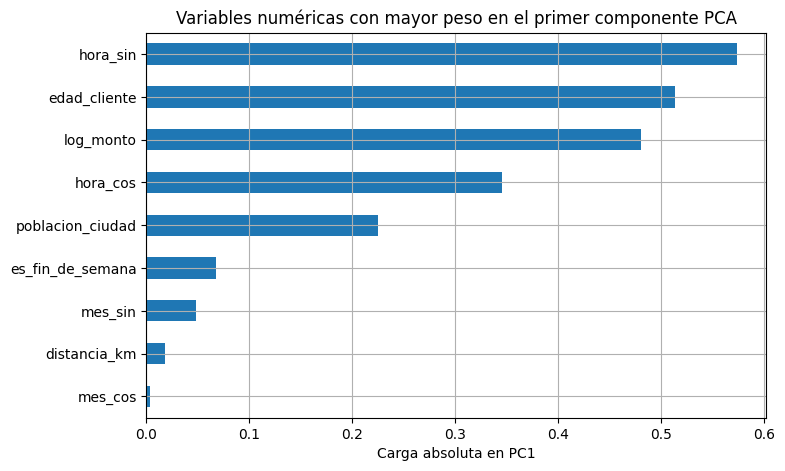

hora_sin           0.574
edad_cliente       0.513
log_monto          0.480
hora_cos           0.345
poblacion_ciudad   0.225
es_fin_de_semana   0.067
mes_sin            0.048
distancia_km       0.018
mes_cos            0.003
dtype: float64

In [22]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2.fit(X_numeric)

loadings_pc1 = pd.Series(
    np.abs(pca_2.components_[0]),
    index=numeric_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

loadings_pc1.head(10).sort_values().plot(kind="barh")

plt.xlabel("Carga absoluta en PC1")
plt.title("Variables numéricas con mayor peso en el primer componente PCA")
plt.grid(True)
plt.show()

display(loadings_pc1.head(10))

In [ ]:
# Guardar X_features y target y_train
from scipy.sparse import save_npz

try:
    save_npz(output_dir / "X_features_week5.npz", X_features)
except Exception:
    try:
        np.save(output_dir / "X_features_week5.npy", X_features)
    except Exception:
        pass

if 'y_train' in globals() or 'y_train' in locals():
    if 'target_col' in globals() or 'target_col' in locals():
        pd.DataFrame({target_col: y_train}).to_csv(output_dir / "y_week5.csv", index=False)
    else:
        raise NameError("target_col no definido. Ejecuta las celdas previas que definen `target_col`.")
else:
    raise NameError("y_train no definido. Ejecuta las celdas previas que crean `y_train`.")

if 'feature_names_df' in globals() or 'feature_names_df' in locals():
    feature_names_df.to_csv(output_dir / "feature_names_week5.csv", index=False)
else:
    print("feature_names_df no definido; no se guardaron los nombres de features.")


In [ ]:
output_dir = project_root / "data" / "week5"
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar matriz completa
if sparse.issparse(X_features):
    save_npz(output_dir / "X_features_week5.npz", X_features)
else:
    np.save(output_dir / "X_features_week5.npy", X_features)

# Guardar target
pd.DataFrame({target_col: y_train}).to_csv(
    output_dir / "y_week5.csv",
    index=False
)

# Guardar nombres de features
feature_names_df.to_csv(
    output_dir / "feature_names_week5.csv",
    index=False
)

# Guardar tabla comparativa
comparison_df.to_csv(
    output_dir / "dimensionality_comparison_week5.csv",
    index=False
)

print("Entregables guardados en:")
print(output_dir.resolve())

Entregables guardados en:
C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\week5


In [24]:
best_pca = comparison_df[comparison_df["metodo"] == "PCA - solo numéricas"].sort_values("componentes").tail(1)
best_svd = comparison_df[comparison_df["metodo"] == "SVD - matriz completa"].sort_values("componentes").tail(1)

pca_componentes = int(best_pca["componentes"].iloc[0])
pca_varianza = best_pca["varianza_o_energia_acumulada"].iloc[0]
pca_error = best_pca["error_reconstruccion_relativo"].iloc[0]

svd_componentes = int(best_svd["componentes"].iloc[0])
svd_energia = best_svd["varianza_o_energia_acumulada"].iloc[0]
svd_error = best_svd["error_reconstruccion_relativo"].iloc[0]

interpretacion = f"""
Interpretación técnica:

Se construyó una matriz de características reproducible a partir de variables numéricas,
categóricas, temporales y textuales. La matriz final X_features tiene {X_features.shape[0]} filas
y {X_features.shape[1]} columnas después de aplicar escalamiento, OneHotEncoding y TF-IDF.

En PCA, usando solo variables numéricas, {pca_componentes} componentes conservaron aproximadamente
{pca_varianza:.2%} de la varianza, con un error relativo de reconstrucción de {pca_error:.4f}.
Esto permite evaluar si las variables numéricas contienen redundancia.

En SVD, usando la matriz completa, {svd_componentes} componentes conservaron aproximadamente
{svd_energia:.2%} de la energía total, con un error relativo de reconstrucción de {svd_error:.4f}.
El SVD fue más adecuado para la matriz completa porque esta incluye variables dispersas generadas
por OneHotEncoding y TF-IDF.

La proyección 2D permitió observar si las transacciones fraudulentas se agrupan o se mezclan con las
no fraudulentas. Si los puntos de fraude aparecen mezclados, significa que la separación no es
linealmente evidente y que se necesitarían modelos más complejos para clasificación.

En general, el feature engineering temporal, geográfico, categórico y textual permitió transformar
la tabla original en una representación más significativa para análisis dimensional.
"""

print(interpretacion)


Interpretación técnica:

Se construyó una matriz de características reproducible a partir de variables numéricas,
categóricas, temporales y textuales. La matriz final X_features tiene 75000 filas
y 91 columnas después de aplicar escalamiento, OneHotEncoding y TF-IDF.

En PCA, usando solo variables numéricas, 9 componentes conservaron aproximadamente
100.00% de la varianza, con un error relativo de reconstrucción de 0.0000.
Esto permite evaluar si las variables numéricas contienen redundancia.

En SVD, usando la matriz completa, 50 componentes conservaron aproximadamente
97.16% de la energía total, con un error relativo de reconstrucción de 0.1621.
El SVD fue más adecuado para la matriz completa porque esta incluye variables dispersas generadas
por OneHotEncoding y TF-IDF.

La proyección 2D permitió observar si las transacciones fraudulentas se agrupan o se mezclan con las
no fraudulentas. Si los puntos de fraude aparecen mezclados, significa que la separación no es
linealmente evident

## Semana 7

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

RANDOM_STATE = 42

print("Variables disponibles para clustering:")
print("X_svd:", X_svd.shape if "X_svd" in globals() else "No existe")
print("X_features:", X_features.shape if "X_features" in globals() else "No existe")
print("df_model:", df_model.shape if "df_model" in globals() else "No existe")

Variables disponibles para clustering:
X_svd: (75000, 50)
X_features: (75000, 91)
df_model: (75000, 27)


In [26]:
N_COMPONENTS = min(23, X_svd.shape[1]) # 23 componentes para mantener la mayor parte de la energía según SVD 0.89

X_cluster = X_svd[:, :N_COMPONENTS]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Matriz usada para clustering:", X_cluster_scaled.shape)
print("Componentes SVD usados:", N_COMPONENTS)

Matriz usada para clustering: (75000, 23)
Componentes SVD usados: 23


In [27]:
k_values = [2, 3, 4, 5, 6, 10,15,20]

kmeans_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    silhouette = silhouette_score(X_cluster_scaled, labels)
    calinski = calinski_harabasz_score(X_cluster_scaled, labels)
    davies = davies_bouldin_score(X_cluster_scaled, labels)
    noise_ratio = np.mean(labels == -1)
    kmeans_results.append({
        "metodo": "K-means",
        "parametros": f"k={k}",
        "n_clusters": k,
        "silhouette": silhouette,
        "inertia": kmeans.inertia_,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies,
        "noise_ratio": noise_ratio,
        "interpretacion_limite": "K-means fuerza a todos los puntos a pertenecer a un cluster."
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df)

,metodo,parametros,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite
0,K-means,k=2,2,0.079,1647177.755,3543.353,3.527,0.000,K-means fuerza a todos los puntos a pertenecer...
1,K-means,k=3,3,0.048,1574833.550,3575.682,3.650,0.000,K-means fuerza a todos los puntos a pertenecer...
2,K-means,k=4,4,0.065,1495852.342,3829.513,2.743,0.000,K-means fuerza a todos los puntos a pertenecer...
3,K-means,k=5,5,0.106,1421280.354,4006.503,2.918,0.000,K-means fuerza a todos los puntos a pertenecer...
4,K-means,k=6,6,0.129,1346281.986,4219.262,2.605,0.000,K-means fuerza a todos los puntos a pertenecer...
5,K-means,k=10,10,0.156,1137328.310,4305.363,2.015,0.000,K-means fuerza a todos los puntos a pertenecer...
6,K-means,k=15,15,0.097,1027950.298,3631.934,1.893,0.000,K-means fuerza a todos los puntos a pertenecer...
7,K-means,k=20,20,0.113,976337.180,3026.066,2.229,0.000,K-means fuerza a todos los puntos a pertenecer...


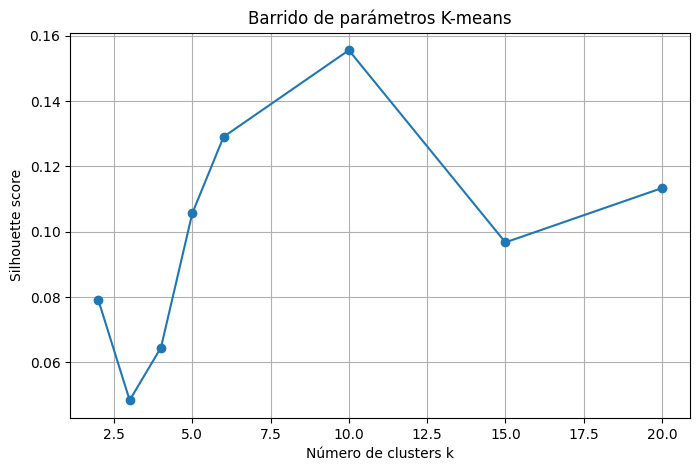

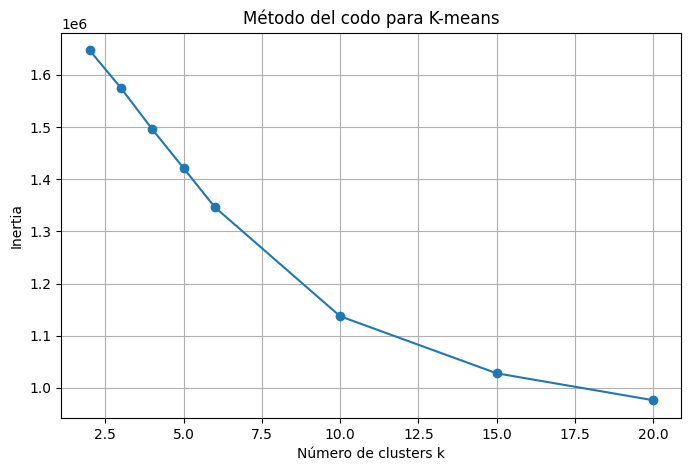

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette score")
plt.title("Barrido de parámetros K-means")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["inertia"],
    marker="o"
)

plt.xlabel("Número de clusters k")
plt.ylabel("Inertia")
plt.title("Método del codo para K-means")
plt.grid(True)
plt.show()

In [29]:
MAX_DBSCAN_ROWS = 5000

if X_cluster_scaled.shape[0] > MAX_DBSCAN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    dbscan_idx = rng.choice(
        X_cluster_scaled.shape[0],
        size=MAX_DBSCAN_ROWS,
        replace=False
    )
    X_dbscan = X_cluster_scaled[dbscan_idx]
    df_dbscan_base = df_model.iloc[dbscan_idx].copy()
else:
    dbscan_idx = np.arange(X_cluster_scaled.shape[0])
    X_dbscan = X_cluster_scaled
    df_dbscan_base = df_model.copy()

print("Matriz usada para DBSCAN:", X_dbscan.shape)

eps_values = [0.5, 0.8, 1.0, 1.3, 1.6, 2.0]
min_samples_values = [5, 10, 20]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_dbscan)
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        noise_ratio = np.mean(labels == -1)
        
        # Silhouette solo es válido si hay más de un cluster real
        if n_clusters >= 2:
            try:
                silhouette = silhouette_score(X_dbscan, labels)
                calinski = calinski_harabasz_score(X_dbscan, labels)
                davies = davies_bouldin_score(X_dbscan, labels)
            except Exception:
                silhouette = np.nan
                calinski = np.nan
                davies = np.nan
        else:
            silhouette = np.nan
            calinski = np.nan
            davies = np.nan
        
        dbscan_results.append({
            "metodo": "DBSCAN",
            "parametros": f"eps={eps}, min_samples={min_samples}",
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "silhouette": silhouette,
            "inertia": np.nan,
            "calinski_harabasz": calinski,
            "davies_bouldin": davies,
            "noise_ratio": noise_ratio,
            "interpretacion_limite": "DBSCAN puede marcar muchos puntos como ruido si la densidad no es adecuada."
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

Matriz usada para DBSCAN: (5000, 23)


,metodo,parametros,eps,min_samples,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite
0,DBSCAN,"eps=0.5, min_samples=5",0.500,5,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
1,DBSCAN,"eps=0.5, min_samples=10",0.500,10,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
2,DBSCAN,"eps=0.5, min_samples=20",0.500,20,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
3,DBSCAN,"eps=0.8, min_samples=5",0.800,5,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
4,DBSCAN,"eps=0.8, min_samples=10",0.800,10,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
5,DBSCAN,"eps=0.8, min_samples=20",0.800,20,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
6,DBSCAN,"eps=1.0, min_samples=5",1.000,5,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
7,DBSCAN,"eps=1.0, min_samples=10",1.000,10,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
8,DBSCAN,"eps=1.0, min_samples=20",1.000,20,0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...
9,DBSCAN,"eps=1.3, min_samples=5",1.300,5,5,-0.216,NaN,4.170,1.469,0.994,DBSCAN puede marcar muchos puntos como ruido s...


In [30]:
validation_table = pd.concat(
    [
        kmeans_results_df,
        dbscan_results_df
    ],
    ignore_index=True
)

validation_table = validation_table.sort_values(
    by=["metodo", "silhouette"],
    ascending=[True, False]
)

display(validation_table)

,metodo,parametros,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite,eps,min_samples
23,DBSCAN,"eps=2.0, min_samples=5",159,-0.212,NaN,8.899,1.542,0.678,DBSCAN puede marcar muchos puntos como ruido s...,2.000,5.000
17,DBSCAN,"eps=1.3, min_samples=5",5,-0.216,NaN,4.170,1.469,0.994,DBSCAN puede marcar muchos puntos como ruido s...,1.300,5.000
24,DBSCAN,"eps=2.0, min_samples=10",13,-0.259,NaN,8.865,1.723,0.963,DBSCAN puede marcar muchos puntos como ruido s...,2.000,10.000
20,DBSCAN,"eps=1.6, min_samples=5",40,-0.313,NaN,5.337,1.425,0.945,DBSCAN puede marcar muchos puntos como ruido s...,1.600,5.000
8,DBSCAN,"eps=0.5, min_samples=5",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.500,5.000
9,DBSCAN,"eps=0.5, min_samples=10",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.500,10.000
10,DBSCAN,"eps=0.5, min_samples=20",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.500,20.000
11,DBSCAN,"eps=0.8, min_samples=5",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.800,5.000
12,DBSCAN,"eps=0.8, min_samples=10",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.800,10.000
13,DBSCAN,"eps=0.8, min_samples=20",0,NaN,NaN,NaN,NaN,1.000,DBSCAN puede marcar muchos puntos como ruido s...,0.800,20.000


In [31]:
best_kmeans_row = kmeans_results_df.sort_values(
    by="silhouette",
    ascending=False
).iloc[0]

best_k = int(best_kmeans_row["n_clusters"])

print("Mejor K-means:")
display(best_kmeans_row)

best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = best_kmeans.fit_predict(X_cluster_scaled)


# Para DBSCAN, elegimos el mejor caso con al menos 2 clusters
# y no demasiado ruido.

valid_dbscan = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 2) &
    (dbscan_results_df["noise_ratio"] < 0.80) &
    (dbscan_results_df["silhouette"].notna())
].copy()

if len(valid_dbscan) > 0:
    best_dbscan_row = valid_dbscan.sort_values(
        by="silhouette",
        ascending=False
    ).iloc[0]
    
    best_eps = float(best_dbscan_row["eps"])
    best_min_samples = int(best_dbscan_row["min_samples"])
    
    print("Mejor DBSCAN:")
    display(best_dbscan_row)
    
    best_dbscan = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )
    
    dbscan_labels = best_dbscan.fit_predict(X_dbscan)

else:
    best_dbscan_row = None
    dbscan_labels = None
    print("No se encontró una configuración válida de DBSCAN con al menos 2 clusters y ruido menor a 80%.")

Mejor K-means:


metodo                                                             K-means
parametros                                                            k=10
n_clusters                                                              10
silhouette                                                           0.156
inertia                                                        1137328.310
calinski_harabasz                                                 4305.363
davies_bouldin                                                       2.015
noise_ratio                                                          0.000
interpretacion_limite    K-means fuerza a todos los puntos a pertenecer...
Name: 5, dtype: object

Mejor DBSCAN:


metodo                                                              DBSCAN
parametros                                          eps=2.0, min_samples=5
eps                                                                  2.000
min_samples                                                              5
n_clusters                                                             159
silhouette                                                          -0.212
inertia                                                                NaN
calinski_harabasz                                                    8.899
davies_bouldin                                                       1.542
noise_ratio                                                          0.678
interpretacion_limite    DBSCAN puede marcar muchos puntos como ruido s...
Name: 15, dtype: object

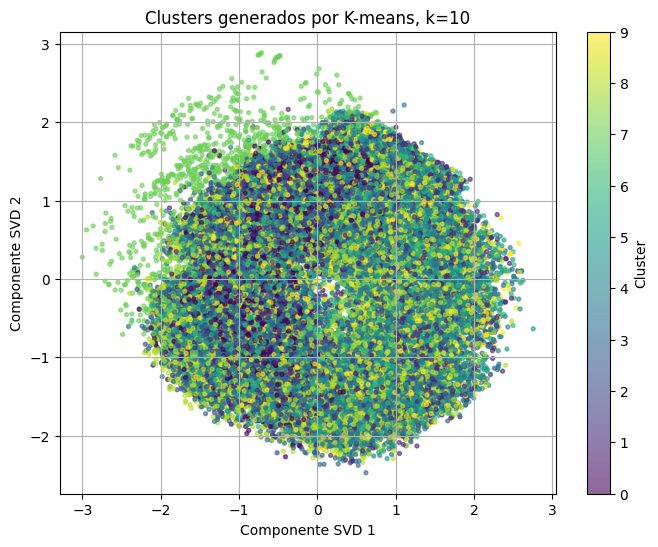

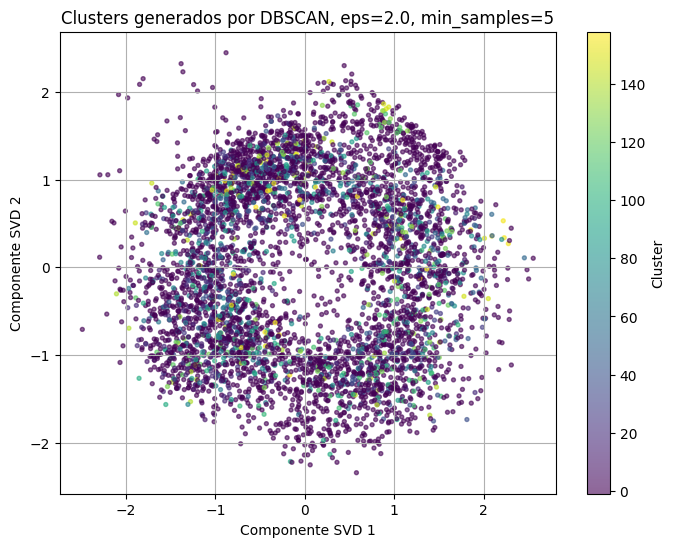

In [32]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_cluster_scaled[:, 0],
    X_cluster_scaled[:, 1],
    c=kmeans_labels,
    s=8,
    alpha=0.6
)

plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.title(f"Clusters generados por K-means, k={best_k}")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


if dbscan_labels is not None:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_dbscan[:, 0],
        X_dbscan[:, 1],
        c=dbscan_labels,
        s=8,
        alpha=0.6
    )

    plt.xlabel("Componente SVD 1")
    plt.ylabel("Componente SVD 2")
    plt.title(f"Clusters generados por DBSCAN, eps={best_eps}, min_samples={best_min_samples}")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True)
    plt.show()

In [33]:
df_cluster_profile = df_model.copy()
df_cluster_profile["cluster_kmeans"] = kmeans_labels

possible_profile_cols = [
    "monto",
    "edad",
    "distancia_cliente_comercio",
    "hora",
    "dia_de_semana_num",
    "mes",
    "es_fin_de_semana",
    "es_fraude"
]

profile_cols = [
    col for col in possible_profile_cols
    if col in df_cluster_profile.columns
]

print("Columnas usadas para perfilar clusters:")
print(profile_cols)

cluster_profile_kmeans = df_cluster_profile.groupby("cluster_kmeans")[profile_cols].agg(
    ["count", "mean", "median", "std"]
)

display(cluster_profile_kmeans)

Columnas usadas para perfilar clusters:
['monto', 'es_fin_de_semana', 'es_fraude']


monto                        es_fin_de_semana               \
                count    mean median     std            count  mean median   
cluster_kmeans                                                               
0                6575  62.515 48.160  57.861             6575 0.347  0.000   
1                7263 136.906 55.870 257.734             7263 0.000  0.000   
2                5970  56.532 45.950  49.314             5970 0.344  0.000   
3                9415 123.934 52.420 275.583             9415 1.000  1.000   
4               11835 114.908 51.620 254.538            11835 0.000  0.000   
5                7398 126.905 52.510 269.257             7398 0.000  0.000   
6                6903 132.716 53.820 245.362             6903 0.000  0.000   
7                2026 123.928 51.555 231.711             2026 0.372  0.000   
8               11501 115.335 51.040 237.309            11501 1.000  1.000   
9                6114 131.847 54.605 250.749             6114 0.000  0.000   

                     es_fraude                     
                 std     count  mean median   std  
cluster_kmeans                                     
0              0.476      6575 0.030  0.000 0.169  
1              0.000      7263 0.136  0.000 0.343  
2              0.475      5970 0.040  0.000 0.195  
3              0.000      9415 0.117  0.000 0.322  
4              0.000     11835 0.093  0.000 0.291  
5              0.000      7398 0.114  0.000 0.318  
6              0.000      6903 0.133  0.000 0.340  
7              0.484      2026 0.108  0.000 0.311  
8              0.000     11501 0.096  0.000 0.295  
9              0.000      6114 0.129  0.000 0.335

In [34]:
summary_rows = []

for cluster_id, group in df_cluster_profile.groupby("cluster_kmeans"):
    
    row = {
        "cluster": cluster_id,
        "cantidad_transacciones": len(group),
        "porcentaje_total": len(group) / len(df_cluster_profile)
    }
    
    if "es_fraude" in group.columns:
        row["tasa_fraude"] = group["es_fraude"].mean()
    
    if "monto" in group.columns:
        row["monto_promedio"] = group["monto"].mean()
        row["monto_mediano"] = group["monto"].median()
    
    if "edad" in group.columns:
        row["edad_promedio"] = group["edad"].mean()
    
    if "distancia_cliente_comercio" in group.columns:
        row["distancia_promedio"] = group["distancia_cliente_comercio"].mean()
    
    if "hora" in group.columns:
        row["hora_promedio"] = group["hora"].mean()
    
    summary_rows.append(row)

cluster_summary_kmeans = pd.DataFrame(summary_rows)

display(cluster_summary_kmeans)

,cluster,cantidad_transacciones,porcentaje_total,tasa_fraude,monto_promedio,monto_mediano
0,0,6575,0.088,0.030,62.515,48.160
1,1,7263,0.097,0.136,136.906,55.870
2,2,5970,0.080,0.040,56.532,45.950
3,3,9415,0.126,0.117,123.934,52.420
4,4,11835,0.158,0.093,114.908,51.620
5,5,7398,0.099,0.114,126.905,52.510
6,6,6903,0.092,0.133,132.716,53.820
7,7,2026,0.027,0.108,123.928,51.555
8,8,11501,0.153,0.096,115.335,51.040
9,9,6114,0.082,0.129,131.847,54.605


In [35]:
possible_categorical_profile_cols = [
    "categoria",
    "genero",
    "estado",
    "ciudad",
    "trabajo"
]

categorical_profile_cols = [
    col for col in possible_categorical_profile_cols
    if col in df_cluster_profile.columns
]

for col in categorical_profile_cols:
    print(f"\nVariable categórica: {col}")
    
    top_categories = (
        df_cluster_profile
        .groupby("cluster_kmeans")[col]
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={col: f"{col}_mas_frecuente"})
    )
    
    display(top_categories)


Variable categórica: genero


,cluster_kmeans,genero_mas_frecuente
0,0,F
1,1,F
2,2,F
3,3,F
4,4,F
5,5,F
6,6,F
7,7,F
8,8,F
9,9,F



Variable categórica: estado


,cluster_kmeans,estado_mas_frecuente
0,0,TX
1,1,NY
2,2,NY
3,3,NY
4,4,TX
5,5,NY
6,6,PA
7,7,TX
8,8,TX
9,9,TX



Variable categórica: ciudad


,cluster_kmeans,ciudad_mas_frecuente
0,0,Utica
1,1,Warren
2,2,Birmingham
3,3,Birmingham
4,4,Utica
5,5,Brandon
6,6,Kensington
7,7,Phoenix
8,8,Cleveland
9,9,Thomas


In [36]:
if dbscan_labels is not None:
    df_dbscan_profile = df_dbscan_base.copy()
    df_dbscan_profile["cluster_dbscan"] = dbscan_labels
    
    dbscan_summary_rows = []
    
    for cluster_id, group in df_dbscan_profile.groupby("cluster_dbscan"):
        
        row = {
            "cluster": cluster_id,
            "cantidad_transacciones": len(group),
            "porcentaje_total": len(group) / len(df_dbscan_profile)
        }
        
        if cluster_id == -1:
            row["tipo"] = "ruido"
        else:
            row["tipo"] = "cluster"
        
        if "es_fraude" in group.columns:
            row["tasa_fraude"] = group["es_fraude"].mean()
        
        if "monto" in group.columns:
            row["monto_promedio"] = group["monto"].mean()
            row["monto_mediano"] = group["monto"].median()
        
        if "edad" in group.columns:
            row["edad_promedio"] = group["edad"].mean()
        
        if "distancia_cliente_comercio" in group.columns:
            row["distancia_promedio"] = group["distancia_cliente_comercio"].mean()
        
        dbscan_summary_rows.append(row)
    
    cluster_summary_dbscan = pd.DataFrame(dbscan_summary_rows)
    
    display(cluster_summary_dbscan)
else:
    print("No se generó perfil DBSCAN porque no hubo una configuración válida.")

,cluster,cantidad_transacciones,porcentaje_total,tipo,tasa_fraude,monto_promedio,monto_mediano
0,-1,3392,0.678,ruido,0.117,131.867,49.550
1,0,11,0.002,cluster,0.091,87.809,85.330
2,1,10,0.002,cluster,0.000,68.230,72.740
3,2,34,0.007,cluster,0.000,95.426,99.720
4,3,8,0.002,cluster,0.125,55.169,45.790
...,...,...,...,...,...,...,...
155,154,5,0.001,cluster,0.000,91.176,95.580
156,155,5,0.001,cluster,0.800,273.130,313.890
157,156,5,0.001,cluster,0.000,93.782,65.920
158,157,4,0.001,cluster,0.250,23.372,17.580


In [37]:
kmeans_best_silhouette = best_kmeans_row["silhouette"]
kmeans_best_inertia = best_kmeans_row["inertia"]

interpretacion_week7 = f"""
Interpretación de Semana 7:

Se aplicaron dos métodos de clustering no supervisado sobre la matriz reducida mediante SVD.

1. K-means:
El mejor resultado de K-means se obtuvo con k={best_k}, alcanzando un silhouette score de {kmeans_best_silhouette:.4f}.
La inercia del modelo fue {kmeans_best_inertia:.4f}. Este resultado indica qué tan compactos se encuentran
los grupos generados. Sin embargo, K-means obliga a que todas las transacciones pertenezcan a algún cluster,
por lo que puede agrupar puntos que realmente no tienen una separación natural clara.

2. DBSCAN:
DBSCAN fue evaluado mediante un barrido de eps y min_samples. Este método permite identificar ruido,
lo cual es útil en un problema de fraude porque algunas transacciones pueden comportarse como anomalías.
No obstante, DBSCAN es sensible a sus parámetros y a la densidad de los datos. Cuando eps es muy bajo,
muchos puntos son clasificados como ruido. Cuando eps es muy alto, varios grupos pueden fusionarse.

3. Perfil de clusters:
El análisis de perfiles permite observar diferencias entre grupos en variables como monto, edad,
distancia entre cliente y comercio, hora de transacción y tasa de fraude. Si algún cluster muestra una
tasa de fraude superior al promedio, puede interpretarse como un segmento de mayor riesgo.

4. Análisis de fallos:
El clustering no separa perfectamente las transacciones fraudulentas porque el fraude es una clase muy
minoritaria y muchas operaciones fraudulentas pueden parecerse a operaciones legítimas. Además, las variables
disponibles no necesariamente generan fronteras claras entre fraude y no fraude. Por ello, el clustering debe
interpretarse como una técnica exploratoria de segmentación y no como un clasificador final de fraude.

5. Límite de interpretación:
Los clusters encontrados no representan necesariamente categorías reales del negocio. Son agrupaciones
matemáticas basadas en similitud entre transacciones. Para una detección formal de fraude, sería necesario
entrenar modelos supervisados y evaluar métricas como recall, precision, F1-score y PR-AUC.
"""

print(interpretacion_week7)


Interpretación de Semana 7:

Se aplicaron dos métodos de clustering no supervisado sobre la matriz reducida mediante SVD.

1. K-means:
El mejor resultado de K-means se obtuvo con k=10, alcanzando un silhouette score de 0.1556.
La inercia del modelo fue 1137328.3099. Este resultado indica qué tan compactos se encuentran
los grupos generados. Sin embargo, K-means obliga a que todas las transacciones pertenezcan a algún cluster,
por lo que puede agrupar puntos que realmente no tienen una separación natural clara.

2. DBSCAN:
DBSCAN fue evaluado mediante un barrido de eps y min_samples. Este método permite identificar ruido,
lo cual es útil en un problema de fraude porque algunas transacciones pueden comportarse como anomalías.
No obstante, DBSCAN es sensible a sus parámetros y a la densidad de los datos. Cuando eps es muy bajo,
muchos puntos son clasificados como ruido. Cuando eps es muy alto, varios grupos pueden fusionarse.

3. Perfil de clusters:
El análisis de perfiles permite observ

In [85]:
from pathlib import Path

output_dir_week7 = project_root / "data" / "week7"
output_dir_week7.mkdir(parents=True, exist_ok=True)

validation_table.to_csv(
    output_dir_week7 / "validation_table_week7.csv",
    index=False
)

cluster_summary_kmeans.to_csv(
    output_dir_week7 / "cluster_profile_kmeans_week7.csv",
    index=False
)

if dbscan_labels is not None:
    cluster_summary_dbscan.to_csv(
        output_dir_week7 / "cluster_profile_dbscan_week7.csv",
        index=False
    )

with open(output_dir_week7 / "interpretacion_week7.txt", "w", encoding="utf-8") as f:
    f.write(interpretacion_week7)

print("Entregables Semana 7 guardados en:")
print(output_dir_week7.resolve())

Entregables Semana 7 guardados en:
C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\week7


### Identificador de fraude (v1)

In [38]:
# SHAPES
print(X_cluster_scaled.shape)
print(y_train.shape)


X_test_svd = svd_model.transform(X_test_features)
X_cluster_test = X_test_svd[:, :N_COMPONENTS]
X_test_cluster_scaled = scaler_cluster.transform(X_cluster_test)

print(X_test_cluster_scaled.shape)
print(y_test.shape)


(75000, 23)
(75000,)
(21000, 23)
(21000,)


In [39]:
#Variables para clasificar con sparse df

#xgb boost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric="logloss",
)

xgb_model.fit(
    X_cluster_scaled,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test_cluster_scaled)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
print("Reporte de clasificación XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("Matriz de confusión XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC XGBoost:", roc_auc_score(y_test, y_pred_xgb))

Reporte de clasificación XGBoost:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18900
           1       0.97      0.62      0.76      2100

    accuracy                           0.96     21000
   macro avg       0.97      0.81      0.87     21000
weighted avg       0.96      0.96      0.96     21000

Matriz de confusión XGBoost:
[[18865    35]
 [  801  1299]]
ROC AUC XGBoost: 0.8083597883597884


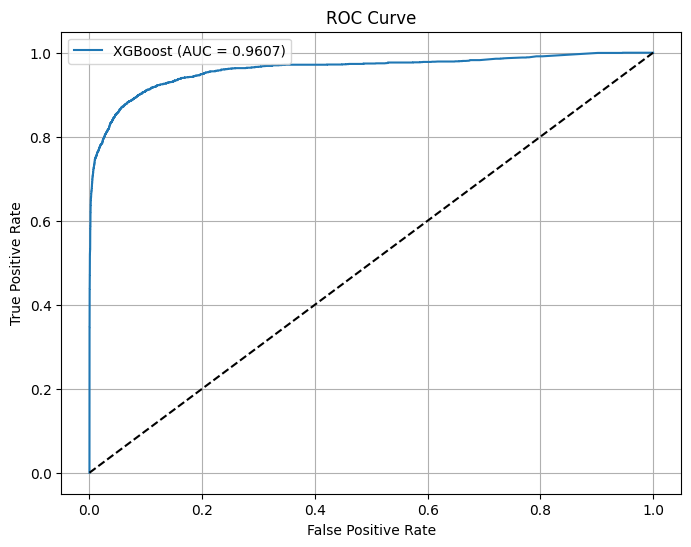

In [40]:
##rocauc graph

from sklearn.metrics import roc_curve, auc
y_prob_xgb = xgb_model.predict_proba(X_test_cluster_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='upper left')
plt.grid()
plt.show()

### Version con optimizacion de hiperparametros

Mejores hiperparámetros encontrados:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Reporte de clasificación XGBoost optimizado:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18900
           1       0.96      0.81      0.88      2100

    accuracy                           0.98     21000
   macro avg       0.97      0.90      0.93     21000
weighted avg       0.98      0.98      0.98     21000

Matriz de confusión XGBoost optimizado:
[[18820    80]
 [  400  1700]]
ROC AUC XGBoost optimizado: 0.9026455026455026


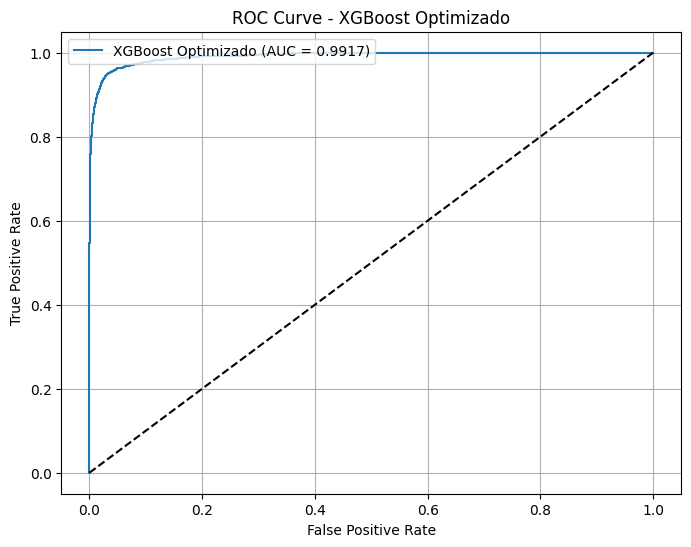

In [41]:
#importamos librerias de optimizacion de hiperparametros
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_cluster_scaled, y_train)
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_cluster_scaled)
print("Reporte de clasificación XGBoost optimizado:")
print(classification_report(y_test, y_pred_best_xgb))
print("Matriz de confusión XGBoost optimizado:")
print(confusion_matrix(y_test, y_pred_best_xgb))
print("ROC AUC XGBoost optimizado:", roc_auc_score(y_test, y_pred_best_xgb))
y_prob_best_xgb = best_xgb.predict_proba(X_test_cluster_scaled)[:, 1]
fpr_best_xgb, tpr_best_xgb, _ = roc_curve(y_test, y_prob_best_xgb)
roc_auc_best_xgb = auc(fpr_best_xgb, tpr_best_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_best_xgb, tpr_best_xgb, label=f'XGBoost Optimizado (AUC = {roc_auc_best_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Optimizado')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Semana 10 -

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

target_name = target_col if "target_col" in globals() else "es_fraude"

candidate_pool = df_model_test.reset_index(drop=True).copy()
y_true_week10 = pd.Series(y_test).reset_index(drop=True).astype(int)

strong_model = best_xgb if "best_xgb" in globals() else xgb_model
strong_system_name = "XGBoost optimizado" if "best_xgb" in globals() else "XGBoost base"

y_score_strong = strong_model.predict_proba(X_test_cluster_scaled)[:, 1]

possible_baseline_cols = [
    "categoria_comercio",
    "estado",
    "genero",
    "periodo_dia"
]

baseline_group_col = None

for col in possible_baseline_cols:
    if col in df_model.columns and col in candidate_pool.columns: # this selects the first available column in the order defined, it will be always return "categoria_comercio"
        baseline_group_col = col
        break

global_fraud_rate = float(pd.Series(y_train).astype(int).mean())

if baseline_group_col is not None:
    risk_table = df_model.groupby(baseline_group_col)[target_name].mean()
    y_score_baseline = candidate_pool[baseline_group_col].map(risk_table).fillna(global_fraud_rate).astype(float).values
else:
    amount_col = "log_monto" if "log_monto" in candidate_pool.columns else "monto"
    if amount_col in candidate_pool.columns:
        amount_values = pd.to_numeric(candidate_pool[amount_col], errors="coerce")
        amount_values = amount_values.fillna(amount_values.median())
        min_value = amount_values.min()
        max_value = amount_values.max()
        y_score_baseline = ((amount_values - min_value) / (max_value - min_value + 1e-9)).values
        baseline_group_col = amount_col
    else:
        y_score_baseline = np.repeat(global_fraud_rate, len(candidate_pool))
        baseline_group_col = "tasa_global"

candidate_pool["fraude_real"] = y_true_week10.values
candidate_pool["score_baseline"] = y_score_baseline
candidate_pool["score_modelo_fuerte"] = y_score_strong
candidate_pool["rank_baseline"] = candidate_pool["score_baseline"].rank(ascending=False, method="first").astype(int)
candidate_pool["rank_modelo_fuerte"] = candidate_pool["score_modelo_fuerte"].rank(ascending=False, method="first").astype(int)

print("Candidate pool offline:", candidate_pool.shape)
print("Target:", target_name)
print("Baseline usado:", baseline_group_col)
print("Sistema fuerte:", strong_system_name)
print("Tasa real de fraude en candidate pool:", y_true_week10.mean())

Candidate pool offline: (21000, 37)
Target: es_fraude
Baseline usado: categoria_comercio
Sistema fuerte: XGBoost optimizado
Tasa real de fraude en candidate pool: 0.1


In [43]:
def safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def safe_average_precision(y_true, y_score):
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def evaluate_system(system_name, y_true, y_score, threshold=0.5):
    y_pred = (pd.Series(y_score).astype(float) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "sistema": system_name,
        "tipo": "baseline" if system_name == "Baseline historico" else "modelo_fuerte",
        "threshold": threshold,
        "roc_auc": safe_roc_auc(y_true, y_score),
        "pr_auc": safe_average_precision(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

evaluation_report = pd.DataFrame([
    evaluate_system("Baseline historico", y_true_week10, y_score_baseline),
    evaluate_system(strong_system_name, y_true_week10, y_score_strong)
])

display(evaluation_report)

print("Reporte de clasificacion del modelo fuerte:")
print(classification_report(
    y_true_week10,
    (pd.Series(y_score_strong) >= 0.5).astype(int),
    zero_division=0
))

,sistema,tipo,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
0,Baseline historico,baseline,0.500,0.726,0.208,0.000,0.000,0.000,18900,0,2100,0
1,XGBoost optimizado,modelo_fuerte,0.500,0.992,0.958,0.955,0.810,0.876,18820,80,400,1700


Reporte de clasificacion del modelo fuerte:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18900
           1       0.96      0.81      0.88      2100

    accuracy                           0.98     21000
   macro avg       0.97      0.90      0.93     21000
weighted avg       0.98      0.98      0.98     21000



In [44]:
def topk_metrics(system_name, y_true, y_score, frac):
    evaluation_df = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True).astype(int),
        "score": pd.Series(y_score).reset_index(drop=True).astype(float)
    })

    k = max(1, int(len(evaluation_df) * frac))
    top_k = evaluation_df.sort_values("score", ascending=False).head(k)

    total_frauds = evaluation_df["y_true"].sum()
    frauds_in_top_k = top_k["y_true"].sum()
    base_rate = evaluation_df["y_true"].mean()
    precision_at_k = frauds_in_top_k / k
    recall_at_k = frauds_in_top_k / total_frauds if total_frauds > 0 else np.nan
    lift_at_k = precision_at_k / base_rate if base_rate > 0 else np.nan

    return {
        "sistema": system_name,
        "fraccion_pool": f"{int(frac * 100)}%",
        "k_transacciones_revisadas": k,
        "fraudes_en_top_k": int(frauds_in_top_k),
        "precision_at_k": precision_at_k,
        "recall_at_k": recall_at_k,
        "lift_at_k": lift_at_k
    }

topk_fracciones = [0.01, 0.05, 0.10]

topk_report = pd.DataFrame(
    [topk_metrics("Baseline historico", y_true_week10, y_score_baseline, frac) for frac in topk_fracciones] +
    [topk_metrics(strong_system_name, y_true_week10, y_score_strong, frac) for frac in topk_fracciones]
)

display(topk_report)

,sistema,fraccion_pool,k_transacciones_revisadas,fraudes_en_top_k,precision_at_k,recall_at_k,lift_at_k
0,Baseline historico,1%,210,70,0.333,0.033,3.333
1,Baseline historico,5%,1050,273,0.260,0.130,2.600
2,Baseline historico,10%,2100,540,0.257,0.257,2.571
3,XGBoost optimizado,1%,210,210,1.000,0.100,10.000
4,XGBoost optimizado,5%,1050,1049,0.999,0.500,9.990
5,XGBoost optimizado,10%,2100,1870,0.890,0.890,8.905


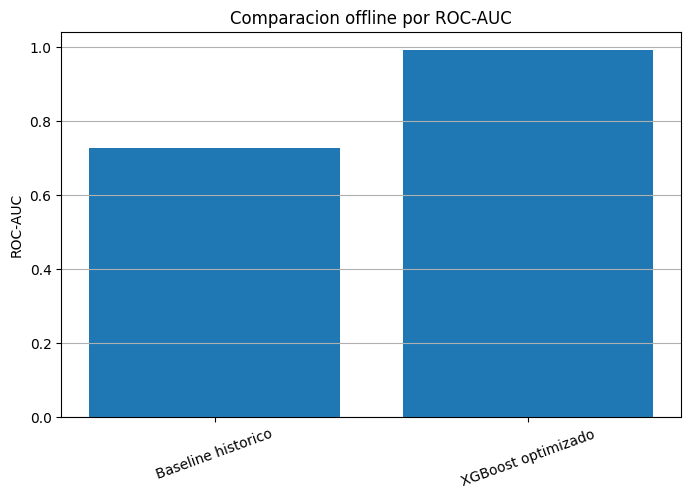

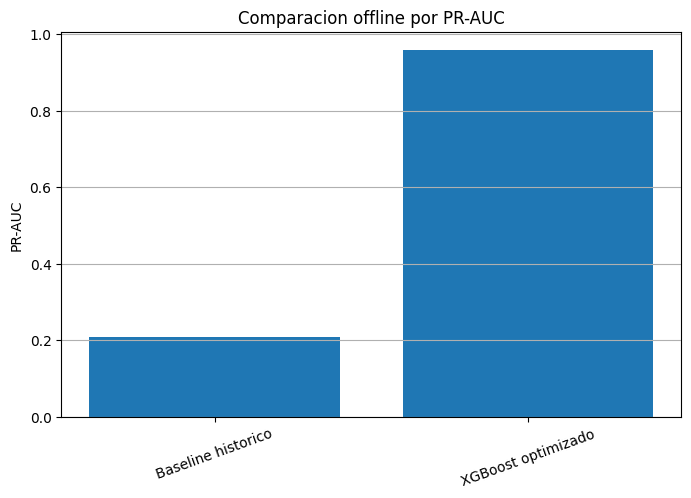

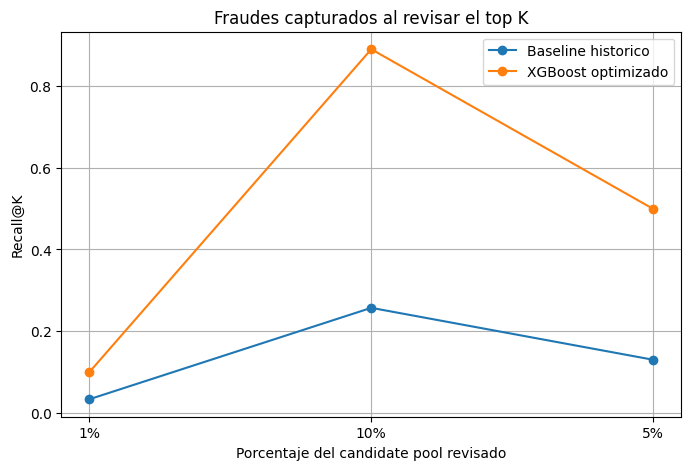

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(evaluation_report["sistema"], evaluation_report["roc_auc"])
plt.ylabel("ROC-AUC")
plt.title("Comparacion offline por ROC-AUC")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(evaluation_report["sistema"], evaluation_report["pr_auc"])
plt.ylabel("PR-AUC")
plt.title("Comparacion offline por PR-AUC")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

topk_pivot = topk_report.pivot(index="fraccion_pool", columns="sistema", values="recall_at_k")

plt.figure(figsize=(8, 5))
for col in topk_pivot.columns:
    plt.plot(topk_pivot.index, topk_pivot[col], marker="o", label=col)

plt.xlabel("Porcentaje del candidate pool revisado")
plt.ylabel("Recall@K")
plt.title("Fraudes capturados al revisar el top K")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
business_cols = [
    "fecha_hora_transaccion",
    "categoria_comercio",
    "monto",
    "log_monto",
    "ciudad",
    "estado",
    "genero",
    "edad_cliente",
    "distancia_km",
    "comercio",
    "ocupacion"
]

business_cols = [col for col in business_cols if col in candidate_pool.columns]

display_cols = [
    "fraude_real",
    "score_modelo_fuerte",
    "rank_modelo_fuerte",
    "score_baseline",
    "rank_baseline"
] + business_cols

casos_fraude_bien_priorizados = (
    candidate_pool[candidate_pool["fraude_real"] == 1]
    .sort_values("score_modelo_fuerte", ascending=False)
    .head(10)
)

casos_no_fraude_bien_descartados = (
    candidate_pool[candidate_pool["fraude_real"] == 0]
    .sort_values("score_modelo_fuerte", ascending=True)
    .head(10)
)

fallos_fraude_no_priorizado = (
    candidate_pool[candidate_pool["fraude_real"] == 1]
    .sort_values("score_modelo_fuerte", ascending=True)
    .head(10)
)

fallos_no_fraude_sobrepriorizado = (
    candidate_pool[candidate_pool["fraude_real"] == 0]
    .sort_values("score_modelo_fuerte", ascending=False)
    .head(10)
)

print("Casos fuertes: fraudes correctamente priorizados")
display(casos_fraude_bien_priorizados[display_cols])

print("Casos fuertes: no fraudes correctamente descartados")
display(casos_no_fraude_bien_descartados[display_cols])

print("Fallos: fraudes con bajo score")
display(fallos_fraude_no_priorizado[display_cols])

print("Fallos: no fraudes con alto score")
display(fallos_no_fraude_sobrepriorizado[display_cols])

Casos fuertes: fraudes correctamente priorizados


,fraude_real,score_modelo_fuerte,rank_modelo_fuerte,score_baseline,rank_baseline,fecha_hora_transaccion,categoria_comercio,monto,log_monto,ciudad,estado,genero,edad_cliente,distancia_km,comercio,ocupacion
14827,1,1.000,1,0.219,2749,2020-10-10 22:47:11,misc_net,846.930,6.743,Varnell,GA,M,76,19.971,fraud_Lebsack and Sons,Pensions consultant
9841,1,1.000,2,0.082,8114,2020-06-24 03:33:40,gas_transport,7.820,2.177,Springville,NY,M,61,106.901,fraud_Huels-Hahn,"Scientist, research (maths)"
18119,1,0.999,3,0.219,2927,2020-10-17 22:01:35,misc_net,793.610,6.678,Hartford,AL,M,74,39.721,fraud_Koelpin and Sons,Jewellery designer
8335,1,0.999,4,0.219,2375,2020-10-17 22:57:27,misc_net,856.300,6.754,Hartford,AL,M,74,104.682,"fraud_Hayes, Marquardt and Dibbert",Jewellery designer
7372,1,0.999,5,0.216,3877,2020-12-08 03:01:53,grocery_pos,315.250,5.757,Moorhead,MS,M,21,91.397,fraud_Murray-Smitham,Chartered public finance accountant
7615,1,0.999,6,0.082,7901,2020-12-17 02:37:31,gas_transport,7.050,2.086,Leetsdale,PA,M,34,95.228,"fraud_Jenkins, Hauck and Friesen","Administrator, education"
19570,1,0.999,7,0.219,3013,2020-12-06 23:42:00,misc_net,905.630,6.810,Greenbush,VA,M,71,82.331,fraud_Mante Group,Psychiatrist
11323,1,0.999,8,0.219,2539,2020-10-17 22:15:31,misc_net,684.590,6.530,Hartford,AL,M,74,94.804,"fraud_Kerluke, Considine and Macejkovic",Jewellery designer
12524,1,0.999,9,0.082,8357,2020-08-05 02:21:46,gas_transport,7.990,2.196,Grand Bay,AL,M,72,114.894,fraud_Mraz-Herzog,Armed forces logistics/support/administrative ...
4283,1,0.999,10,0.255,402,2020-09-05 22:58:53,shopping_net,1044.980,6.953,Brinson,GA,M,84,30.749,fraud_Medhurst PLC,"Engineer, broadcasting (operations)"


Casos fuertes: no fraudes correctamente descartados


,fraude_real,score_modelo_fuerte,rank_modelo_fuerte,score_baseline,rank_baseline,fecha_hora_transaccion,categoria_comercio,monto,log_monto,ciudad,estado,genero,edad_cliente,distancia_km,comercio,ocupacion
12076,0,0.000,21000,0.255,1122,2020-08-28 14:52:19,shopping_net,1.220,0.798,Joliet,IL,F,28,75.506,"fraud_Kihn, Abernathy and Douglas","Teacher, secondary school"
4341,0,0.000,20999,0.216,3543,2020-07-27 03:03:51,grocery_pos,55.680,4.037,Grant,AL,M,48,90.261,"fraud_Osinski, Ledner and Leuschke",Curator
16960,0,0.000,20998,0.255,1568,2020-11-24 13:43:49,shopping_net,1.110,0.747,Wauchula,FL,M,27,100.865,"fraud_Reichert, Rowe and Mraz",Teaching laboratory technician
6441,0,0.000,20997,0.216,3778,2020-08-03 01:24:36,grocery_pos,49.810,3.928,Southfield,MI,M,45,92.910,fraud_Wolf Inc,"Engineer, automotive"
9101,0,0.000,20996,0.255,837,2020-12-08 15:28:31,shopping_net,1.240,0.806,Haw River,NC,M,36,51.540,fraud_Fisher Inc,Paramedic
1427,0,0.000,20995,0.255,143,2020-08-21 14:44:47,shopping_net,4.610,1.725,Hinesburg,VT,F,22,52.039,fraud_Volkman-Predovic,Claims inspector/assessor
16911,0,0.000,20994,0.255,1561,2020-11-20 15:37:25,shopping_net,1.460,0.900,Bristol,PA,F,35,51.026,"fraud_Little, Gutmann and Lynch","Administrator, charities/voluntary organisations"
13505,0,0.000,20993,0.255,1245,2020-12-22 16:53:28,shopping_net,1.080,0.732,Warren,MI,M,40,65.617,fraud_Rempel Inc,"Doctor, hospital"
10764,0,0.000,20992,0.255,1001,2020-11-06 15:12:43,shopping_net,2.680,1.303,Wauchula,FL,M,27,77.583,fraud_Boyer PLC,Teaching laboratory technician
10851,0,0.000,20991,0.255,1011,2020-12-05 13:17:24,shopping_net,3.490,1.502,Topeka,KS,F,15,100.835,fraud_Jast Ltd,Secondary school teacher


Fallos: fraudes con bajo score


,fraude_real,score_modelo_fuerte,rank_modelo_fuerte,score_baseline,rank_baseline,fecha_hora_transaccion,categoria_comercio,monto,log_monto,ciudad,estado,genero,edad_cliente,distancia_km,comercio,ocupacion
3284,1,0.001,11700,0.031,16758,2020-10-22 20:34:29,food_dining,140.770,4.954,Shrewsbury,MA,M,45,23.828,"fraud_Schneider, Hayes and Nikolaus",English as a second language teacher
16688,1,0.001,10768,0.031,17647,2020-07-18 15:42:12,food_dining,110.120,4.711,Moravian Falls,NC,F,32,99.912,fraud_Kihn-Fritsch,"Psychologist, counselling"
16420,1,0.002,9299,0.052,11786,2020-10-11 12:18:53,travel,1.780,1.022,Llano,NM,F,58,96.749,fraud_Tromp Group,Architectural technologist
7090,1,0.003,8801,0.039,15343,2020-08-20 14:14:32,kids_pets,20.970,3.090,Plymouth,CT,F,47,50.184,fraud_Nolan-Williamson,Herpetologist
9491,1,0.003,8790,0.052,11568,2020-10-17 18:20:12,travel,9.940,2.392,Veedersburg,IN,F,60,52.466,fraud_Thiel Ltd,"Development worker, community"
18459,1,0.003,8632,0.044,14594,2020-11-07 18:01:06,personal_care,52.120,3.973,Cascade Locks,OR,F,84,67.230,fraud_Watsica LLC,Barrister
5282,1,0.003,8593,0.029,18425,2020-10-12 18:55:10,home,195.690,5.282,Arcadia,SC,F,31,35.586,fraud_Lynch-Wisozk,Animal technologist
14126,1,0.003,8031,0.031,17473,2020-08-07 11:28:54,food_dining,138.220,4.936,Leonard,TX,F,43,98.749,"fraud_Hagenes, Kohler and Hoppe",Sub
20524,1,0.004,7894,0.031,17917,2020-10-05 16:13:03,food_dining,149.530,5.014,Cisco,IL,F,60,68.682,fraud_Daugherty-Thompson,Landscape architect
15350,1,0.004,7791,0.052,11758,2020-08-28 17:15:33,travel,9.890,2.388,Annapolis,MD,F,77,56.089,fraud_Kovacek Ltd,"Accountant, chartered certified"


Fallos: no fraudes con alto score


,fraude_real,score_modelo_fuerte,rank_modelo_fuerte,score_baseline,rank_baseline,fecha_hora_transaccion,categoria_comercio,monto,log_monto,ciudad,estado,genero,edad_cliente,distancia_km,comercio,ocupacion
18807,0,0.995,427,0.255,1723,2020-11-06 22:52:25,shopping_net,958.830,6.867,Edmond,OK,M,27,89.560,fraud_Gerlach Inc,Media buyer
12927,0,0.969,1151,0.219,2631,2020-12-15 05:29:14,misc_net,1127.310,7.028,Grimesland,NC,F,27,87.979,fraud_Miller-Harris,Manufacturing systems engineer
16922,0,0.965,1183,0.255,1563,2020-07-08 23:29:14,shopping_net,608.210,6.412,Houston,TX,F,36,102.213,fraud_Boyer-Reichert,Animator
19092,0,0.961,1217,0.255,1746,2020-11-04 21:45:39,shopping_net,770.890,6.649,Fayetteville,NC,M,27,116.017,fraud_Volkman-Predovic,"Scientist, research (maths)"
6469,0,0.905,1413,0.124,5936,2020-07-03 20:34:45,shopping_pos,1435.640,7.270,Saint Petersburg,FL,M,31,80.149,fraud_Pouros-Haag,"Engineer, land"
6031,0,0.903,1417,0.255,570,2020-11-23 00:43:22,shopping_net,979.790,6.888,East Andover,ME,F,50,118.449,fraud_Stamm-Witting,Animal nutritionist
3013,0,0.902,1421,0.216,3416,2020-12-28 02:12:14,grocery_pos,181.240,5.205,Port Ewen,NY,M,54,126.343,fraud_Kiehn-Emmerich,Heritage manager
5576,0,0.898,1433,0.255,526,2020-12-21 23:19:53,shopping_net,431.710,6.070,New York City,NY,F,39,96.606,fraud_Mohr-Bayer,Herbalist
8957,0,0.893,1441,0.255,826,2020-12-06 01:51:56,shopping_net,890.800,6.793,Noonan,ND,F,52,60.375,fraud_Terry-Huel,Industrial/product designer
550,0,0.893,1443,0.255,54,2020-09-24 15:14:18,shopping_net,3678.390,8.211,West Harrison,NY,M,43,105.513,fraud_Fisher Inc,Lexicographer


In [47]:
if "project_root" in globals():
    output_dir_week10 = Path(project_root) / "data" / "week10"
else:
    output_dir_week10 = Path.cwd() / "data" / "week10"

output_dir_week10.mkdir(parents=True, exist_ok=True)

evaluation_report.to_csv(
    output_dir_week10 / "offline_evaluation_report_week10.csv",
    index=False
)

topk_report.to_csv(
    output_dir_week10 / "topk_ranking_report_week10.csv",
    index=False
)

candidate_pool[display_cols].to_csv(
    output_dir_week10 / "candidate_pool_ranked_week10.csv",
    index=False
)

best_strong_row = evaluation_report[evaluation_report["sistema"] == strong_system_name].iloc[0]
best_baseline_row = evaluation_report[evaluation_report["sistema"] == "Baseline historico"].iloc[0]

strong_top5 = topk_report[
    (topk_report["sistema"] == strong_system_name) &
    (topk_report["fraccion_pool"] == "5%")
].iloc[0]

baseline_top5 = topk_report[
    (topk_report["sistema"] == "Baseline historico") &
    (topk_report["fraccion_pool"] == "5%")
].iloc[0]

interpretacion_week10 = f"""
Interpretacion Semana 10:

1) Tipo de proyecto:
Este proyecto se interpreta como un motor de prediccion y ranking de riesgo de fraude. No es un sistema de recomendacion tradicional, porque no recomienda productos ni contenidos a un usuario. El objetivo es asignar un score de riesgo a cada transaccion y ordenar el candidate pool para decidir que operaciones deben revisarse primero.

2) Candidate pool:
El candidate pool offline esta formado por {len(candidate_pool)} transacciones del conjunto df_model_test. Todas las alternativas se evaluan sobre el mismo conjunto, con la misma variable real de fraude y con la misma definicion de transaccion candidata. Esto permite comparar el baseline contra el modelo fuerte sin cambiar la poblacion evaluada.

3) Baseline:
El baseline usado es historico y simple. Se calcula un score de riesgo usando la tasa historica de fraude por {baseline_group_col}, con respaldo de la tasa global si aparece una categoria nueva. Este baseline representa una regla sencilla de negocio: priorizar grupos que historicamente muestran mayor tasa de fraude.

4) Sistema fuerte:
El sistema fuerte es {strong_system_name}. Este modelo usa la representacion reducida y escalada construida en las semanas anteriores para estimar la probabilidad de fraude. Luego esa probabilidad se usa como score de ranking.

5) Evaluacion offline:
El baseline obtuvo ROC-AUC={best_baseline_row["roc_auc"]:.4f} y PR-AUC={best_baseline_row["pr_auc"]:.4f}. El sistema fuerte obtuvo ROC-AUC={best_strong_row["roc_auc"]:.4f} y PR-AUC={best_strong_row["pr_auc"]:.4f}. En un problema de fraude, PR-AUC y Recall@K son especialmente importantes porque la clase positiva es minoritaria.

6) Ranking:
Al revisar el top 5% del candidate pool, el baseline captura un Recall@K={baseline_top5["recall_at_k"]:.4f}, mientras que el sistema fuerte captura un Recall@K={strong_top5["recall_at_k"]:.4f}. Esto muestra que el modelo puede usarse como herramienta de priorizacion operativa, ya que ordena primero las transacciones con mayor riesgo esperado.

7) Analisis de errores:
Los casos fuertes son los fraudes con alto score y los no fraudes con score bajo. Los fallos principales son fraudes con score bajo, que representan riesgo no detectado, y no fraudes con score alto, que generan revision innecesaria. Estos errores son esperables porque algunas operaciones fraudulentas pueden parecer normales y algunas operaciones legitimas pueden compartir patrones con fraude.

8) Segmentacion:
La segmentacion de Semana 7 puede alimentar la interpretacion del ranking, porque permite describir grupos de comportamiento. Sin embargo, el entregable final no se presenta como un sistema hibrido completo, ya que el ranking principal se basa en el score supervisado del modelo fuerte.
"""

print(interpretacion_week10)

with open(output_dir_week10 / "interpretacion_week10.txt", "w", encoding="utf-8") as f:
    f.write(interpretacion_week10)

print("Entregables Semana 10 guardados en:")
print(output_dir_week10.resolve())


Interpretacion Semana 10:

1) Tipo de proyecto:
Este proyecto se interpreta como un motor de prediccion y ranking de riesgo de fraude. No es un sistema de recomendacion tradicional, porque no recomienda productos ni contenidos a un usuario. El objetivo es asignar un score de riesgo a cada transaccion y ordenar el candidate pool para decidir que operaciones deben revisarse primero.

2) Candidate pool:
El candidate pool offline esta formado por 21000 transacciones del conjunto df_model_test. Todas las alternativas se evaluan sobre el mismo conjunto, con la misma variable real de fraude y con la misma definicion de transaccion candidata. Esto permite comparar el baseline contra el modelo fuerte sin cambiar la poblacion evaluada.

3) Baseline:
El baseline usado es historico y simple. Se calcula un score de riesgo usando la tasa historica de fraude por categoria_comercio, con respaldo de la tasa global si aparece una categoria nueva. Este baseline representa una regla sencilla de negocio: 

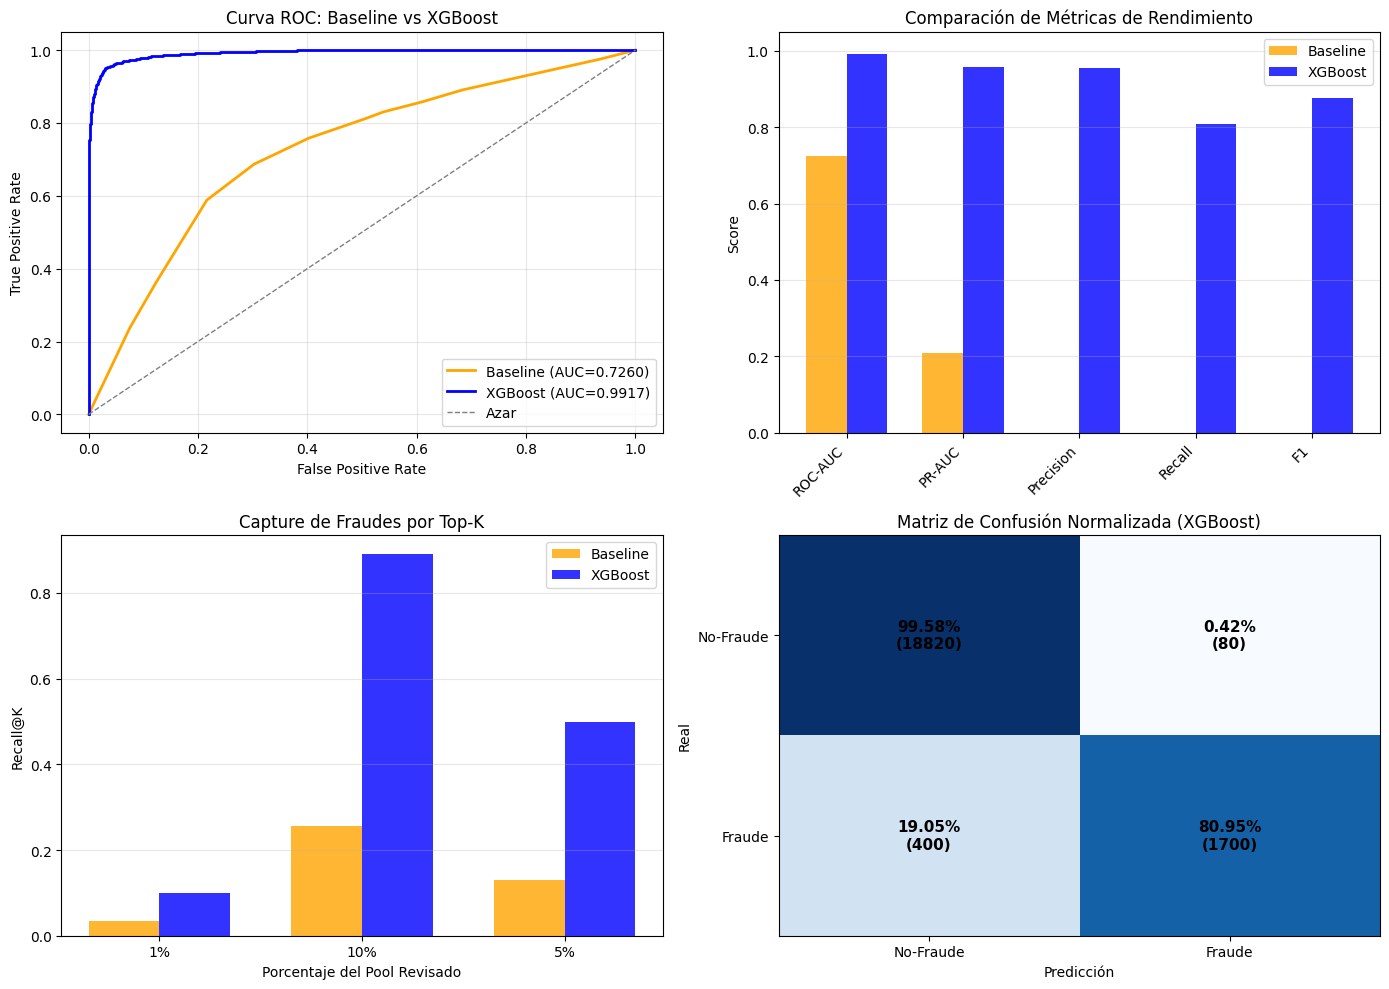

Gráfico de análisis completo guardado.


In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Calcular curvas ROC
fpr_baseline, tpr_baseline, _ = roc_curve(y_true_week10, y_score_baseline)
fpr_xgb, tpr_xgb, _ = roc_curve(y_true_week10, y_score_strong)

roc_auc_baseline = auc(fpr_baseline, tpr_baseline)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Figura 1: Curva ROC Completa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curves
ax = axes[0, 0]
ax.plot(fpr_baseline, tpr_baseline, color='orange', lw=2, label=f'Baseline (AUC={roc_auc_baseline:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost (AUC={roc_auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC: Baseline vs XGBoost')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Métricas de Rendimiento
ax = axes[0, 1]
metrics_names = ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1']
baseline_metrics = [
    best_baseline_row["roc_auc"],
    best_baseline_row["pr_auc"],
    best_baseline_row["precision"],
    best_baseline_row["recall"],
    best_baseline_row["f1"]
]
xgb_metrics = [
    best_strong_row["roc_auc"],
    best_strong_row["pr_auc"],
    best_strong_row["precision"],
    best_strong_row["recall"],
    best_strong_row["f1"]
]

x = np.arange(len(metrics_names))
width = 0.35
ax.bar(x - width/2, baseline_metrics, width, label='Baseline', color='orange', alpha=0.8)
ax.bar(x + width/2, xgb_metrics, width, label='XGBoost', color='blue', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas de Rendimiento')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Recall@K
ax = axes[1, 0]
topk_pivot = topk_report.pivot(index='fraccion_pool', columns='sistema', values='recall_at_k')
x_pos = np.arange(len(topk_pivot.index))
width = 0.35
ax.bar(x_pos - width/2, topk_pivot['Baseline historico'].values, width, label='Baseline', color='orange', alpha=0.8)
ax.bar(x_pos + width/2, topk_pivot[strong_system_name].values, width, label='XGBoost', color='blue', alpha=0.8)
ax.set_xlabel('Porcentaje del Pool Revisado')
ax.set_ylabel('Recall@K')
ax.set_title('Capture de Fraudes por Top-K')
ax.set_xticks(x_pos)
ax.set_xticklabels(topk_pivot.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Matriz de Confusión Normalizada
ax = axes[1, 1]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_week10, (pd.Series(y_score_strong) >= 0.5).astype(int))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión Normalizada (XGBoost)')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No-Fraude', 'Fraude'])
ax.set_yticklabels(['No-Fraude', 'Fraude'])

# Agregar números
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{cm_normalized[i, j]:.2%}\n({cm[i, j]})',
                      ha="center", va="center", color="black", fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(output_dir_week10 / "analisis_rendimiento_completo.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de análisis completo guardado.")

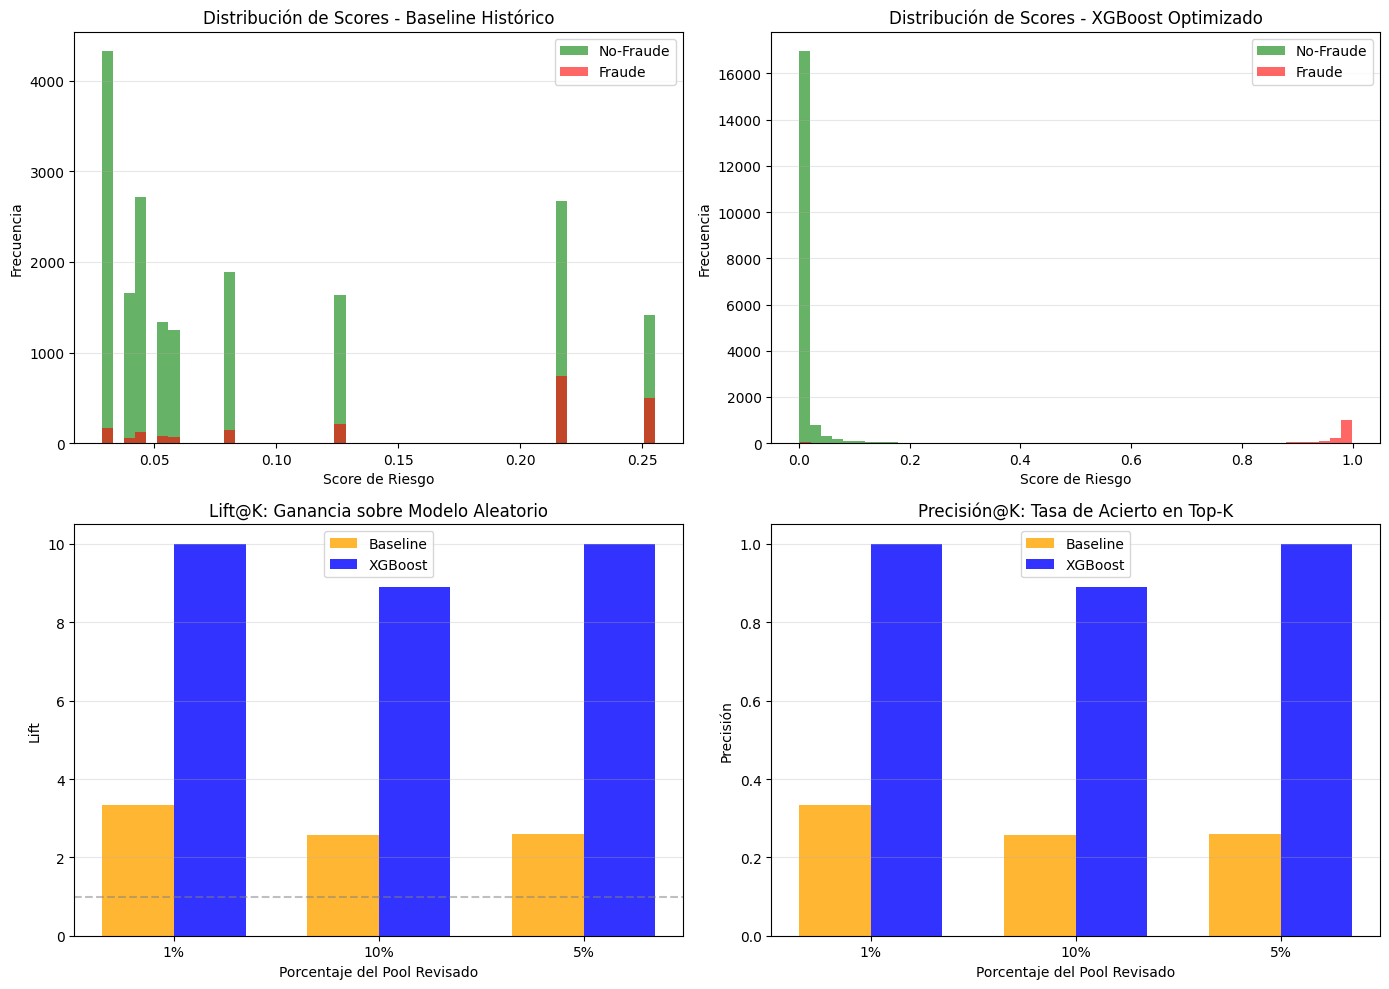

Gráficos de distribución y métricas Top-K guardados.


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de Scores Baseline
ax = axes[0, 0]
ax.hist(y_score_baseline[y_true_week10 == 0], bins=50, alpha=0.6, label='No-Fraude', color='green')
ax.hist(y_score_baseline[y_true_week10 == 1], bins=50, alpha=0.6, label='Fraude', color='red')
ax.set_xlabel('Score de Riesgo')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Scores - Baseline Histórico')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Distribución de Scores XGBoost
ax = axes[0, 1]
ax.hist(y_score_strong[y_true_week10 == 0], bins=50, alpha=0.6, label='No-Fraude', color='green')
ax.hist(y_score_strong[y_true_week10 == 1], bins=50, alpha=0.6, label='Fraude', color='red')
ax.set_xlabel('Score de Riesgo')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Scores - XGBoost Optimizado')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Lift@K
ax = axes[1, 0]
lift_data = topk_report.pivot(index='fraccion_pool', columns='sistema', values='lift_at_k')
x_pos = np.arange(len(lift_data.index))
width = 0.35
ax.bar(x_pos - width/2, lift_data['Baseline historico'].values, width, label='Baseline', color='orange', alpha=0.8)
ax.bar(x_pos + width/2, lift_data[strong_system_name].values, width, label='XGBoost', color='blue', alpha=0.8)
ax.set_xlabel('Porcentaje del Pool Revisado')
ax.set_ylabel('Lift')
ax.set_title('Lift@K: Ganancia sobre Modelo Aleatorio')
ax.set_xticks(x_pos)
ax.set_xticklabels(lift_data.index)
ax.legend()
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline Aleatorio')
ax.grid(axis='y', alpha=0.3)

# Precisión@K
ax = axes[1, 1]
precision_data = topk_report.pivot(index='fraccion_pool', columns='sistema', values='precision_at_k')
x_pos = np.arange(len(precision_data.index))
ax.bar(x_pos - width/2, precision_data['Baseline historico'].values, width, label='Baseline', color='orange', alpha=0.8)
ax.bar(x_pos + width/2, precision_data[strong_system_name].values, width, label='XGBoost', color='blue', alpha=0.8)
ax.set_xlabel('Porcentaje del Pool Revisado')
ax.set_ylabel('Precisión')
ax.set_title('Precisión@K: Tasa de Acierto en Top-K')
ax.set_xticks(x_pos)
ax.set_xticklabels(precision_data.index)
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir_week10 / "distribucion_scores_y_metricas_topk.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos de distribución y métricas Top-K guardados.")

### Prueba con clusters como feature

In [61]:
print("\n" + "="*70)
print("Prueba: Incluir Cluster Labels como Feature Explícito")
print("="*70 + "\n")

# ============================================================================
# PASO 1: Obtener los cluster labels óptimos (K-Means con best_k)
# ============================================================================
print(f"Paso 1: Generando cluster labels con K-Means (k={2})...\n")

kmeans_for_features = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)

train_cluster_labels = kmeans_for_features.fit_predict(X_cluster_scaled)
test_cluster_labels = kmeans_for_features.predict(X_test_cluster_scaled)

print(f"  Training cluster labels shape: {train_cluster_labels.shape}")
print(f"  Testing cluster labels shape: {test_cluster_labels.shape}")
print(f"  Distribución de clusters (train):")
print(f"    {pd.Series(train_cluster_labels).value_counts().sort_index().to_dict()}")

# ============================================================================
# PASO 2: Crear features aumentadas (SVD + Cluster Label)
# ============================================================================
print(f"\nPaso 2: Concatenando SVD features + Cluster labels...\n")

X_train_with_clusters = np.hstack([
    X_cluster_scaled,
    train_cluster_labels.reshape(-1, 1)
])

X_test_with_clusters = np.hstack([
    X_test_cluster_scaled,
    test_cluster_labels.reshape(-1, 1)
])

print(f"  Shape original (solo SVD):      {X_cluster_scaled.shape}")
print(f"  Shape aumentado (SVD + cluster): {X_train_with_clusters.shape}")
print(f"  Feature agregada: 'cluster_label' (valores 0-{best_k-1})")

# ============================================================================
# PASO 3: Entrenar XGBoost MEJORADO con features aumentadas
# ============================================================================
print(f"\nPaso 3: Entrenando XGBoost mejorado (con cluster labels)...\n")

xgb_with_clusters = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric="logloss",
)

xgb_with_clusters.fit(X_train_with_clusters, y_train)

print(f"  ✅ Modelo XGBoost mejorado entrenado")
print(f"  Features de entrada: {X_train_with_clusters.shape[1]}")
print(f"    - SVD componentes: 23")
print(f"    - Cluster label: 1")

# ============================================================================
# PASO 4: Generar predicciones con ambos modelos
# ============================================================================
print(f"\nPaso 4: Comparando predicciones (modelo original vs mejorado)...\n")

# Modelo original
y_score_original = xgb_model.predict_proba(X_test_cluster_scaled)[:, 1]
roc_auc_original = roc_auc_score(y_test, y_score_original)
pr_auc_original = average_precision_score(y_test, y_score_original)

# Modelo mejorado
y_score_with_clusters = xgb_with_clusters.predict_proba(X_test_with_clusters)[:, 1]
roc_auc_with_clusters = roc_auc_score(y_test, y_score_with_clusters)
pr_auc_with_clusters = average_precision_score(y_test, y_score_with_clusters)

# Comparación
comparison_data = {
    "Métrica": ["ROC-AUC", "PR-AUC"],
    "Modelo Original (SVD)": [f"{roc_auc_original:.6f}", f"{pr_auc_original:.6f}"],
    "Modelo Mejorado (SVD + Clusters)": [f"{roc_auc_with_clusters:.6f}", f"{pr_auc_with_clusters:.6f}"],
    "Diferencia": [
        f"{(roc_auc_with_clusters - roc_auc_original):.6f}",
        f"{(pr_auc_with_clusters - pr_auc_original):.6f}"
    ],
    "% Cambio": [
        f"{((roc_auc_with_clusters - roc_auc_original) / roc_auc_original * 100):.2f}%",
        f"{((pr_auc_with_clusters - pr_auc_original) / pr_auc_original * 100):.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("COMPARACIÓN DE RENDIMIENTO:")
print("-" * 100)
display(comparison_df)

# ============================================================================
# PASO 5: Análisis de importancia de features
# ============================================================================
print(f"\nPaso 5: Importancia de features en modelo mejorado...\n")

feature_names_enhanced = [f"SVD_componente_{i}" for i in range(23)] + ["cluster_label"]

feature_importance = pd.DataFrame({
    "Feature": feature_names_enhanced,
    "Importancia": xgb_with_clusters.feature_importances_
}).sort_values("Importancia", ascending=False)

print("Top 10 Features por Importancia:")
print(feature_importance.head(10).to_string(index=False))

# ¿Qué lugar tiene el cluster_label?
cluster_label_importance = feature_importance[feature_importance["Feature"] == "cluster_label"]
if not cluster_label_importance.empty:
    rank = list(feature_importance.index).index(cluster_label_importance.index[0]) + 1
    importance_value = cluster_label_importance["Importancia"].values[0]
    print(f"\n⭐ CLUSTER_LABEL:")
    print(f"   Rango: {rank}/{len(feature_importance)}")
    print(f"   Importancia: {importance_value:.6f}")
else:
    print("\n⭐ CLUSTER_LABEL: No aparece en el ranking (importancia < 0.0001)")

# ============================================================================
# PASO 6: Conclusión y Recomendación
# ============================================================================
print("\n" + "="*70)
print("CONCLUSIONES Y RECOMENDACIÓN")
print("="*70 + "\n")

mejora_roc_auc = ((roc_auc_with_clusters - roc_auc_original) / roc_auc_original * 100)
mejora_pr_auc = ((pr_auc_with_clusters - pr_auc_original) / pr_auc_original * 100)

if mejora_roc_auc > 0.1:
    print(f"✅ MEJORA DETECTADA:")
    print(f"   • ROC-AUC mejoró en {mejora_roc_auc:.4f}%")
    print(f"   • PR-AUC mejoró en {mejora_pr_auc:.4f}%")
    print(f"\n📌 RECOMENDACIÓN: Usar el modelo mejorado (SVD + Clusters)")
    print(f"   Razón: La inclusión de cluster labels como feature explícita")
    print(f"          aporta información discriminativa adicional.")
else:
    print(f"⚠️  SIN MEJORA SIGNIFICATIVA:")
    print(f"   • ROC-AUC cambió {mejora_roc_auc:.6f}%")
    print(f"   • PR-AUC cambió {mejora_pr_auc:.6f}%")
    print(f"\n📌 RECOMENDACIÓN: Mantener modelo original (SVD solo)")
    print(f"   Razón: Los cluster labels no aportan información adicional.")
    print(f"          El modelo ya captura los patrones de clustering")
    print(f"          implícitamente en las componentes SVD.")

print("\n" + "="*70)


Prueba: Incluir Cluster Labels como Feature Explícito

Paso 1: Generando cluster labels con K-Means (k=2)...

  Training cluster labels shape: (75000,)
  Testing cluster labels shape: (21000,)
  Distribución de clusters (train):
    {0: 13945, 1: 61055}

Paso 2: Concatenando SVD features + Cluster labels...

  Shape original (solo SVD):      (75000, 23)
  Shape aumentado (SVD + cluster): (75000, 24)
  Feature agregada: 'cluster_label' (valores 0-9)

Paso 3: Entrenando XGBoost mejorado (con cluster labels)...

  ✅ Modelo XGBoost mejorado entrenado
  Features de entrada: 24
    - SVD componentes: 23
    - Cluster label: 1

Paso 4: Comparando predicciones (modelo original vs mejorado)...

COMPARACIÓN DE RENDIMIENTO:
----------------------------------------------------------------------------------------------------


,Métrica,Modelo Original (SVD),Modelo Mejorado (SVD + Clusters),Diferencia,% Cambio
0,ROC-AUC,0.960722,0.961062,0.000339,0.04%
1,PR-AUC,0.877908,0.877227,-0.000681,-0.08%



Paso 5: Importancia de features en modelo mejorado...

Top 10 Features por Importancia:
          Feature  Importancia
 SVD_componente_1        0.213
 SVD_componente_0        0.128
SVD_componente_11        0.126
SVD_componente_10        0.093
SVD_componente_18        0.084
SVD_componente_19        0.080
SVD_componente_22        0.055
 SVD_componente_8        0.054
SVD_componente_17        0.037
 SVD_componente_9        0.032

⭐ CLUSTER_LABEL:
   Rango: 19/24
   Importancia: 0.003013

CONCLUSIONES Y RECOMENDACIÓN

⚠️  SIN MEJORA SIGNIFICATIVA:
   • ROC-AUC cambió 0.035316%
   • PR-AUC cambió -0.077573%

📌 RECOMENDACIÓN: Mantener modelo original (SVD solo)
   Razón: Los cluster labels no aportan información adicional.
          El modelo ya captura los patrones de clustering
          implícitamente en las componentes SVD.



## Semana 12

In [ ]:
# ============================================================
# Semana 12 - Graph Analytics and Centrality Report
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import networkx as nx
except Exception:
    import sys, subprocess
    print("networkx no está instalado. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx"])
    import networkx as nx

try:
    from scipy.stats import spearmanr
except Exception:
    import sys, subprocess
    print("scipy no está instalado. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy.stats import spearmanr

RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

In [ ]:
# ============================================================
# Base de datos para construir el grafo
# ============================================================

target_name = target_col if "target_col" in globals() else "es_fraude"

# Usamos candidate_pool porque ya contiene el ranking del modelo de Semana 10
if "candidate_pool" in globals():
    graph_base = candidate_pool.copy()
    print("Se usará candidate_pool de Semana 10.")
else:
    graph_base = df_model_test.reset_index(drop=True).copy()
    print("No se encontró candidate_pool. Se usará df_model_test.")

    if "score_modelo_fuerte" not in graph_base.columns:
        if "best_xgb" in globals():
            modelo_semana10 = best_xgb
            nombre_modelo_semana10 = "XGBoost optimizado"
        elif "xgb_model" in globals():
            modelo_semana10 = xgb_model
            nombre_modelo_semana10 = "XGBoost base"
        else:
            modelo_semana10 = None
            nombre_modelo_semana10 = "No disponible"

        if modelo_semana10 is not None and "X_test_cluster_scaled" in globals():
            graph_base["score_modelo_fuerte"] = modelo_semana10.predict_proba(X_test_cluster_scaled)[:, 1]
            print(f"Score del modelo agregado usando: {nombre_modelo_semana10}")
        else:
            graph_base["score_modelo_fuerte"] = np.nan
            print("No se pudo calcular score_modelo_fuerte.")

# Asegurar variable real de fraude
if "fraude_real" not in graph_base.columns:
    if target_name in graph_base.columns:
        graph_base["fraude_real"] = graph_base[target_name].astype(int)
    elif "y_test" in globals():
        graph_base["fraude_real"] = pd.Series(y_test).reset_index(drop=True).astype(int)
    else:
        graph_base["fraude_real"] = 0

# Validar columnas necesarias
required_cols = ["comercio", "monto"]
missing_cols = [c for c in required_cols if c not in graph_base.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Faltan columnas necesarias para el grafo: {missing_cols}")

# Limpieza básica
graph_base["monto"] = pd.to_numeric(graph_base["monto"], errors="coerce").fillna(0)
graph_base["score_modelo_fuerte"] = pd.to_numeric(
    graph_base["score_modelo_fuerte"], errors="coerce"
)

graph_base["fraude_real"] = pd.to_numeric(
    graph_base["fraude_real"], errors="coerce"
).fillna(0).astype(int)

print("Shape base del grafo:", graph_base.shape)
display(graph_base.head())

In [ ]:
# ============================================================
# 1. Definición formal del grafo
# ============================================================

graph_definition = """
DEFINICIÓN DEL GRAFO - SEMANA 12

Dominio:
El dominio es detección de fraude en transacciones financieras. Cada operación conecta a un cliente con un comercio.

Tipo de grafo:
Se define un grafo bipartito dirigido G = (V, E).

Nodos:
1. Nodos tipo cliente:
   Representan clientes anonimizados. Como el número completo de tarjeta fue eliminado por privacidad,
   se construye un cliente_proxy usando atributos no directamente nominales y luego se transforma a un identificador hash.

2. Nodos tipo comercio:
   Representan los comercios donde se realizaron las transacciones.

Aristas:
Cada arista va desde un cliente hacia un comercio:
cliente_proxy -> comercio

La arista representa que un cliente realizó una o más transacciones en un comercio.

Pesos:
El peso principal de la arista es la cantidad de transacciones entre el cliente y el comercio.
Además, se guardan atributos complementarios:
- monto_total
- monto_promedio
- cantidad de fraudes
- tasa de fraude
- score promedio del modelo XGBoost
- peso_riesgo, que combina frecuencia y score del modelo

Direccionalidad:
El grafo es dirigido porque la relación tiene sentido transaccional:
el cliente inicia la operación y el comercio la recibe.

Justificación:
Esta definición permite analizar la estructura de interacción entre clientes y comercios.
Un comercio con alta centralidad puede concentrar muchas conexiones o recibir transacciones desde muchos clientes.
Un cliente con muchas conexiones puede representar un comportamiento más diverso o disperso.
En fraude, esta estructura ayuda a identificar nodos relevantes no solo por el score del modelo,
sino también por su posición dentro de la red transaccional.
"""

print(graph_definition)

In [ ]:
# ============================================================
# 2. Construcción de identificadores de nodos
# ============================================================

# Para cliente usamos un proxy anonimizado.
# Se evita mostrar datos sensibles directamente.
client_proxy_cols = [
    col for col in [
        "tarjeta_ultimos4",
        "estado",
        "codigo_postal",
        "fecha_nacimiento"
    ]
    if col in graph_base.columns
]

if len(client_proxy_cols) == 0:
    graph_base["cliente_proxy_raw"] = graph_base.index.astype(str)
else:
    graph_base["cliente_proxy_raw"] = (
        graph_base[client_proxy_cols]
        .fillna("desconocido")
        .astype(str)
        .agg("|".join, axis=1)
    )

graph_base["cliente_id"] = (
    "cliente_" +
    pd.util.hash_pandas_object(graph_base["cliente_proxy_raw"], index=False)
    .astype("uint64")
    .astype(str)
    .str[-10:]
)

# Comercio también se convierte a un ID estable
graph_base["comercio_clean"] = graph_base["comercio"].fillna("comercio_desconocido").astype(str)

graph_base["comercio_id"] = (
    "comercio_" +
    pd.util.hash_pandas_object(graph_base["comercio_clean"], index=False)
    .astype("uint64")
    .astype(str)
    .str[-10:]
)

print("Columnas usadas para crear cliente_proxy:")
print(client_proxy_cols)

print("\nClientes únicos:", graph_base["cliente_id"].nunique())
print("Comercios únicos:", graph_base["comercio_id"].nunique())
print("Transacciones usadas:", len(graph_base))

display(graph_base[["cliente_id", "comercio_id", "comercio", "monto", "fraude_real", "score_modelo_fuerte"]].head())

In [ ]:
# ============================================================
# 3. Script de construcción del grafo
# ============================================================

# Tabla de aristas agregadas cliente -> comercio
edge_table = (
    graph_base
    .groupby(["cliente_id", "comercio_id"], as_index=False)
    .agg(
        n_transacciones=("monto", "size"),
        monto_total=("monto", "sum"),
        monto_promedio=("monto", "mean"),
        fraudes=("fraude_real", "sum"),
        tasa_fraude=("fraude_real", "mean"),
        score_modelo_promedio=("score_modelo_fuerte", "mean")
    )
)

edge_table["score_modelo_promedio"] = edge_table["score_modelo_promedio"].fillna(0)

# Peso principal: frecuencia de transacciones
edge_table["peso"] = edge_table["n_transacciones"]

# Peso de riesgo: frecuencia ajustada por score promedio del modelo
edge_table["peso_riesgo"] = edge_table["n_transacciones"] * (1 + edge_table["score_modelo_promedio"])

# Crear grafo dirigido
G = nx.DiGraph()

# Nodos cliente
client_nodes = graph_base[["cliente_id"]].drop_duplicates()

for _, row in client_nodes.iterrows():
    G.add_node(
        row["cliente_id"],
        tipo_nodo="cliente"
    )

# Nodos comercio
merchant_cols = ["comercio_id", "comercio"]

if "categoria_comercio" in graph_base.columns:
    merchant_cols.append("categoria_comercio")

merchant_nodes = graph_base[merchant_cols].drop_duplicates(subset=["comercio_id"])

for _, row in merchant_nodes.iterrows():
    attrs = {
        "tipo_nodo": "comercio",
        "nombre_comercio": row["comercio"]
    }

    if "categoria_comercio" in row.index:
        attrs["categoria_comercio"] = row["categoria_comercio"]

    G.add_node(
        row["comercio_id"],
        **attrs
    )

# Aristas cliente -> comercio
for _, row in edge_table.iterrows():
    G.add_edge(
        row["cliente_id"],
        row["comercio_id"],
        weight=float(row["peso"]),
        n_transacciones=int(row["n_transacciones"]),
        monto_total=float(row["monto_total"]),
        monto_promedio=float(row["monto_promedio"]),
        fraudes=int(row["fraudes"]),
        tasa_fraude=float(row["tasa_fraude"]),
        score_modelo_promedio=float(row["score_modelo_promedio"]),
        peso_riesgo=float(row["peso_riesgo"])
    )

print("Grafo construido correctamente.")
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())
print("Es dirigido:", nx.is_directed(G))

In [ ]:
# ============================================================
# 4. Reporte: componentes conectados
# ============================================================

weak_components = sorted(
    nx.weakly_connected_components(G),
    key=len,
    reverse=True
)

strong_components = sorted(
    nx.strongly_connected_components(G),
    key=len,
    reverse=True
)

component_rows = []

for comp_id, comp_nodes in enumerate(weak_components, start=1):
    subgraph = G.subgraph(comp_nodes)

    n_clientes = sum(
        1 for n, d in subgraph.nodes(data=True)
        if d.get("tipo_nodo") == "cliente"
    )

    n_comercios = sum(
        1 for n, d in subgraph.nodes(data=True)
        if d.get("tipo_nodo") == "comercio"
    )

    component_rows.append({
        "componente": comp_id,
        "n_nodos": subgraph.number_of_nodes(),
        "n_aristas": subgraph.number_of_edges(),
        "n_clientes": n_clientes,
        "n_comercios": n_comercios,
        "porcentaje_nodos": subgraph.number_of_nodes() / G.number_of_nodes()
    })

components_report = pd.DataFrame(component_rows)

print("Cantidad de componentes débilmente conectados:", len(weak_components))
print("Cantidad de componentes fuertemente conectados:", len(strong_components))
print("Tamaño del componente débil más grande:", len(weak_components[0]))

display(components_report.head(10))

In [ ]:
# ============================================================
# 5. Reporte: grado y grado ponderado
# ============================================================

degree_rows = []

for node, attrs in G.nodes(data=True):
    degree_rows.append({
        "node_id": node,
        "tipo_nodo": attrs.get("tipo_nodo"),
        "nombre_comercio": attrs.get("nombre_comercio", np.nan),
        "categoria_comercio": attrs.get("categoria_comercio", np.nan),
        "in_degree": G.in_degree(node),
        "out_degree": G.out_degree(node),
        "degree": G.degree(node),
        "weighted_in_degree": G.in_degree(node, weight="weight"),
        "weighted_out_degree": G.out_degree(node, weight="weight"),
        "weighted_degree": G.degree(node, weight="weight")
    })

degree_report = pd.DataFrame(degree_rows)

print("Top 15 nodos por grado ponderado:")
display(
    degree_report
    .sort_values("weighted_degree", ascending=False)
    .head(15)
)

print("Top 15 comercios por transacciones recibidas:")
display(
    degree_report[degree_report["tipo_nodo"] == "comercio"]
    .sort_values("weighted_in_degree", ascending=False)
    .head(15)
)

print("Top 15 clientes por transacciones enviadas:")
display(
    degree_report[degree_report["tipo_nodo"] == "cliente"]
    .sort_values("weighted_out_degree", ascending=False)
    .head(15)
)

In [ ]:
# ============================================================
# 6. Reporte: PageRank y centralidad
# ============================================================

pagerank = nx.pagerank(
    G,
    alpha=0.85,
    weight="weight",
    max_iter=500
)

pagerank_riesgo = nx.pagerank(
    G,
    alpha=0.85,
    weight="peso_riesgo",
    max_iter=500
)

centrality_report = degree_report.copy()

centrality_report["pagerank"] = centrality_report["node_id"].map(pagerank)
centrality_report["pagerank_riesgo"] = centrality_report["node_id"].map(pagerank_riesgo)

print("Top 15 nodos por PageRank estructural:")
display(
    centrality_report
    .sort_values("pagerank", ascending=False)
    .head(15)
)

print("Top 15 comercios por PageRank estructural:")
display(
    centrality_report[centrality_report["tipo_nodo"] == "comercio"]
    .sort_values("pagerank", ascending=False)
    .head(15)
)

print("Top 15 comercios por PageRank ajustado por riesgo:")
display(
    centrality_report[centrality_report["tipo_nodo"] == "comercio"]
    .sort_values("pagerank_riesgo", ascending=False)
    .head(15)
)

In [ ]:
# ============================================================
# 7. Comparación: ranking del grafo vs popularidad vs modelo
# ============================================================

merchant_ranking = (
    graph_base
    .groupby(["comercio_id", "comercio"], as_index=False)
    .agg(
        n_transacciones=("monto", "size"),
        monto_total=("monto", "sum"),
        monto_promedio=("monto", "mean"),
        fraudes=("fraude_real", "sum"),
        tasa_fraude=("fraude_real", "mean"),
        score_modelo_promedio=("score_modelo_fuerte", "mean")
    )
)

merchant_centrality = (
    centrality_report[centrality_report["tipo_nodo"] == "comercio"]
    [["node_id", "weighted_in_degree", "pagerank", "pagerank_riesgo"]]
    .rename(columns={"node_id": "comercio_id"})
)

merchant_ranking = merchant_ranking.merge(
    merchant_centrality,
    on="comercio_id",
    how="left"
)

merchant_ranking["score_modelo_promedio"] = merchant_ranking["score_modelo_promedio"].fillna(0)

merchant_ranking["rank_grafo_pagerank"] = merchant_ranking["pagerank"].rank(
    ascending=False,
    method="first"
).astype(int)

merchant_ranking["rank_grafo_riesgo"] = merchant_ranking["pagerank_riesgo"].rank(
    ascending=False,
    method="first"
).astype(int)

merchant_ranking["rank_popularidad"] = merchant_ranking["n_transacciones"].rank(
    ascending=False,
    method="first"
).astype(int)

merchant_ranking["rank_monto"] = merchant_ranking["monto_total"].rank(
    ascending=False,
    method="first"
).astype(int)

merchant_ranking["rank_modelo"] = merchant_ranking["score_modelo_promedio"].rank(
    ascending=False,
    method="first"
).astype(int)

print("Top 15 comercios según ranking del grafo PageRank:")
display(
    merchant_ranking
    .sort_values("rank_grafo_pagerank")
    .head(15)
)

print("Top 15 comercios según popularidad por cantidad de transacciones:")
display(
    merchant_ranking
    .sort_values("rank_popularidad")
    .head(15)
)

print("Top 15 comercios según score promedio del modelo XGBoost:")
display(
    merchant_ranking
    .sort_values("rank_modelo")
    .head(15)
)

In [ ]:
# ============================================================
# 8. Métricas de comparación entre rankings
# ============================================================

def safe_spearman(df, col_a, col_b):
    temp = df[[col_a, col_b]].dropna().copy()

    if len(temp) < 3:
        return np.nan

    if temp[col_a].nunique() < 2 or temp[col_b].nunique() < 2:
        return np.nan

    return spearmanr(temp[col_a], temp[col_b]).correlation


def top_overlap(df, rank_a, rank_b, k=10):
    top_a = set(df.sort_values(rank_a).head(k)["comercio_id"])
    top_b = set(df.sort_values(rank_b).head(k)["comercio_id"])

    if k == 0:
        return np.nan

    return len(top_a.intersection(top_b)) / k


ranking_comparison_report = pd.DataFrame([
    {
        "comparacion": "PageRank del grafo vs Popularidad",
        "metrica": "Spearman rank correlation",
        "valor": safe_spearman(merchant_ranking, "rank_grafo_pagerank", "rank_popularidad")
    },
    {
        "comparacion": "PageRank del grafo vs Ranking por monto",
        "metrica": "Spearman rank correlation",
        "valor": safe_spearman(merchant_ranking, "rank_grafo_pagerank", "rank_monto")
    },
    {
        "comparacion": "PageRank del grafo vs Ranking del modelo",
        "metrica": "Spearman rank correlation",
        "valor": safe_spearman(merchant_ranking, "rank_grafo_pagerank", "rank_modelo")
    },
    {
        "comparacion": "PageRank riesgo vs Ranking del modelo",
        "metrica": "Spearman rank correlation",
        "valor": safe_spearman(merchant_ranking, "rank_grafo_riesgo", "rank_modelo")
    },
    {
        "comparacion": "Top 10 PageRank vs Top 10 Popularidad",
        "metrica": "Overlap@10",
        "valor": top_overlap(merchant_ranking, "rank_grafo_pagerank", "rank_popularidad", k=10)
    },
    {
        "comparacion": "Top 10 PageRank vs Top 10 Modelo",
        "metrica": "Overlap@10",
        "valor": top_overlap(merchant_ranking, "rank_grafo_pagerank", "rank_modelo", k=10)
    },
    {
        "comparacion": "Top 10 PageRank riesgo vs Top 10 Modelo",
        "metrica": "Overlap@10",
        "valor": top_overlap(merchant_ranking, "rank_grafo_riesgo", "rank_modelo", k=10)
    }
])

display(ranking_comparison_report)

In [ ]:
# ============================================================
# 9. Gráfico comparativo de rankings
# ============================================================

plot_df = merchant_ranking.sort_values("rank_grafo_pagerank").head(20).copy()

plt.figure(figsize=(12, 6))
plt.scatter(plot_df["rank_popularidad"], plot_df["rank_grafo_pagerank"], s=70)
plt.xlabel("Ranking por popularidad")
plt.ylabel("Ranking por PageRank")
plt.title("Comparación: ranking del grafo vs ranking por popularidad")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(plot_df["rank_modelo"], plot_df["rank_grafo_pagerank"], s=70)
plt.xlabel("Ranking por score promedio del modelo")
plt.ylabel("Ranking por PageRank")
plt.title("Comparación: ranking del grafo vs ranking del modelo XGBoost")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# 10. Guardar entregables de Semana 12
# ============================================================

if "project_root" in globals():
    output_dir_week12 = Path(project_root) / "data" / "week12"
else:
    output_dir_week12 = Path.cwd() / "data" / "week12"

output_dir_week12.mkdir(parents=True, exist_ok=True)

edge_table.to_csv(
    output_dir_week12 / "graph_edges_cliente_comercio_week12.csv",
    index=False
)

components_report.to_csv(
    output_dir_week12 / "graph_connected_components_week12.csv",
    index=False
)

degree_report.to_csv(
    output_dir_week12 / "graph_degree_report_week12.csv",
    index=False
)

centrality_report.to_csv(
    output_dir_week12 / "graph_centrality_report_week12.csv",
    index=False
)

merchant_ranking.to_csv(
    output_dir_week12 / "graph_vs_model_ranking_week12.csv",
    index=False
)

ranking_comparison_report.to_csv(
    output_dir_week12 / "ranking_comparison_report_week12.csv",
    index=False
)

try:
    nx.write_gexf(
        G,
        output_dir_week12 / "grafo_cliente_comercio_week12.gexf"
    )
    print("Archivo GEXF guardado correctamente.")
except Exception as e:
    print("No se pudo guardar el GEXF:", e)

print("Entregables Semana 12 guardados en:")
print(output_dir_week12.resolve())

In [ ]:
# ============================================================
# 11. Interpretación final del análisis de grafos
# ============================================================

largest_component = components_report.sort_values("n_nodos", ascending=False).iloc[0]

top_graph = merchant_ranking.sort_values("rank_grafo_pagerank").iloc[0]
top_risk_graph = merchant_ranking.sort_values("rank_grafo_riesgo").iloc[0]
top_popular = merchant_ranking.sort_values("rank_popularidad").iloc[0]
top_model = merchant_ranking.sort_values("rank_modelo").iloc[0]

corr_graph_pop = ranking_comparison_report.loc[
    ranking_comparison_report["comparacion"] == "PageRank del grafo vs Popularidad",
    "valor"
].iloc[0]

corr_graph_model = ranking_comparison_report.loc[
    ranking_comparison_report["comparacion"] == "PageRank del grafo vs Ranking del modelo",
    "valor"
].iloc[0]

corr_risk_model = ranking_comparison_report.loc[
    ranking_comparison_report["comparacion"] == "PageRank riesgo vs Ranking del modelo",
    "valor"
].iloc[0]

interpretacion_week12 = f"""
INTERPRETACIÓN SEMANA 12 - GRAPH ANALYTICS AND CENTRALITY REPORT

1. Definición del grafo:
Se construyó un grafo bipartito dirigido entre clientes anonimizados y comercios. Los nodos de tipo cliente representan
usuarios protegidos mediante un identificador proxy, mientras que los nodos de tipo comercio representan los establecimientos
donde se realizaron las transacciones. La arista va desde cliente hacia comercio porque la transacción es iniciada por el
cliente y recibida por el comercio.

2. Justificación de nodos, aristas y pesos:
La elección de clientes y comercios como nodos permite representar la estructura real del dominio: una transacción financiera
conecta a un usuario con un comercio. El peso principal de cada arista es la cantidad de transacciones entre ambos nodos,
porque indica la fuerza de la relación. Además, se agregaron atributos como monto total, tasa de fraude y score promedio
del modelo XGBoost para conectar el análisis estructural con el análisis predictivo.

3. Componentes conectados:
El grafo tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas. Se encontraron {len(weak_components)} componentes
débilmente conectados. El componente más grande contiene {largest_component["n_nodos"]} nodos, lo que representa
aproximadamente {largest_component["porcentaje_nodos"]:.2%} del total. Esto permite identificar si el sistema transaccional
está concentrado en una gran red o dividido en muchos grupos separados.

4. Grado y centralidad:
El grado ponderado permite identificar nodos con mayor volumen de interacción. En el caso de los comercios, un grado de entrada
alto significa que reciben muchas transacciones desde clientes. PageRank agrega una lectura estructural más completa porque
no solo considera cuántas conexiones tiene un nodo, sino también desde qué nodos recibe esas conexiones.

5. Comparación con popularidad y ranking del modelo:
El comercio con mayor PageRank estructural fue: {top_graph["comercio"]}.
El comercio más popular por cantidad de transacciones fue: {top_popular["comercio"]}.
El comercio con mayor score promedio del modelo fue: {top_model["comercio"]}.
El comercio con mayor PageRank ajustado por riesgo fue: {top_risk_graph["comercio"]}.

La correlación de Spearman entre PageRank y popularidad fue {corr_graph_pop:.4f}.
La correlación de Spearman entre PageRank y ranking del modelo fue {corr_graph_model:.4f}.
La correlación de Spearman entre PageRank ajustado por riesgo y ranking del modelo fue {corr_risk_model:.4f}.

6. Nota interpretativa del dominio:
En detección de fraude, la estructura del grafo ayuda a observar relaciones que el modelo supervisado no muestra directamente.
Un comercio puede ser importante no solo porque tiene muchas transacciones, sino porque ocupa una posición central dentro de la
red de clientes. Del mismo modo, un comercio puede no ser el más popular, pero sí aparecer como relevante cuando se pondera por
riesgo. Por eso, el análisis de grafos complementa al XGBoost: el modelo predice la probabilidad de fraude por transacción,
mientras que el grafo muestra cómo se organiza la red de interacción entre clientes y comercios.

7. Conclusión:
El ranking basado en grafos no reemplaza al ranking del modelo, sino que lo complementa. Si PageRank y el score del modelo
coinciden, se refuerza la prioridad de revisión. Si no coinciden, puede existir un caso interesante: nodos estructuralmente
importantes pero no necesariamente riesgosos, o nodos de alto riesgo que no son populares. Esta diferencia es útil para
priorizar alertas, revisar comercios relevantes y entender patrones de comportamiento en el dominio de fraude.
"""

print(interpretacion_week12)